# LittleSIS Network Project (Chapter 2)
## Jason LaRuez and Brendan Rooney

---

Previous use of this data: ``Power in the U.S. political economy: A network analysis``

Data from: https://littlesis.org/
---

The data set used was obtained from `LittleSis`, a watchdog organization that maintains a free database of relationships of influential U.S.-based organizations and persons. The data set is split into 2 subsets: (i) `Entities` and (ii) `Relationships`. Below the two data sets are read in and saved as `entities` and `relationships` (respectively) which are lists where each entry is a dictionary corresponding to a specific entity or relationship between entities.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Importing packages which will be used in this notebook
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import nltk
import random
from tqdm.notebook import trange, tqdm # Allows for real-time progress bar of simulations
import pickle
import gc
from itertools import combinations
import time
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

import json
import gzip
from collections import Counter
import os

!pip install powerlaw

!pip install dionysus==2.0.10
import dionysus as d

# Files are gzipped json files
# Open and read entities.json.gz
with gzip.open('/content/drive/My Drive/Colab Notebooks/LittleSIS/entities.json.gz', 'rt', encoding='utf-8') as f:
    entities = json.load(f)

print("Entities loaded successfully")
print(f"Type: {type(entities)}")
print(f"Number of items: {len(entities) if isinstance(entities, (list, dict)) else 'N/A'}")

# Open and read relationships.json.gz
with gzip.open('/content/drive/My Drive/Colab Notebooks/LittleSIS/relationships.json.gz', 'rt', encoding='utf-8') as f:
    relationships = json.load(f)

print("\nRelationships loaded successfully")
print(f"Type: {type(relationships)}")
print(f"Number of items: {len(relationships) if isinstance(relationships, (list, dict)) else 'N/A'}")

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.linewidth':    0.4,
    'grid.alpha':        0.5,
    'grid.color':        '#aaaaaa',
    'figure.dpi':        150,
})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entities loaded successfully
Type: <class 'list'>
Number of items: 435442

Relationships loaded successfully
Type: <class 'list'>
Number of items: 1842042


In [2]:
import sys
sys.path.append('/content/drive/My Drive/Colab Notebooks/')
from LittleSIS import *

---
## Dataset 1: Entities
---

The `entities` dataset contains 2 classes of entities: (i) `Organizations` and (ii) `Individuals`. Each entity entry contains 4 primary variables:
- `type`: Denotes whether the entry is an entity (`entities`) or a relationship (`relationships`).
- `id`: Denotes the unique integer identification number of the entity. Entities and relationships can have the same id value.
- `attributes`: Contains another dictionary containing all of the relevant attributes of the entity. This is where most of the relevant information about the entity is contained.
- `links`: Contains the url for the entity's corresponding entry in the LittleSis database at littlesis.org.

The `attributes` dictionary contains 13 attributes pertaining to the entity:
- `id`: Contains the same id as above.
- `name`: Denotes the name of the entity.
-  `blurb`: A few words describing the entity.
- `summary`: A few sentence description of the entity.
- `website`: Contains the url of a website representing or belonging to the entity
- `parent_id`: For organizations only this contains the `id` of the parent organization of the ORG.
- `primary_ext`: Denotes whether the entity is a person, `Person`, or an organization, `Org`.
- `updated_at`: Contains the data and time at which the entity data was last updated
- `start_date`:
- `end_date`:
- `aliases`: Contains other names which refer to the same entity
- `types`: Contains the categories of organization or person that the entity falls under
- `extensions`: This is another subdictionary containing entries of information for each corresponding `type` in the `types` attributes

---
## Preprocessing & Exploratory Analysis
---
Since all entries in the entities data set are trivially entities, the `type` attribute is redundant. Since the ID values is also embedded in the `attributes` attribute, the exterior `id` is redundant. Since we have no need for the littlesis url, the `links` attribute is also redundant. Finally, since `attributes` is the only non-redundant attribute in the exterior dictionaries, we replace the exterior dictionaries with the interior `attributes` dictionary.

In [3]:
for i in range(len(entities)):
    entities[i] = entities[i]['attributes']

entities = {entity['id']: entity for entity in entities}


Missing value audit: Entities (n=435,442)
  attribute  n_present  n_missing pct_missing pct_present
  parent_id      3,694    431,748      99.15%       0.85%
   end_date     10,216    425,226      97.65%       2.35%
    website     21,661    413,781      95.03%       4.97%
 start_date     43,927    391,515      89.91%      10.09%
       tags     72,147    363,295      83.43%      16.57%
    summary     73,049    362,393      83.22%      16.78%
      blurb    224,174    211,268      48.52%      51.48%
    aliases    435,440          2       0.00%     100.00%
 extensions    435,441          1       0.00%     100.00%
      types    435,441          1       0.00%     100.00%
 updated_at    435,442          0       0.00%     100.00%
         id    435,442          0       0.00%     100.00%
primary_ext    435,442          0       0.00%     100.00%
       name    435,442          0       0.00%     100.00%


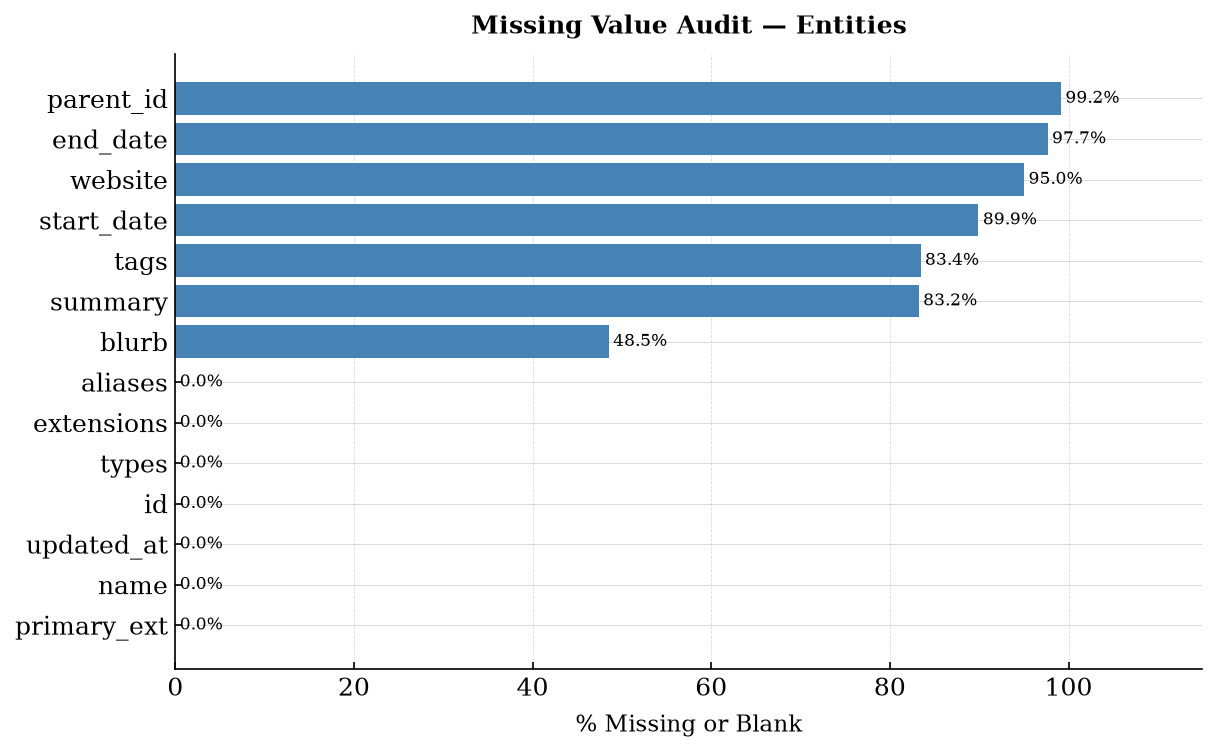

In [4]:
# =============================================================================
# Run audits
# =============================================================================

# entities was preprocessed to entities[id] = attributes dict directly
# so attr_key=None since there is no nested 'attributes' key anymore
df_entities = missing_value_audit(
    entities, 'Entities', attr_key=None
)

# =============================================================================
# Plots
# =============================================================================

plot_missing_audit(
    df_entities,
    title='Missing Value Audit — Entities',
    save_path='missing_entities.pdf'
)

In [5]:
start_only = 0
end_only = 0
both_dates = 0
no_dates = 0

for entity in entities:
    has_start = entities[entity]['start_date'] is not None
    has_end = entities[entity]['end_date'] is not None

    if has_start and (not has_end):
        start_only += 1
    elif (not has_start) and has_end:
        end_only += 1
    elif has_start and has_end:
        both_dates += 1
    else:
        no_dates += 1

print(f"Entities with a start date but no end date: {start_only}")
print(f"Entities with an end date but no start date: {end_only}")
print(f"Entities with both a start date and an end date: {both_dates}")
print(f"Entities with no start date or end date: {no_dates}")

Entities with a start date but no end date: 36086
Entities with an end date but no start date: 2375
Entities with both a start date and an end date: 7841
Entities with no start date or end date: 389140


Now we want to get an idea of how many organizations and how many individuals are in the dataset. Then we will breakup the `entities` dataset into `Organizations` and `Individuals` datasets. We also want to get an idea of the distributions of appropriate initial labels for organizations and individuals.

In [6]:
# Determine unique classes of orgs and individuals, and split dataset into
# Organizations and Individuals datasets.
organization_count = 0
individual_count = 0
Organizations = {}
Org_types = []
Individuals = {}
Ind_types = []
names_to_id = {}
for entity in entities:
    if entities[entity]['primary_ext'] == 'Org':
        organization_count += 1
        Organizations[entity] = entities[entity]
        for x in entities[entity]['types']:
            if x not in Org_types:
                Org_types.append(x)
    else:
        individual_count += 1
        Individuals[entity] = entities[entity]
        for x in entities[entity]['types']:
            if x not in Ind_types:
                Ind_types.append(x)
    names_to_id[entities[entity]['name']] = entity

print("There are",organization_count,'organizations and',individual_count,'individuals comprising the full dataset of',len(entities),'entities.')

Ind_types.remove('Person')
Org_types.remove('Organization')

# Counts the occurrences of org classes which are not simply 'Organization'
counts_org = np.zeros(len(Org_types))
for entity in Organizations:
    for x in Organizations[entity]['types']:
        if x != 'Organization':
            counts_org[np.where(np.array(Org_types) == x)[0][0]] += 1

There are 134441 organizations and 301001 individuals comprising the full dataset of 435442 entities.


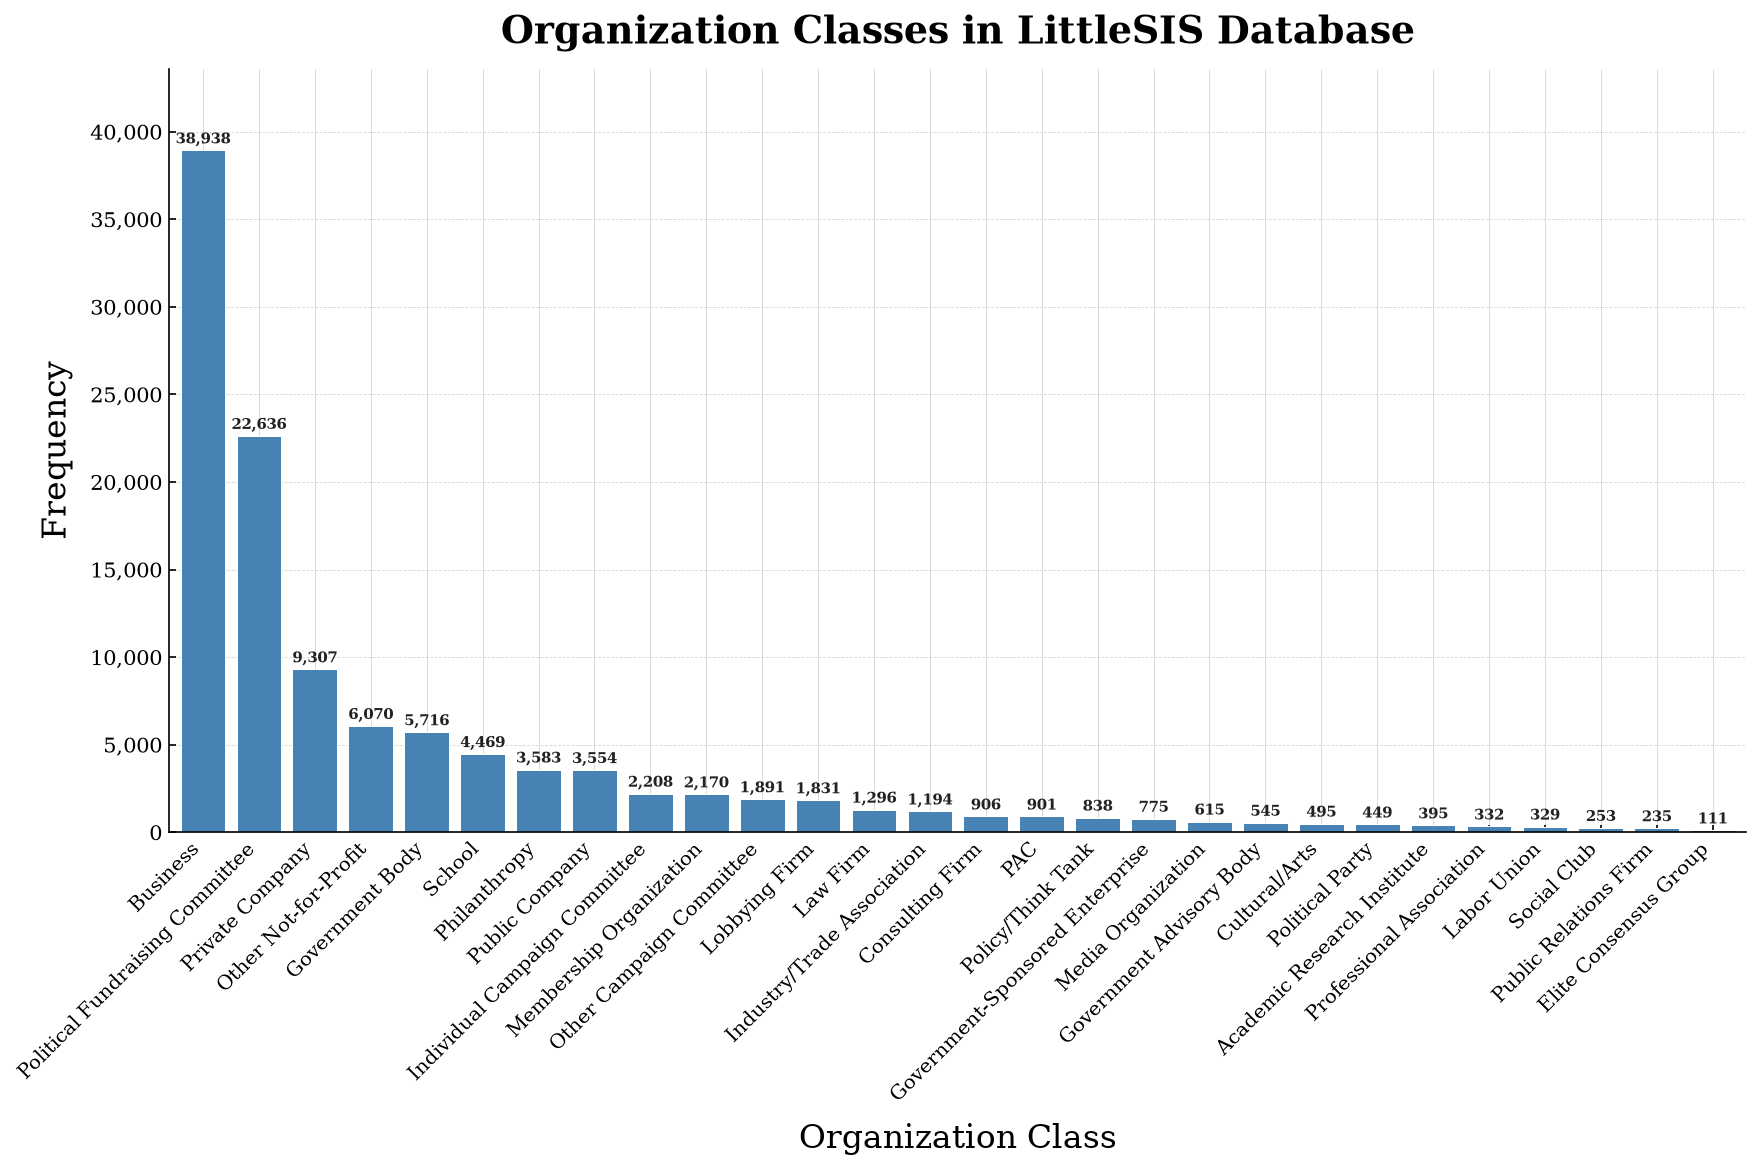

In [7]:
# Sort org types by descending frequency
sort_idx = np.argsort(counts_org)[::-1]
sorted_counts = counts_org[sort_idx][:28]
sorted_labels = [Org_types[i] for i in sort_idx][:28]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.bar(
    range(len(sorted_counts)),
    sorted_counts,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)

# Frequency labels above bars
for bar, count in zip(bars, sorted_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + sorted_counts.max() * 0.005,
        f'{int(count):,}',
        ha='center', va='bottom',
        fontsize=7, fontweight='bold', color='#222222'
    )

ax.set_xticks(range(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9.5)
ax.set_xlabel('Organization Class', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title("Organization Classes in LittleSIS Database", fontsize=18, fontweight='bold', pad=12)
ax.tick_params(axis='y', labelsize=10)

ax.set_xlim(-0.6, len(sorted_counts) - 0.4)
ax.set_ylim(0, sorted_counts.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('org_class_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()

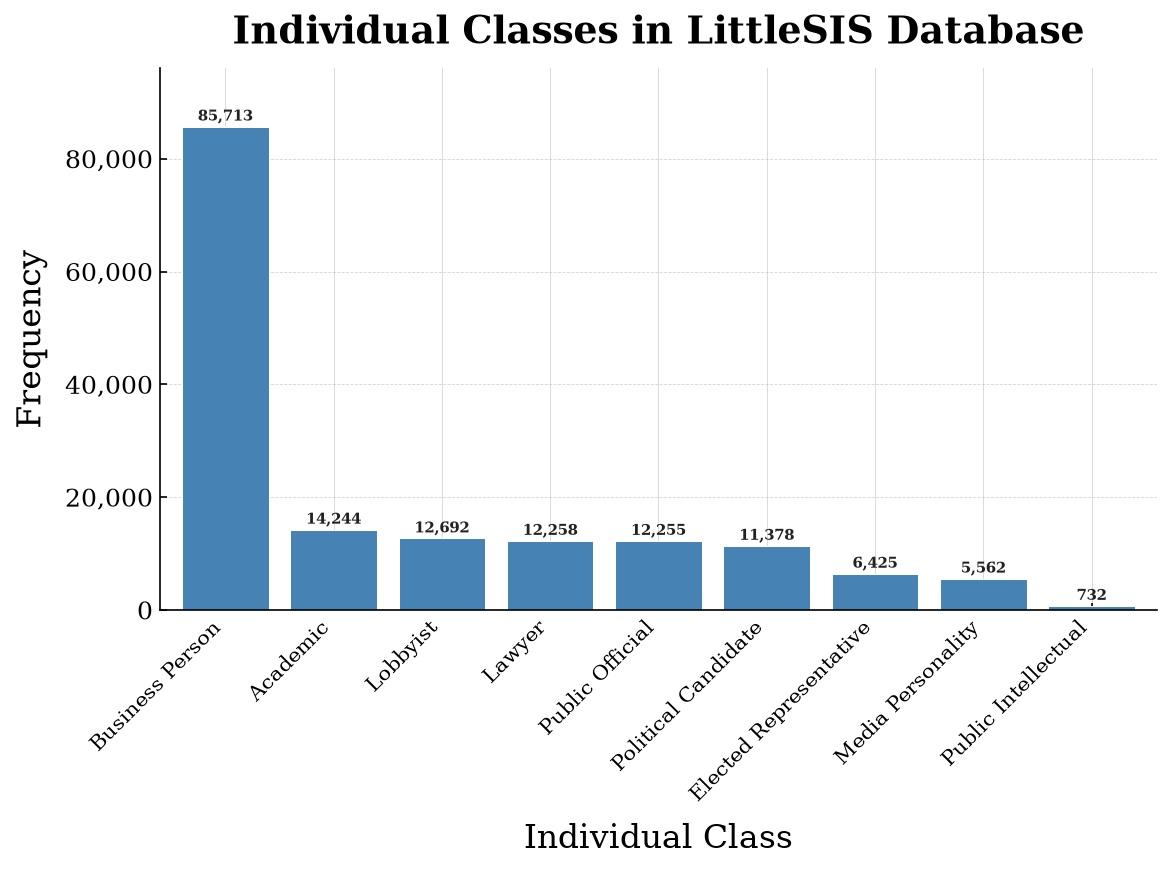

In [8]:
# Counts the occurrences of individuals classes which are not simply 'Person'
counts_ind = np.zeros(len(Ind_types))
for entity in Individuals:
    for x in Individuals[entity]['types']:
        if x != 'Person':
            counts_ind[np.where(np.array(Ind_types) == x)[0][0]] += 1

sort_idx_ind = np.argsort(counts_ind)[::-1]
sorted_counts_ind = counts_ind[sort_idx_ind][:9]
sorted_labels_ind = [Ind_types[i] for i in sort_idx_ind][:9]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    range(len(sorted_counts_ind)),
    sorted_counts_ind,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)

for bar, count in zip(bars, sorted_counts_ind):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + sorted_counts_ind.max() * 0.005,
        f'{int(count):,}',
        ha='center', va='bottom',
        fontsize=7, fontweight='bold', color='#222222'
    )

ax.set_xticks(range(len(sorted_labels_ind)))
ax.set_xticklabels(sorted_labels_ind, rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Individual Class', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title("Individual Classes in LittleSIS Database", fontsize=18, fontweight='bold', pad=12)

ax.set_xlim(-0.6, len(sorted_counts_ind) - 0.4)
ax.set_ylim(0, sorted_counts_ind.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ind_class_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Checking for mislabeled entities

In [9]:
# List of types to filter by
filter_types = ['Political Candidate','Public Intellectual','Public Official','Lawyer','Academic','Business Person','Media Personality','Elected Representative','Lobbyist']

# Filter the Organizations list
filtered_organizations = [
    Organizations[organization] for organization in Organizations
    if any(item in Organizations[organization].get('types', []) for item in filter_types)
]

# Display the number of filtered orgs and the filtered orgs for manual review
print(f"Number of organizations with specified types: {len(filtered_organizations)}")
if filtered_organizations:
    print("Filtered organizations:")
    display(filtered_organizations)
else:
    print("No organizations found with the specified types.")

Number of organizations with specified types: 41
Filtered organizations:


[{'id': 213407,
  'name': 'TMK',
  'blurb': 'TMK is a political group of China',
  'summary': None,
  'website': None,
  'parent_id': None,
  'primary_ext': 'Org',
  'updated_at': '2015-10-23T09:37:21Z',
  'start_date': None,
  'end_date': None,
  'aliases': ['TMK'],
  'types': ['Organization',
   'Political Candidate',
   'Business',
   'Government Body'],
  'extensions': {'Org': {'name': 'TMK',
    'name_nick': None,
    'employees': None,
    'revenue': None,
    'fedspending_id': None,
    'lda_registrant_id': None},
   'PoliticalCandidate': {'is_federal': None,
    'is_state': None,
    'is_local': None,
    'pres_fec_id': None,
    'senate_fec_id': None,
    'house_fec_id': None,
    'crp_id': None},
   'Business': {'annual_profit': None,
    'assets': None,
    'marketcap': None,
    'net_income': None,
    'aum': None},
   'GovernmentBody': {'is_federal': None,
    'state_id': None,
    'city': None,
    'county': None}},
  'tags': []},
 {'id': 222159,
  'name': 'SethRollins',


In [10]:
# List of types to filter by
filter_types = ['Private Company', 'Business', 'Law Firm', 'Government Body', 'Lobbying Firm', 'Policy/Think Tank', 'School', 'Political Party', 'Other Not-for-Profit', 'Media Organization']

# Filter the Individuals list
filtered_individuals = [
    Individuals[individual] for individual in Individuals
    if any(item in Individuals[individual].get('types', []) for item in filter_types)
]

# Display the number of filtered individuals and the entries
print(f"Number of individuals with specified types: {len(filtered_individuals)}")
if filtered_individuals:
    print("Filtered individuals:")
    display(filtered_individuals)
else:
    print("No individuals found with the specified types.")

Number of individuals with specified types: 49
Filtered individuals:


[{'id': 224095,
  'name': 'Lori Whelan',
  'blurb': 'Co-founder of Silversmith Capital Partners; formerly with Bain & Co.',
  'summary': None,
  'website': None,
  'parent_id': None,
  'primary_ext': 'Person',
  'updated_at': '2016-03-23T17:57:13Z',
  'start_date': None,
  'end_date': None,
  'aliases': ['Lori Whelan'],
  'types': ['Person', 'Private Company', 'Business Person'],
  'extensions': {'Person': {'name_last': 'Whelan',
    'name_first': 'Lori',
    'name_middle': None,
    'name_prefix': None,
    'name_suffix': None,
    'name_nick': None,
    'birthplace': None,
    'gender_id': None,
    'party_id': None,
    'is_independent': None,
    'net_worth': None,
    'name_maiden': None,
    'nationality': []},
   'BusinessPerson': {'sec_cik': None}},
  'tags': []},
 {'id': 225870,
  'name': 'Henry McClure',
  'blurb': None,
  'summary': None,
  'website': None,
  'parent_id': None,
  'primary_ext': 'Person',
  'updated_at': '2016-04-28T01:34:48Z',
  'start_date': None,
  'end_da

In [11]:
# Move individuals incorrectly labelled as organizations to individuals
Individuals[227043] = Organizations[227043]
del(Organizations[227043])
Individuals[423772] = Organizations[423772]
del(Organizations[423772])
# Move organizations incorrectly labelled as individuals to organizations
Organizations[258205] = Individuals[258205]
del(Individuals[258205])
Organizations[333433] = Individuals[333433]
del(Individuals[333433])

---
## Dataset 2: Relationships
---
The `relationships` dataset contains 12 classes of relationships:
1) `Position` (P+O and P+P): When a person has a place in an organizational hierarchy, usually carrying a title. Positions can be paid or unpaid. Examples - CEO, Director, Trustee, Chief Counsel, Professor, etc. <br>
2) `Education` (P+O): When a person attends a school or educational program as a student. <br>
3) `Membership`: When a person is a member of a membership organization, but doesn’t hold a position, or when an organization is a member of a larger coalition or association. Examples - AFL-CIO, NRA, National Association of Manufacturers, etc. <br>
4) `Family` (P+P): When two people are part of the same family. Examples - children, spouses, cousins, siblings, etc. <br>
5) `Donation/Grant`: A gift transfer of money, goods, or services with nothing due in return. Examples - political funding, contributions to charities, government grants, prizes. <br>
6) `Service/Transaction`: An exchange of money, goods, or services of about equal value. Examples - purchases, consulting, contract work, accounting, trades, etc. <br>
7) `Lobbying`: When an organization directly lobbies a government agency or official. Examples - organization that employs lobbyists in-house, lobbying firm hired by an organization. <br>
8) `Social` (P+P): When two people are socially acquainted. Examples - friends, rivals, lovers, tennis partners, etc. <br>
9) `Professional` (P+P): When two people have a direct working or business relationship. Examples - co-writers, business partners, mentors, etc. <br>
10) `Ownership` (O+O and P+O): When a person or organization has full or partial ownership of an organization. Examples - sole proprietor, limited partners, shareholders, etc. <br>
11) `Hierarchy` (O+O): When an organization is the parent or child of another organization. Examples - foundation, lobbying arm, political arm, etc. <br>
12) `Generic`: A generic type for affiliations that do not fit into any of the regular types of relationships.

Each relationship entry contains 6 attributes:
- `type`: Denotes whether the entry is an entity (`entities`) or a relationship (`relationships`).
- `id`: Denotes the unique integer identification number of the entity. Entities and relationships can have the same id value.
- `attributes`: Contains another dictionary containing all of the relevant attributes of the entity. This is where most of the relevant information about the entity is contained.
- `self`: URL for littlesis webpage about the relationship.
- `entity`: URL for littlesis webpage about entity_1 in the relationship.
- `related`: URL for littlesis webpage about entity_2 in the relationship.

---
## Preprocessing & Exploratory Analysis
---
Since all entries in the relationships data set are trivially relationships, the `type` attribute is redundant. Since the ID values is also embedded in the `attributes` attribute, the exterior `id` is redundant. Since we have no need for the littlesis url, the `self`, `entity`, and `related` attributes are also redundant. Finally, since `attributes` is the only non-redundant attribute in the exterior dictionaries, we replace the exterior dictionaries with the interior `attributes` dictionary.

In [12]:
for i in range(len(relationships)):
    relationships[i] = relationships[i]['attributes']

person_to_person = {relation['id']: relation for relation in relationships if ( (relation['entity1_id'] in Individuals) and (relation['entity2_id'] in Individuals) )}
person_to_org = {relation['id']: relation for relation in relationships if ((relation['entity1_id'] in Individuals and relation['entity2_id'] in Organizations) or (relation['entity1_id'] in Organizations and relation['entity2_id'] in Individuals))}
org_to_org = {relation['id']: relation for relation in relationships if (relation['entity1_id'] in Organizations and relation['entity2_id'] in Organizations)}

total_classified = len(person_to_person) + len(person_to_org) + len(org_to_org)
print(f"P-P: {len(person_to_person)}, P-O: {len(person_to_org)}, O-O: {len(org_to_org)}")
print(f"Classified: {total_classified} / {len(relationships)} ({100*total_classified/len(relationships):.2f}%)")

P-P: 870257, P-O: 847119, O-O: 124663
Classified: 1842039 / 1842042 (100.00%)



Missing value audit: Relationships (n=1,842,042)
          attribute  n_present  n_missing pct_missing pct_present
              goods      7,974  1,834,068      99.57%       0.43%
         is_current    659,508  1,182,534      64.20%      35.80%
            filings  1,202,965    639,077      34.69%      65.31%
             amount  1,232,537    609,505      33.09%      66.91%
           currency  1,232,537    609,505      33.09%      66.91%
           end_date  1,315,794    526,248      28.57%      71.43%
       description2  1,327,851    514,191      27.91%      72.09%
         start_date  1,390,680    451,362      24.50%      75.50%
       description1  1,695,598    146,444       7.95%      92.05%
category_attributes  1,783,822     58,220       3.16%      96.84%
        is_featured  1,842,042          0       0.00%     100.00%
         entity1_id  1,842,042          0       0.00%     100.00%
         updated_at  1,842,042          0       0.00%     100.00%
        description  1,842

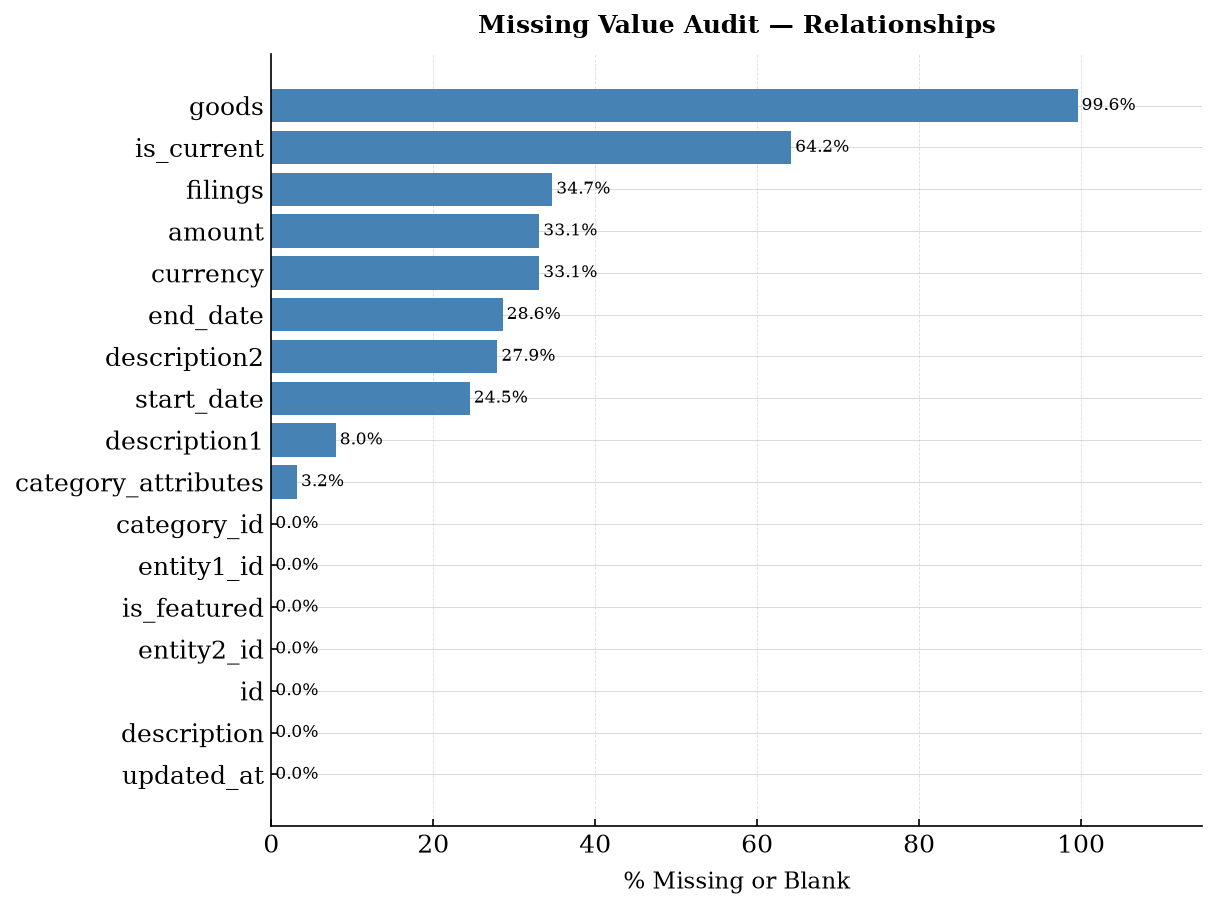

In [13]:
# relationships was likewise preprocessed to relationships[i] = attributes dict
# but relationships is a list after preprocessing, so convert first
relationships_dict = {i: r for i, r in enumerate(relationships)} \
    if isinstance(relationships, list) \
    else relationships

df_relationships = missing_value_audit(
    relationships_dict, 'Relationships', attr_key=None
)

plot_missing_audit(
    df_relationships,
    title='Missing Value Audit — Relationships',
    save_path='missing_relationships.pdf'
)

Now we will split these three dictionaries (P-P, P-O, O-O) into dictionaries where each relationship has 1. only a start date, 2. a start AND end date, 3. only an end date.

In [14]:
start_only = 0
end_only = 0
both_dates = 0
no_dates = 0

has_start_p2p = {}; has_start_end_p2p = {}; has_end_p2p = {}
# Iterate over all person-person relationships to count and
# store relations with a start_date, and start_date + end_date
for relation in person_to_person.copy():
    # Check if relation has valid start_date
    has_start = person_to_person[relation]['start_date'] is not None
    if person_to_person[relation]['start_date'] == '':
      has_start = False

    # If relation has valid start_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_start:
      date = person_to_person[relation]['start_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        person_to_person[relation]['start_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        person_to_person[relation]['start_date'] = date

    # Check if relation has valid end_date
    has_end = person_to_person[relation]['end_date'] is not None
    if person_to_person[relation]['end_date'] == '':
      has_end = False

    # If relation has valid end_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_end:
      date = person_to_person[relation]['end_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        person_to_person[relation]['end_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        person_to_person[relation]['end_date'] = date

    # Relation ONLY has start_date
    if has_start and not has_end:
        start_year = int(person_to_person[relation]['start_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025:
          if person_to_person[relation]['is_current']:
            has_start_end_p2p[relation] = person_to_person[relation]
            both_dates += 1
          else:
            has_start_p2p[relation] = person_to_person[relation]
            start_only += 1
    # Relation ONLY has end_date
    elif not has_start and has_end:
        end_year = int(person_to_person[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if end_year >= 1950 and end_year <= 2025:
          has_end_p2p[relation] = person_to_person[relation]
          end_only += 1
    # Relation has BOTH start_date and end_date
    elif has_start and has_end:
        start_year = int(person_to_person[relation]['start_date'][:4])
        end_year = int(person_to_person[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025 and end_year <= 2025 and start_year <= end_year:
          if person_to_person[relation]['start_date'] == person_to_person[relation]['end_date']:
            person_to_person[relation]['end_date'] = None
            has_start_p2p[relation] = person_to_person[relation]
            start_only += 1
            continue
          #has_start_p2o[relation] = person_to_org[relation]
          has_start_end_p2p[relation] = person_to_person[relation]
          both_dates += 1
    else:
        no_dates += 1

print(f"P-P relationships with a start date but no end date: {start_only}")
print(f"P-P relationships with an end date but no start date: {end_only}")
print(f"P-P relationships with both a start date and an end date: {both_dates}")
print(f"P-P relationships with no start or end date: {no_dates}")

P-P relationships with a start date but no end date: 558876
P-P relationships with an end date but no start date: 1307
P-P relationships with both a start date and an end date: 265973
P-P relationships with no start or end date: 38977


In [15]:
start_only = 0
end_only = 0
both_dates = 0
no_dates = 0

has_start_p2o = {}; has_start_end_p2o = {}; has_end_p2o = {}
# Iterate over all person-org relationships to count and
# store relations with a start_date, and start_date + end_date
for relation in person_to_org.copy():
    # Check if relation has valid start_date
    has_start = person_to_org[relation]['start_date'] is not None
    if person_to_org[relation]['start_date'] == '':
      has_start = False

    # If relation has valid start_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_start:
      date = person_to_org[relation]['start_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        person_to_org[relation]['start_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        person_to_org[relation]['start_date'] = date

    # Check if relation has valid end_date
    has_end = person_to_org[relation]['end_date'] is not None
    if person_to_org[relation]['end_date'] == '':
      has_end = False

    # If relation has valid end_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_end:
      date = person_to_org[relation]['end_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        person_to_org[relation]['end_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        person_to_org[relation]['end_date'] = date

    # Relation ONLY has start_date
    if has_start and not has_end:
        start_year = int(person_to_org[relation]['start_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025:
          if person_to_org[relation]['is_current']:
            has_start_end_p2o[relation] = person_to_org[relation]
            both_dates += 1
          else:
            has_start_p2o[relation] = person_to_org[relation]
            start_only += 1
    # Relation ONLY has end_date
    elif not has_start and has_end:
        end_year = int(person_to_org[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if end_year >= 1950 and end_year <= 2025:
          has_end_p2o[relation] = person_to_org[relation]
          end_only += 1
    # Relation has BOTH start_date and end_date
    elif has_start and has_end:
        start_year = int(person_to_org[relation]['start_date'][:4])
        end_year = int(person_to_org[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025 and end_year <= 2025 and start_year <= end_year:
          if person_to_org[relation]['start_date'] == person_to_org[relation]['end_date']:
            person_to_org[relation]['end_date'] = None
            has_start_p2o[relation] = person_to_org[relation]
            start_only += 1
            continue
          #has_start_p2o[relation] = person_to_org[relation]
          has_start_end_p2o[relation] = person_to_org[relation]
          both_dates += 1
    else:
        no_dates += 1

print(f"P-O relationships with a start date but no end date: {start_only}")
print(f"P-O relationships with an end date but no start date: {end_only}")
print(f"P-O relationships with both a start date and an end date: {both_dates}")
print(f"P-O relationships with no start or end date: {no_dates}")

P-O relationships with a start date but no end date: 287410
P-O relationships with an end date but no start date: 38659
P-O relationships with both a start date and an end date: 221825
P-O relationships with no start or end date: 294244


In [16]:
start_only = 0
end_only = 0
both_dates = 0
no_dates = 0

has_start_o2o = {}; has_start_end_o2o = {}; has_end_o2o = {}
# Iterate over all org-org relationships to count and
# store relations with a start_date, and start_date + end_date
for relation in org_to_org.copy():
    # Check if relation has valid start_date
    has_start = org_to_org[relation]['start_date'] is not None
    if org_to_org[relation]['start_date'] == '':
      has_start = False

    # If relation has valid start_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_start:
      date = org_to_org[relation]['start_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        org_to_org[relation]['start_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        org_to_org[relation]['start_date'] = date

    # Check if relation has valid end_date
    has_end = org_to_org[relation]['end_date'] is not None
    if org_to_org[relation]['end_date'] == '':
      has_end = False

    # If relation has valid end_date, check if the month
    # or date entry is set to 00, which date_time cannot handle.
    # If 00, set to 01.
    if has_end:
      date = org_to_org[relation]['end_date']
      if date[5:7] == '00':
        date = date[:6]+str(1)+date[7:]
        org_to_org[relation]['end_date'] = date
      if date[8:10] == '00':
        date = date[:9] + str(1)
        org_to_org[relation]['end_date'] = date

    # Relation ONLY has start_date
    if has_start and not has_end:
        start_year = int(org_to_org[relation]['start_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025:
          if org_to_org[relation]['is_current']:
            has_start_end_o2o[relation] = org_to_org[relation]
            both_dates += 1
          else:
            has_start_o2o[relation] = org_to_org[relation]
            start_only += 1
    # Relation ONLY has end_date
    elif not has_start and has_end:
        end_year = int(org_to_org[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if end_year >= 1950 and end_year <= 2025:
          has_end_o2o[relation] = org_to_org[relation]
          end_only += 1
    # Relation has BOTH start_date and end_date
    elif has_start and has_end:
        start_year = int(org_to_org[relation]['start_date'][:4])
        end_year = int(org_to_org[relation]['end_date'][:4])
        # Exclude entries which are too old or clearly invalid
        if start_year >= 1950 and start_year <= 2025 and end_year <= 2025 and start_year <= end_year:
          if org_to_org[relation]['start_date'] == org_to_org[relation]['end_date']:
            org_to_org[relation]['end_date'] = None
            has_start_o2o[relation] = org_to_org[relation]
            start_only += 1
            continue
          has_start_end_o2o[relation] = org_to_org[relation]
          both_dates += 1
    else:
        no_dates += 1

print(f"O-O relationships with a start date but no end date: {start_only}")
print(f"O-O relationships with an end date but no start date: {end_only}")
print(f"O-O relationships with both a start date and an end date: {both_dates}")
print(f"O-O relationships with no start or end date: {no_dates}")

O-O relationships with a start date but no end date: 24361
O-O relationships with an end date but no start date: 1272
O-O relationships with both a start date and an end date: 23004
O-O relationships with no start or end date: 75507


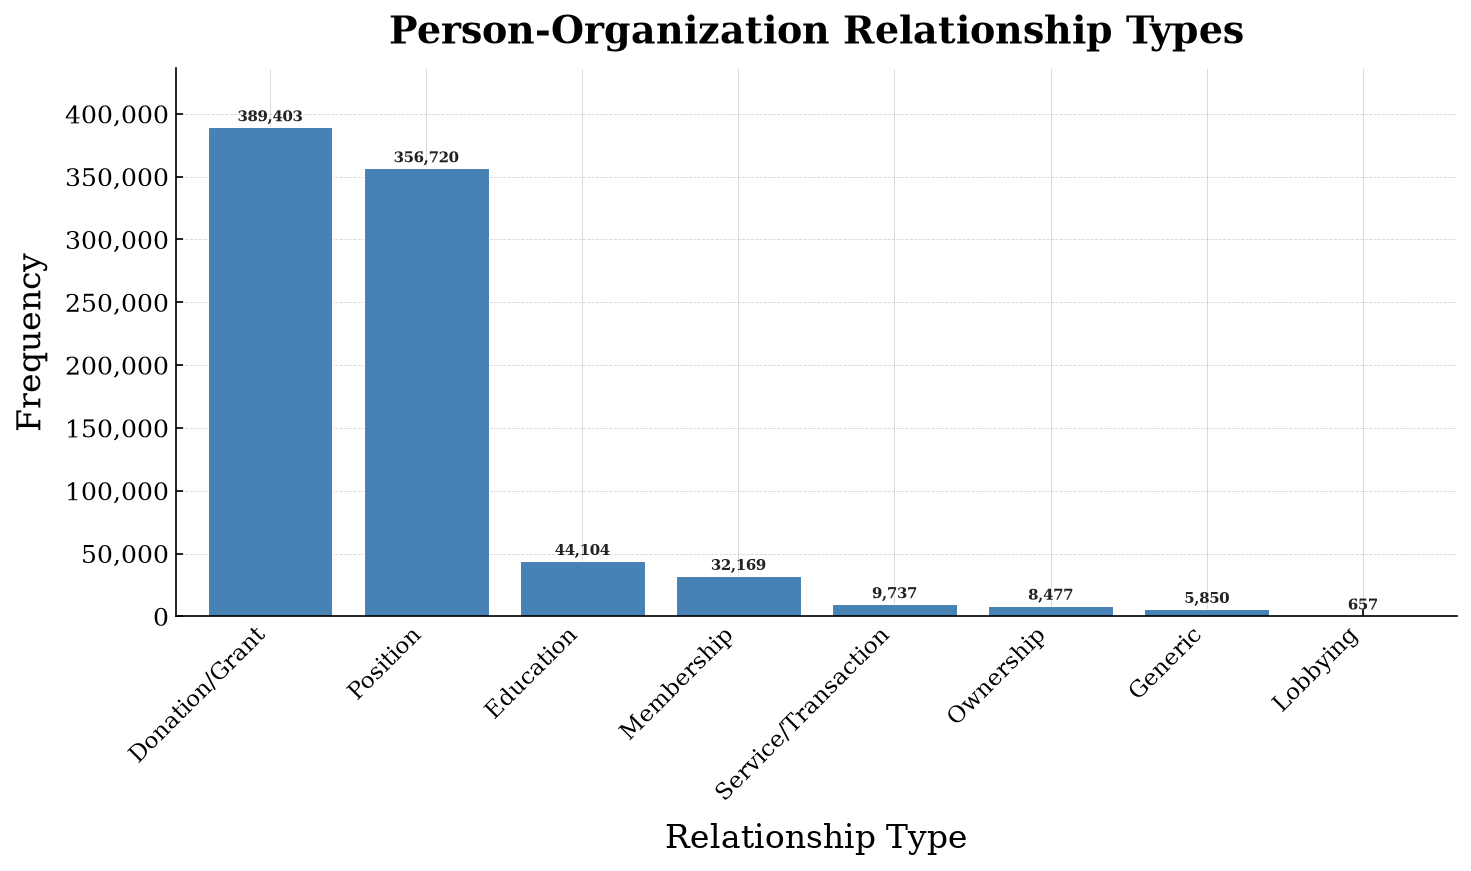

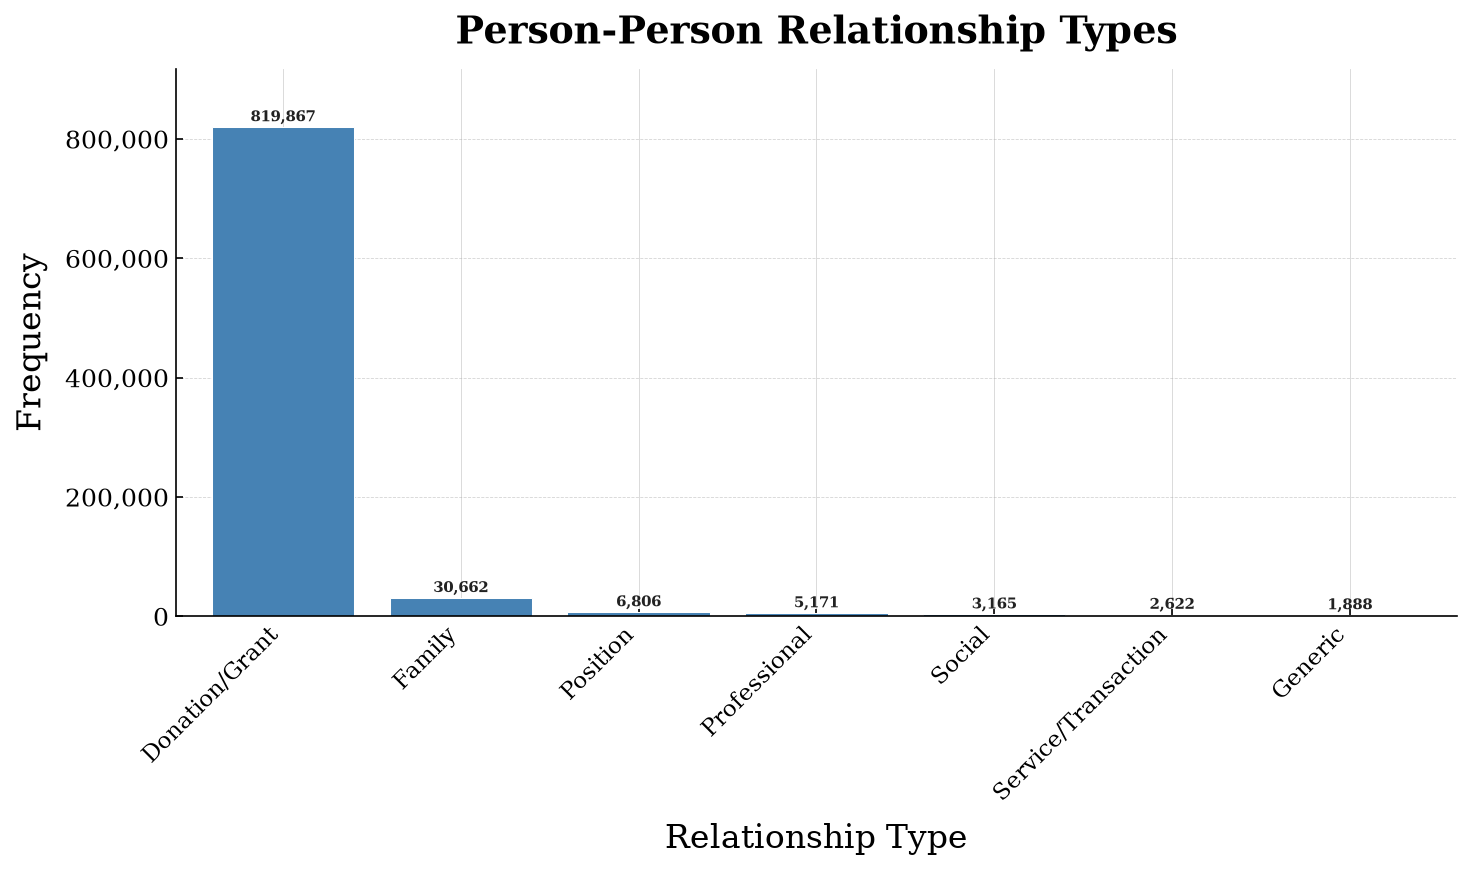

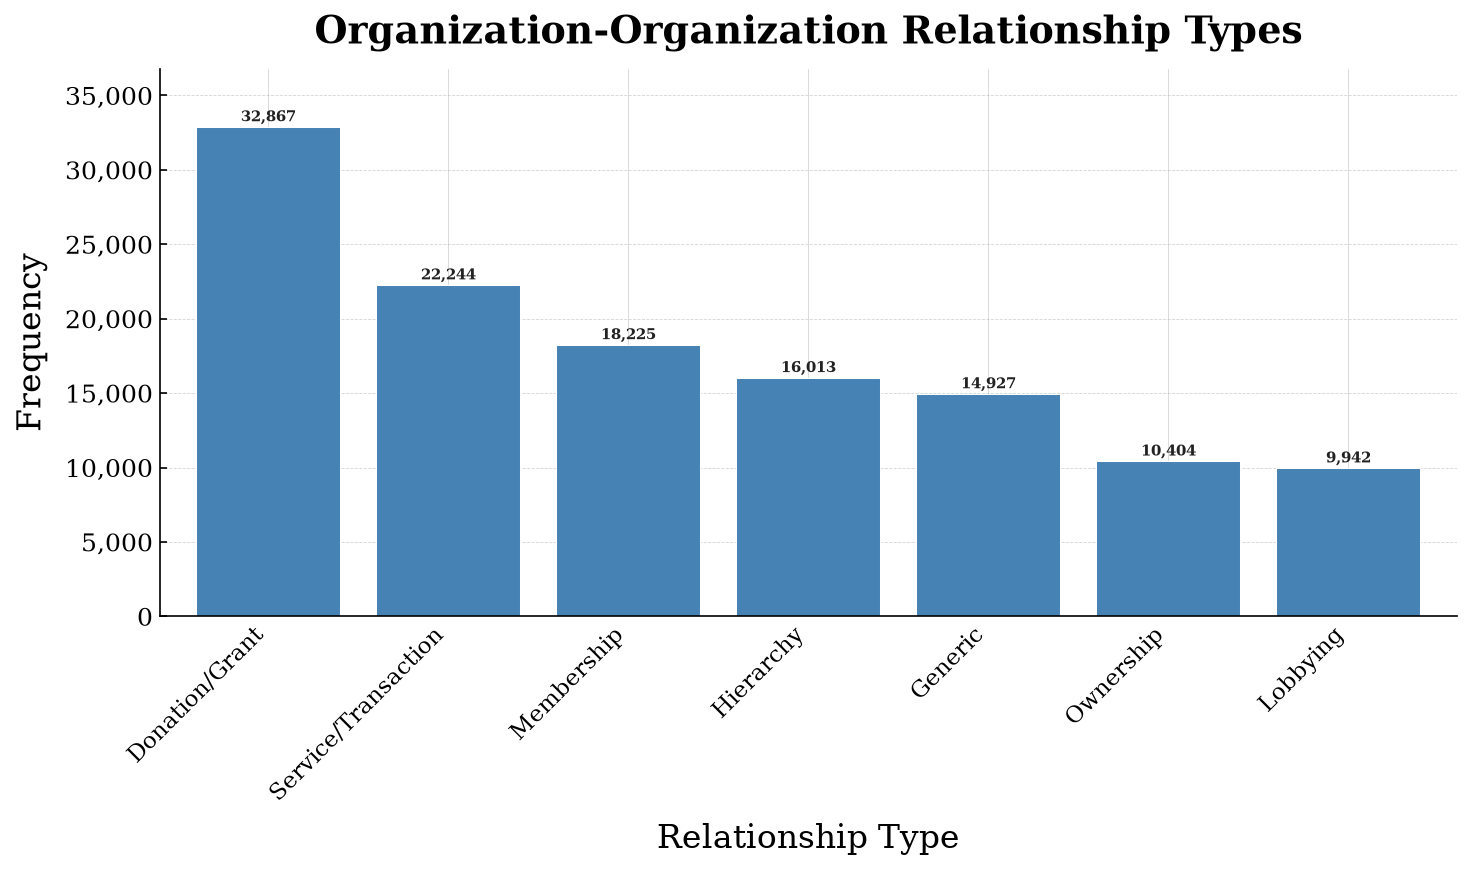

In [17]:
# --- P-O Relationship Type Frequency ---
Rel_types_all = ['Position','Education','Membership','Family','Donation/Grant',
                 'Service/Transaction','Lobbying','Social','Professional',
                 'Ownership','Hierarchy','Generic']

counts_rel_p2o = np.zeros(12)
for relation in person_to_org:
    counts_rel_p2o[person_to_org[relation]['category_id']-1] += 1

# Exclude Family(3), Social(7), Professional(8), Hierarchy(10) — invalid for P-O
keep_idx_p2o = [i for i in range(12) if i not in [3,7,8,10]]
counts_rel_p2o_filtered = counts_rel_p2o[keep_idx_p2o]
labels_p2o = [Rel_types_all[i] for i in keep_idx_p2o]

sort_idx_p2o = np.argsort(counts_rel_p2o_filtered)[::-1]
sorted_counts_p2o = counts_rel_p2o_filtered[sort_idx_p2o]
sorted_labels_p2o = [labels_p2o[i] for i in sort_idx_p2o]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(sorted_counts_p2o)), sorted_counts_p2o,
              color='steelblue', edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, sorted_counts_p2o):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + sorted_counts_p2o.max()*0.005,
            f'{int(count):,}', ha='center', va='bottom',
            fontsize=7, fontweight='bold', color='#222222')
ax.set_xticks(range(len(sorted_labels_p2o)))
ax.set_xticklabels(sorted_labels_p2o, rotation=45, ha='right', fontsize=11)
ax.set_xlabel('Relationship Type', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Person-Organization Relationship Types',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(-0.6, len(sorted_counts_p2o) - 0.4)
ax.set_ylim(0, sorted_counts_p2o.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('p2o_rel_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()


# --- P-P Relationship Type Frequency ---
counts_rel_p2p = np.zeros(12)
for relation in person_to_person:
    counts_rel_p2p[person_to_person[relation]['category_id']-1] += 1

sort_idx_p2p = np.argsort(counts_rel_p2p)[::-1]
sorted_counts_p2p = counts_rel_p2p[sort_idx_p2p][:7]
sorted_labels_p2p = [Rel_types_all[i] for i in sort_idx_p2p][:7]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(sorted_counts_p2p)), sorted_counts_p2p,
              color='steelblue', edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, sorted_counts_p2p):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + sorted_counts_p2p.max()*0.005,
            f'{int(count):,}', ha='center', va='bottom',
            fontsize=7, fontweight='bold', color='#222222')
ax.set_xticks(range(len(sorted_labels_p2p)))
ax.set_xticklabels(sorted_labels_p2p, rotation=45, ha='right', fontsize=11)
ax.set_xlabel('Relationship Type', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Person-Person Relationship Types',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(-0.6, len(sorted_counts_p2p) - 0.4)
ax.set_ylim(0, sorted_counts_p2p.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('p2p_rel_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()


# --- O-O Relationship Type Frequency ---
counts_rel_o2o = np.zeros(12)
for relation in org_to_org:
    counts_rel_o2o[org_to_org[relation]['category_id']-1] += 1

sort_idx_o2o = np.argsort(counts_rel_o2o)[::-1]
sorted_counts_o2o = counts_rel_o2o[sort_idx_o2o][:7]
sorted_labels_o2o = [Rel_types_all[i] for i in sort_idx_o2o][:7]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(sorted_counts_o2o)), sorted_counts_o2o,
              color='steelblue', edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, sorted_counts_o2o):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + sorted_counts_o2o.max()*0.005,
            f'{int(count):,}', ha='center', va='bottom',
            fontsize=7, fontweight='bold', color='#222222')
ax.set_xticks(range(len(sorted_labels_o2o)))
ax.set_xticklabels(sorted_labels_o2o, rotation=45, ha='right', fontsize=11)
ax.set_xlabel('Relationship Type', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Organization-Organization Relationship Types',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(-0.6, len(sorted_counts_o2o) - 0.4)
ax.set_ylim(0, sorted_counts_o2o.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('o2o_rel_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()

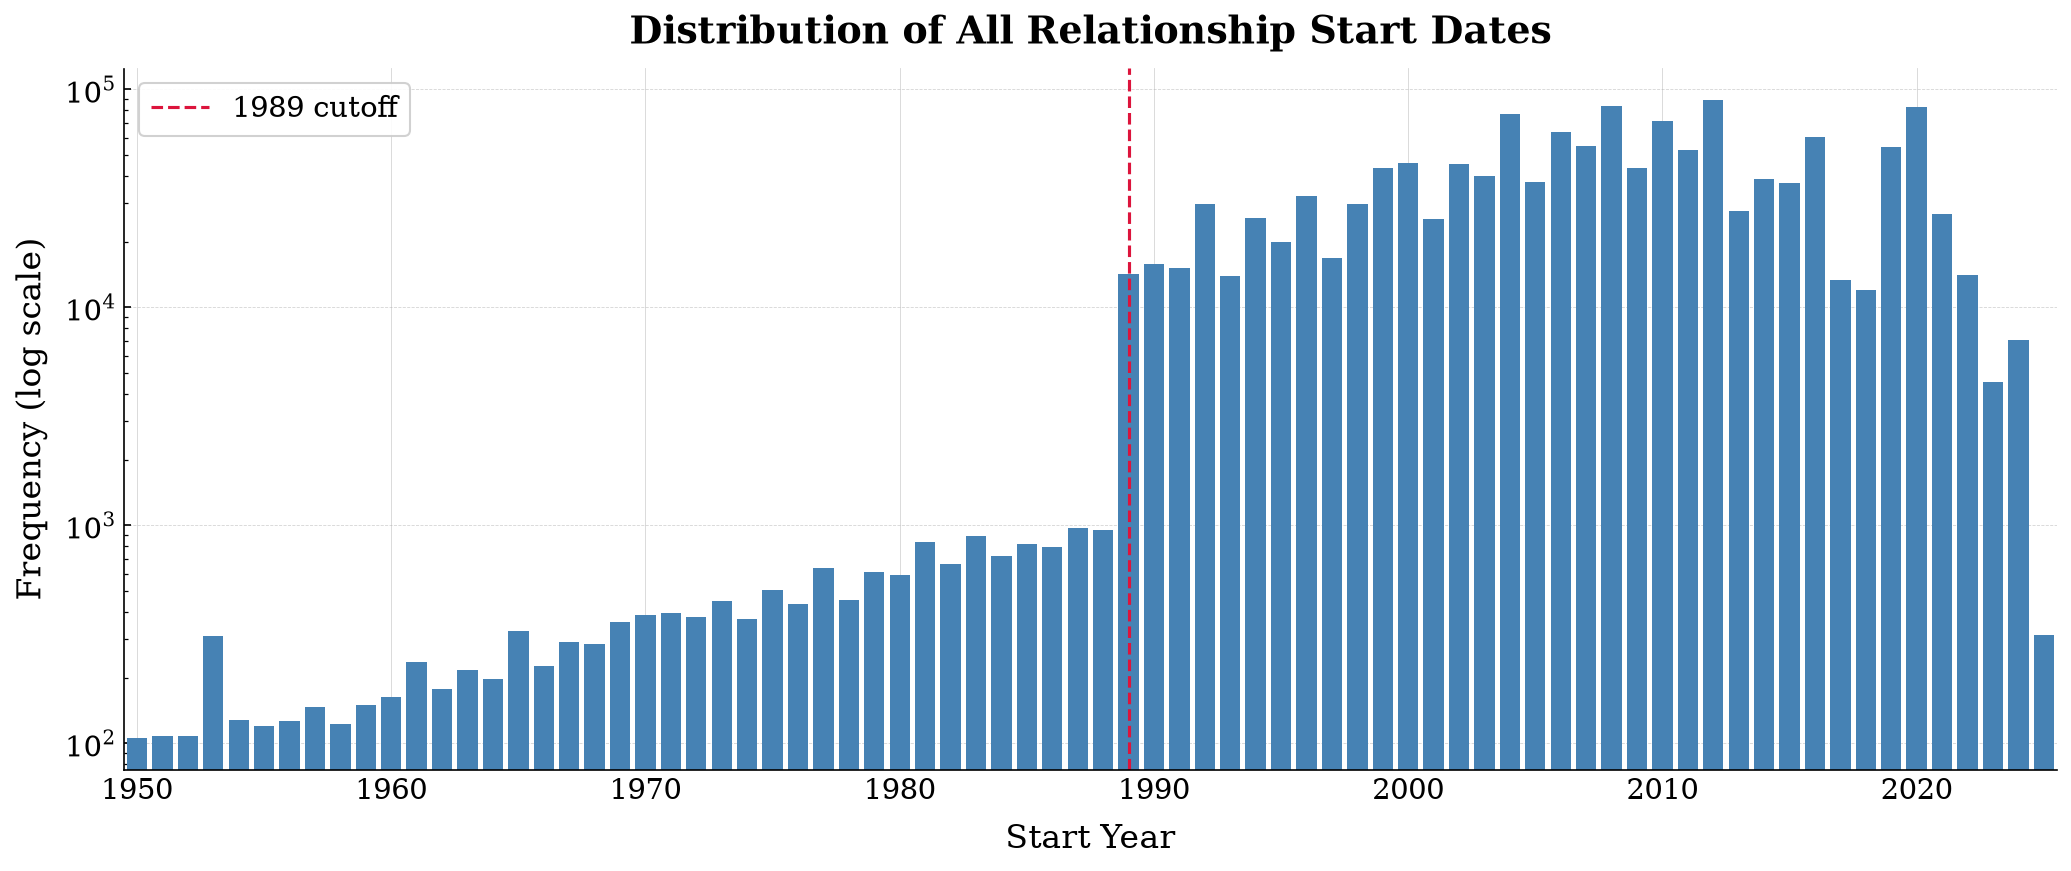

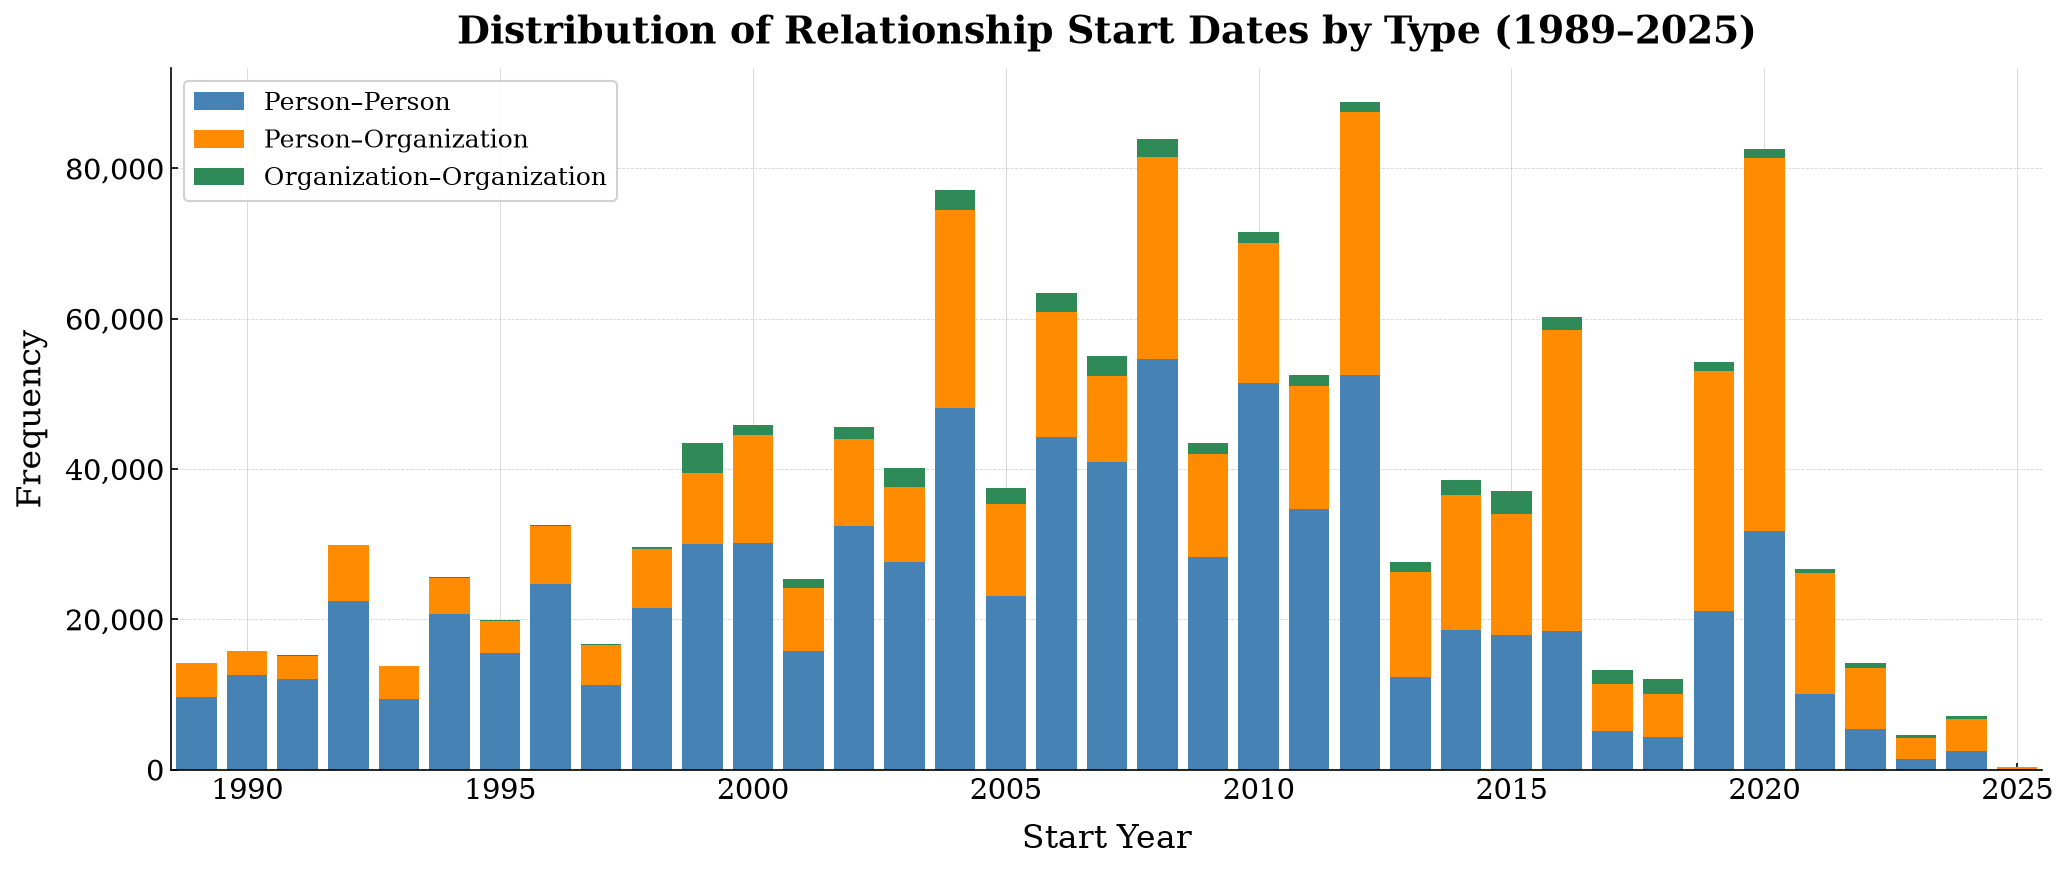

In [18]:
# --- Combined histogram (all types merged) to motivate the 1989 cutoff ---
# Count per year for each type
years_all = (extract_start_years(has_start_p2p) + extract_start_years(has_start_end_p2p) +
             extract_start_years(has_start_p2o) + extract_start_years(has_start_end_p2o) +
             extract_start_years(has_start_o2o) + extract_start_years(has_start_end_o2o))

year_min, year_max = min(years_all), max(years_all)
bins = range(year_min, year_max + 2)
bin_years = np.array(list(bins[:-1]))
counts_all = year_counts(years_all, bins)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bin_years, counts_all, width=0.8, color='steelblue', edgecolor='none')
ax.axvline(x=1989, color='crimson', linestyle='--', linewidth=1.5, label='1989 cutoff')
ax.set_yscale('log')
ax.set_xlabel('Start Year', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency (log scale)', fontsize=16, labelpad=8)
ax.set_title('Distribution of All Relationship Start Dates',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(year_min - 0.5, year_max + 0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=14, framealpha=0.9, edgecolor='#cccccc')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.savefig('start_date_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()


# --- Remove entries with start dates prior to 1989 ---
for z in [has_start_p2p, has_start_end_p2p,
          has_start_p2o, has_start_end_p2o,
          has_start_o2o, has_start_end_o2o]:
    to_delete = [r for r in z if int(z[r]['start_date'][:4]) < 1989]
    for r in to_delete:
        del z[r]


# --- Stacked bar histogram (1989 onward, linear scale) ---
years_p2p = extract_start_years(has_start_p2p) + extract_start_years(has_start_end_p2p)
years_p2o = extract_start_years(has_start_p2o) + extract_start_years(has_start_end_p2o)
years_o2o = extract_start_years(has_start_o2o) + extract_start_years(has_start_end_o2o)

all_years = years_p2p + years_p2o + years_o2o
year_min, year_max = min(all_years), max(all_years)
bins = range(year_min, year_max + 2)
bin_years = np.array(list(bins[:-1]))

counts_p2p = year_counts(years_p2p, bins)
counts_p2o = year_counts(years_p2o, bins)
counts_o2o = year_counts(years_o2o, bins)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bin_years, counts_p2p, width=0.8,
       label='Person–Person', color='steelblue', edgecolor='none')
ax.bar(bin_years, counts_p2o, width=0.8,
       bottom=counts_p2p,
       label='Person–Organization', color='darkorange', edgecolor='none')
ax.bar(bin_years, counts_o2o, width=0.8,
       bottom=counts_p2p + counts_p2o,
       label='Organization–Organization', color='seagreen', edgecolor='none')

ax.set_xlabel('Start Year', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Distribution of Relationship Start Dates by Type (1989–2025)',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(year_min - 0.5, year_max + 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=12, framealpha=0.9, edgecolor='#cccccc')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.savefig('start_date_stacked_1989.pdf', dpi=300, bbox_inches='tight')
plt.show()

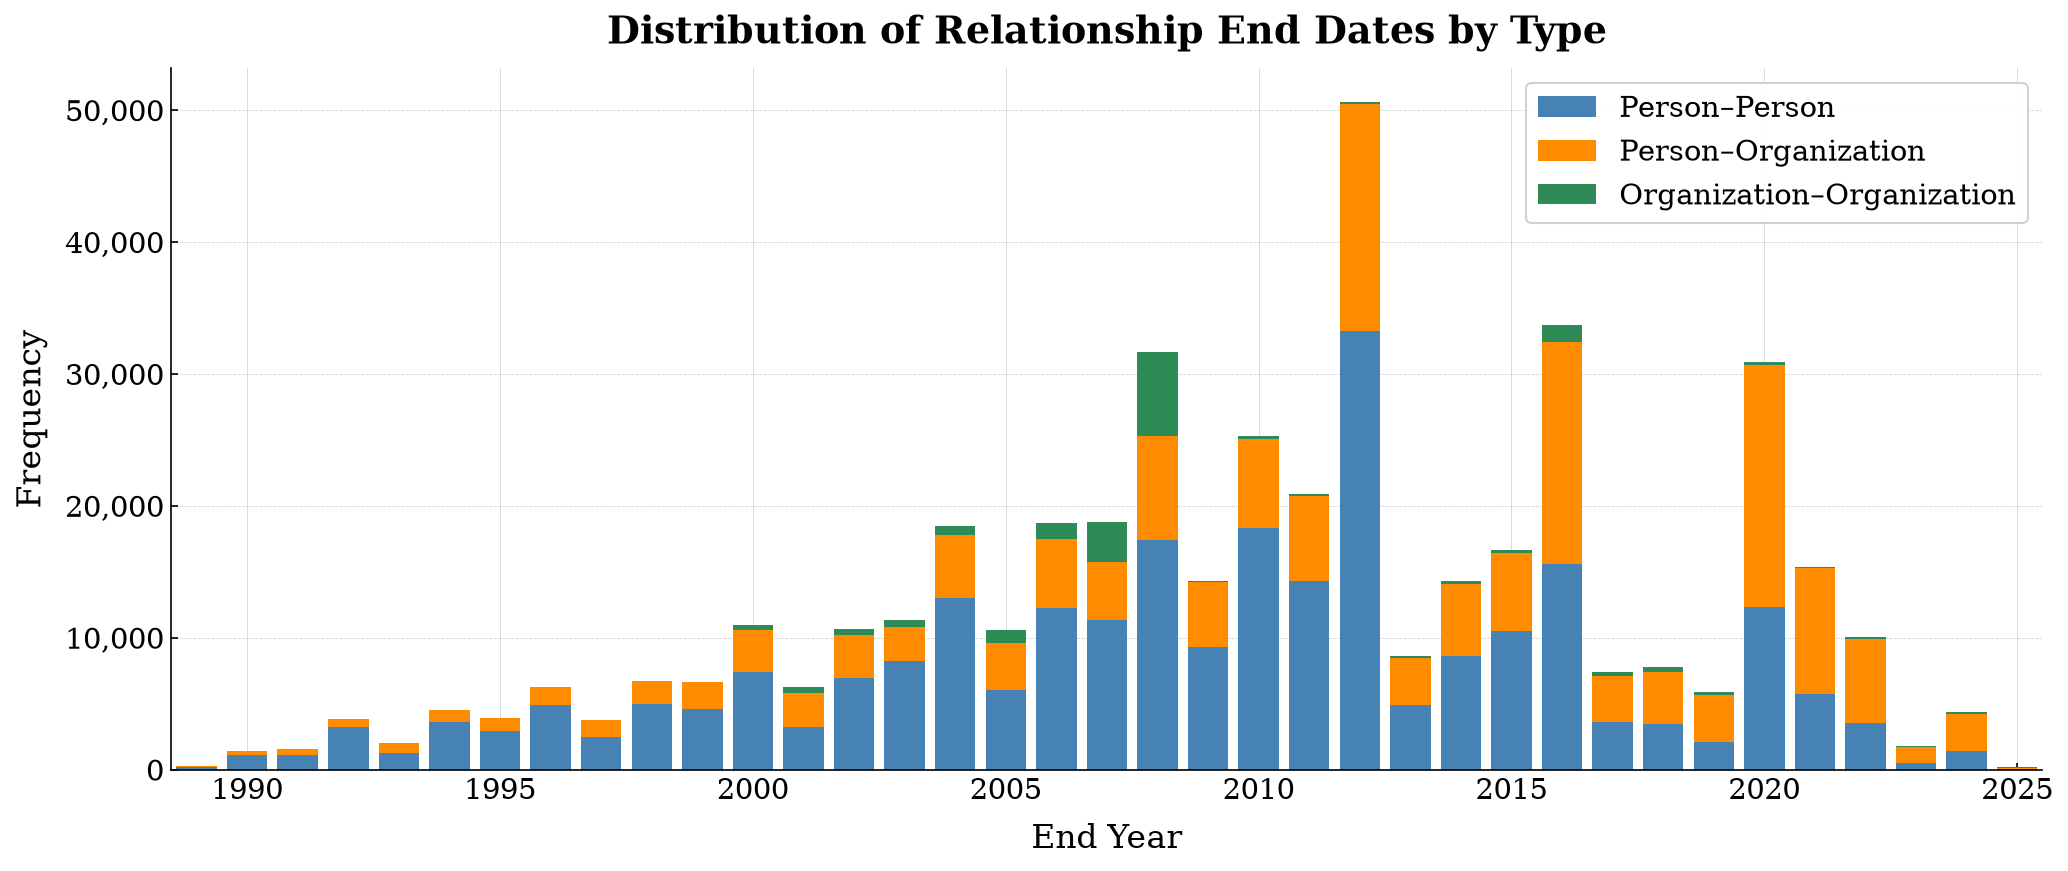

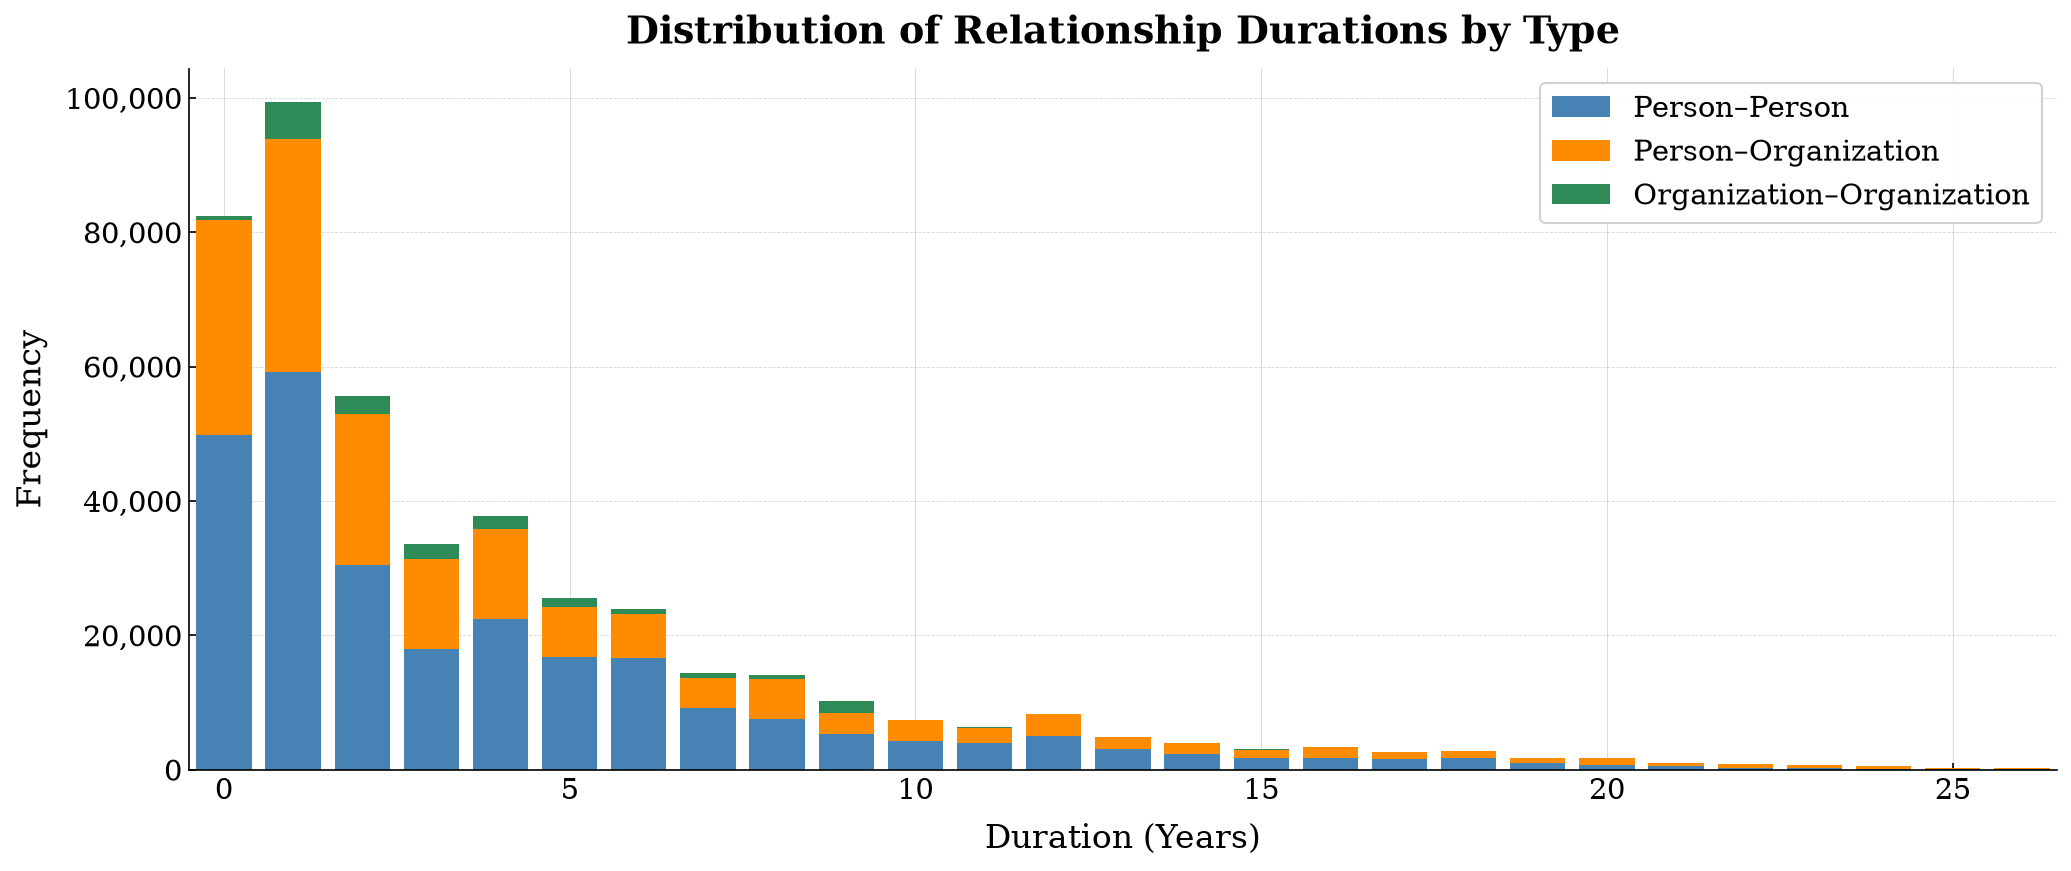

In [19]:
# =============================================================================
# 1. End Date Distribution (Stacked Histogram)
# =============================================================================
years_end_p2p = extract_end_years(has_start_end_p2p)
years_end_p2o = extract_end_years(has_start_end_p2o)
years_end_o2o = extract_end_years(has_start_end_o2o)

all_end_years = years_end_p2p + years_end_p2o + years_end_o2o
year_min_e, year_max_e = min(all_end_years), max(all_end_years)
bins_e = range(year_min_e, year_max_e + 2)
bin_years_e = np.array(list(bins_e[:-1]))

counts_end_p2p = year_counts(years_end_p2p, bins_e)
counts_end_p2o = year_counts(years_end_p2o, bins_e)
counts_end_o2o = year_counts(years_end_o2o, bins_e)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bin_years_e, counts_end_p2p, width=0.8,
       label='Person–Person', color='steelblue', edgecolor='none')
ax.bar(bin_years_e, counts_end_p2o, width=0.8,
       bottom=counts_end_p2p,
       label='Person–Organization', color='darkorange', edgecolor='none')
ax.bar(bin_years_e, counts_end_o2o, width=0.8,
       bottom=counts_end_p2p + counts_end_p2o,
       label='Organization–Organization', color='seagreen', edgecolor='none')
ax.set_xlabel('End Year', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Distribution of Relationship End Dates by Type',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(year_min_e - 0.5, year_max_e + 0.5)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=14, framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('end_date_stacked.pdf', dpi=300, bbox_inches='tight')
plt.show()


# =============================================================================
# 2. Relationship Duration Distribution
# =============================================================================
dur_p2p = extract_durations(has_start_end_p2p)
dur_p2o = extract_durations(has_start_end_p2o)
dur_o2o = extract_durations(has_start_end_o2o)

max_dur = max(dur_p2p + dur_p2o + dur_o2o)
bins_d = range(0, max_dur + 2)
bin_durs = np.array(list(bins_d[:-1]))[:27]

counts_dur_p2p = year_counts(dur_p2p, bins_d)[:27]
counts_dur_p2o = year_counts(dur_p2o, bins_d)[:27]
counts_dur_o2o = year_counts(dur_o2o, bins_d)[:27]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bin_durs, counts_dur_p2p, width=0.8,
       label='Person–Person', color='steelblue', edgecolor='none')
ax.bar(bin_durs, counts_dur_p2o, width=0.8,
       bottom=counts_dur_p2p,
       label='Person–Organization', color='darkorange', edgecolor='none')
ax.bar(bin_durs, counts_dur_o2o, width=0.8,
       bottom=counts_dur_p2p + counts_dur_p2o,
       label='Organization–Organization', color='seagreen', edgecolor='none')
ax.set_xlabel('Duration (Years)', fontsize=16, labelpad=8)
ax.set_ylabel('Frequency', fontsize=16, labelpad=8)
ax.set_title('Distribution of Relationship Durations by Type',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlim(-0.5, 26 + 0.5)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=14, framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('duration_stacked.pdf', dpi=300, bbox_inches='tight')
plt.show()

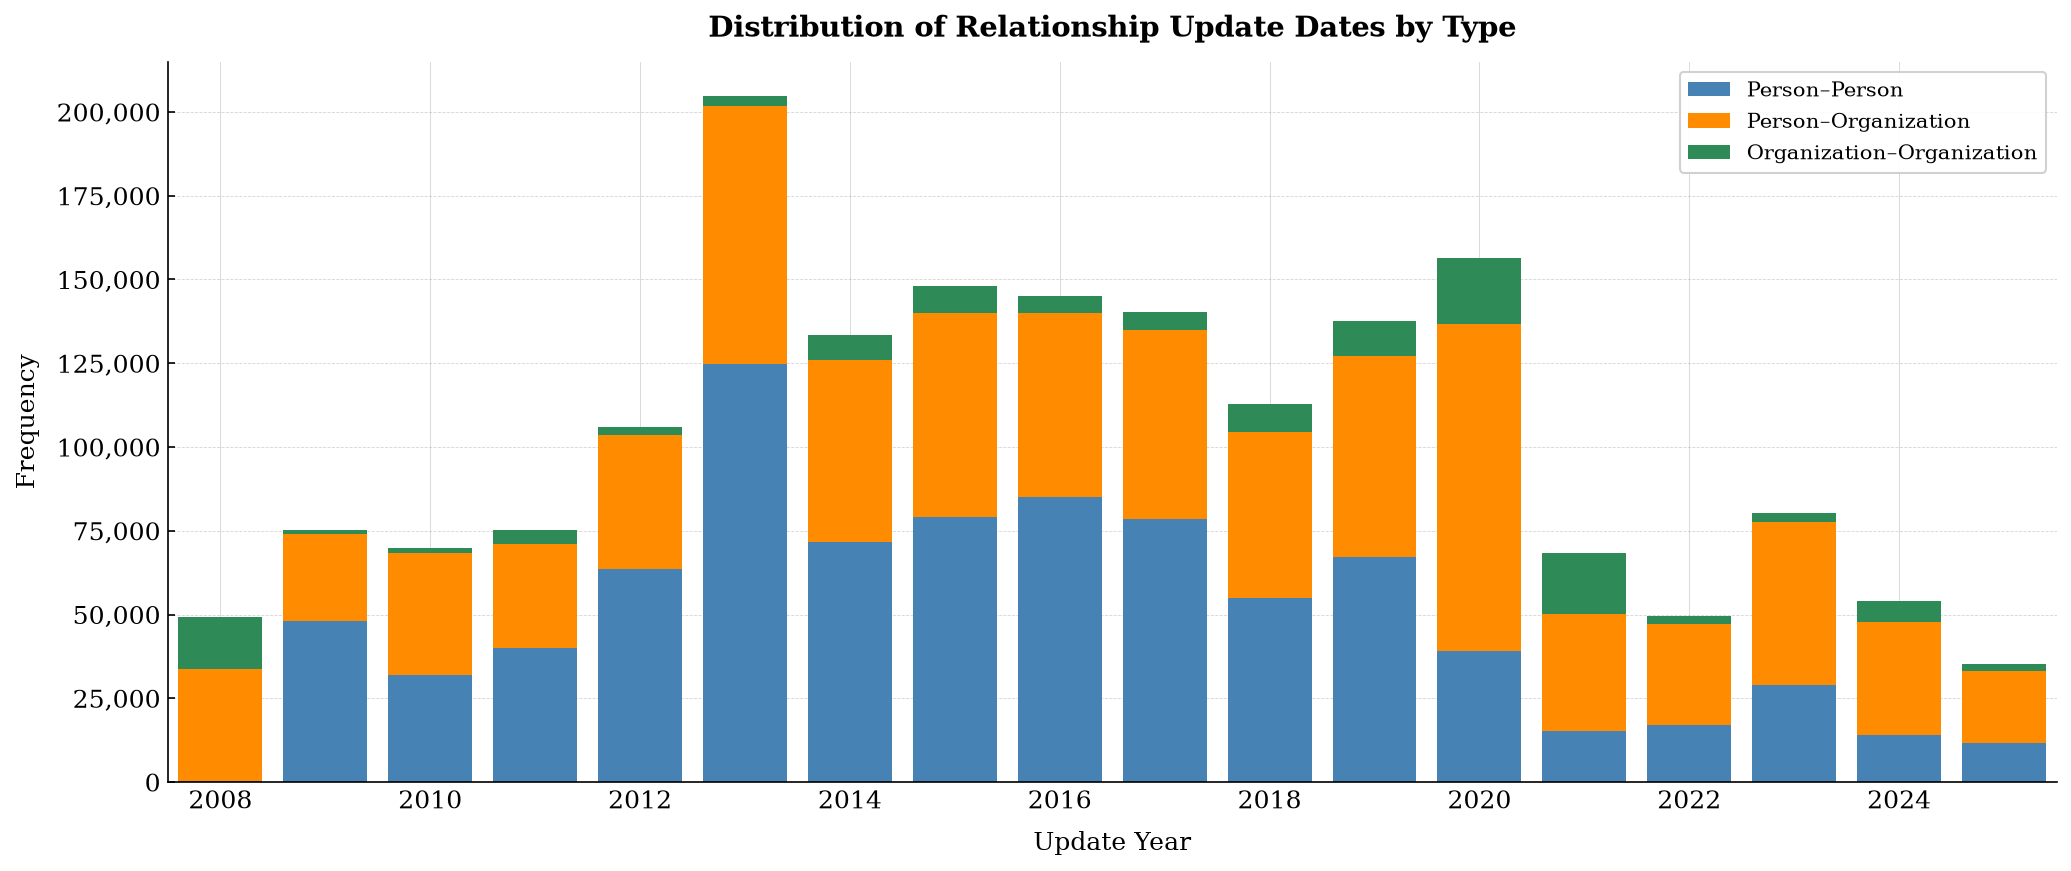

In [20]:
years_upd_p2p = extract_update_years(person_to_person)
years_upd_p2o = extract_update_years(person_to_org)
years_upd_o2o = extract_update_years(org_to_org)

all_upd_years = years_upd_p2p + years_upd_p2o + years_upd_o2o
year_min, year_max = min(all_upd_years), max(all_upd_years)
bins = range(year_min, year_max + 2)
bin_years = np.array(list(bins[:-1]))

counts_upd_p2p = year_counts(years_upd_p2p, bins)
counts_upd_p2o = year_counts(years_upd_p2o, bins)
counts_upd_o2o = year_counts(years_upd_o2o, bins)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bin_years, counts_upd_p2p, width=0.8,
       label='Person–Person', color='steelblue', edgecolor='none')
ax.bar(bin_years, counts_upd_p2o, width=0.8,
       bottom=counts_upd_p2p,
       label='Person–Organization', color='darkorange', edgecolor='none')
ax.bar(bin_years, counts_upd_o2o, width=0.8,
       bottom=counts_upd_p2p + counts_upd_p2o,
       label='Organization–Organization', color='seagreen', edgecolor='none')

ax.set_xlabel('Update Year', fontsize=12, labelpad=8)
ax.set_ylabel('Frequency', fontsize=12, labelpad=8)
ax.set_title('Distribution of Relationship Update Dates by Type',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(year_min - 0.5, year_max + 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('update_date_stacked.pdf', dpi=300, bbox_inches='tight')
plt.show()

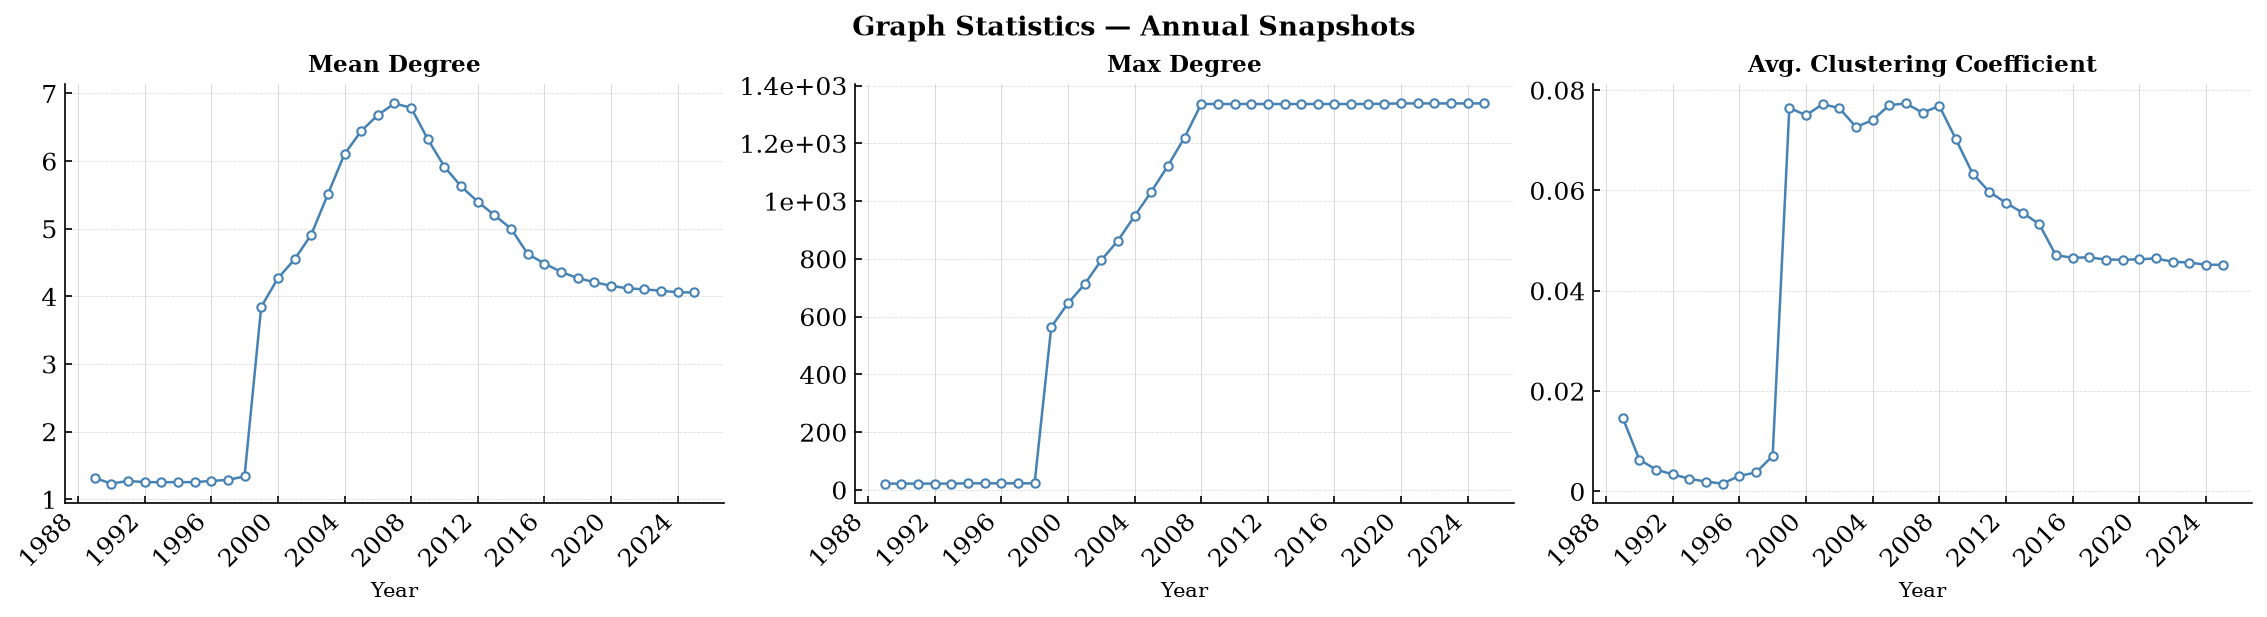

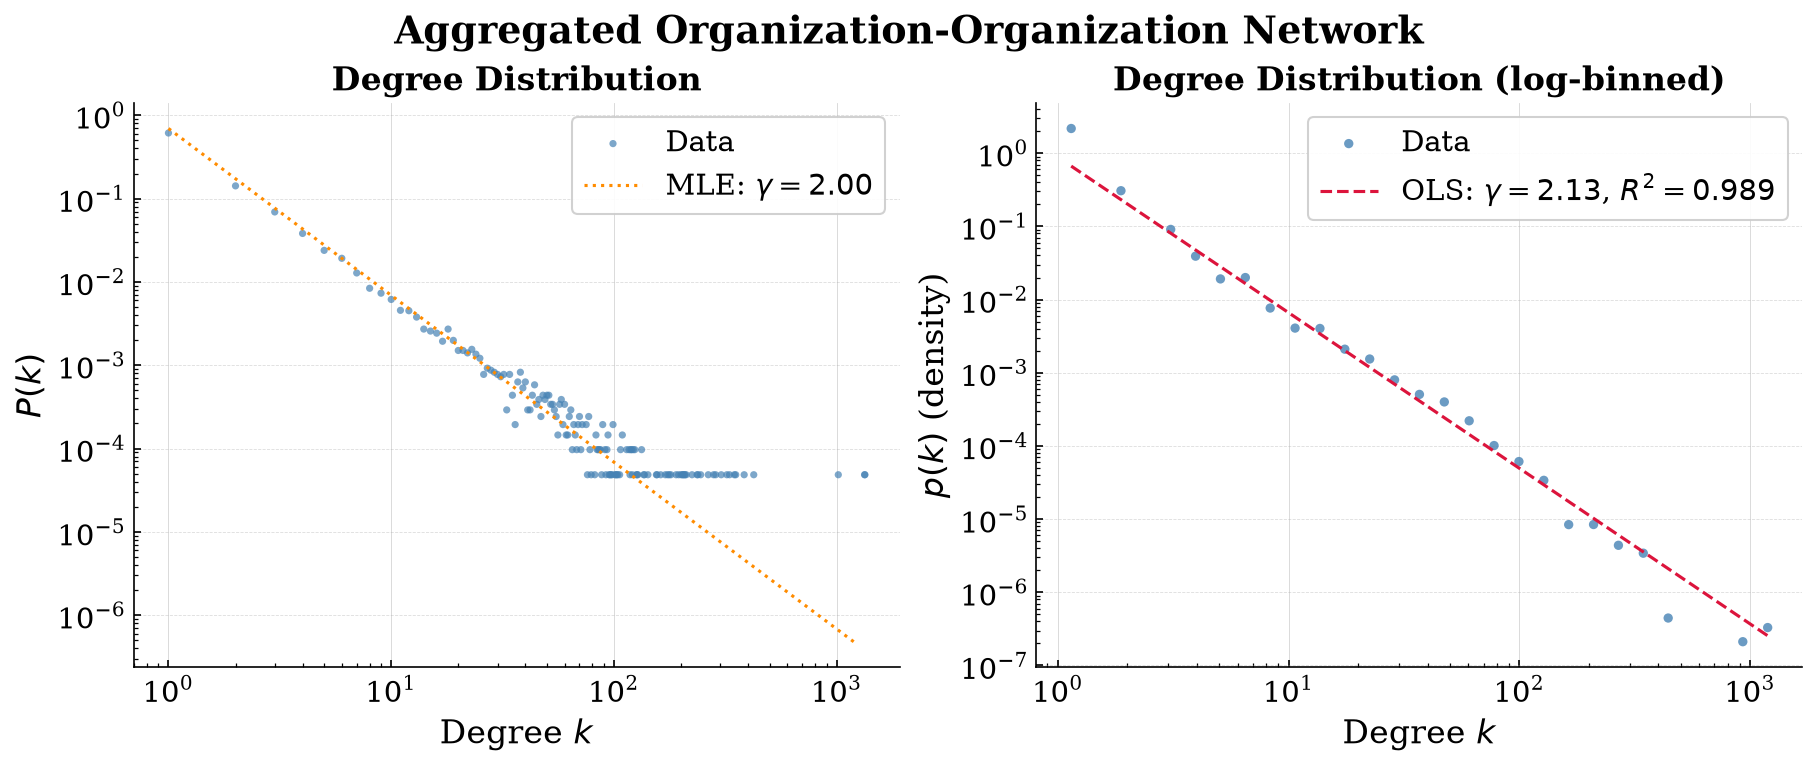

OLS (log-binned): gamma = 2.126, R² = 0.989
MLE (raw sequence): gamma = 2.002, xmin = 1.0


In [21]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/o2o_degree_distribution'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        yearly_stats_o2o_start, D_o2o_start, G_o2o_start = pickle.load(f)
else:
    rel_dicts = [has_start_o2o, has_start_end_o2o]
    yearly_stats_o2o_start, D_o2o_start, G_o2o_start = GraphStats_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                          random_seed=42)
    data = [yearly_stats_o2o_start, D_o2o_start, G_o2o_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_graph_stats(yearly_stats_o2o_start, save_path='graph_stats_yearly.pdf')
plot_degree_distribution(D_o2o_start, title='Aggregated Organization-Organization Network', save_path='degree_distribution.pdf')

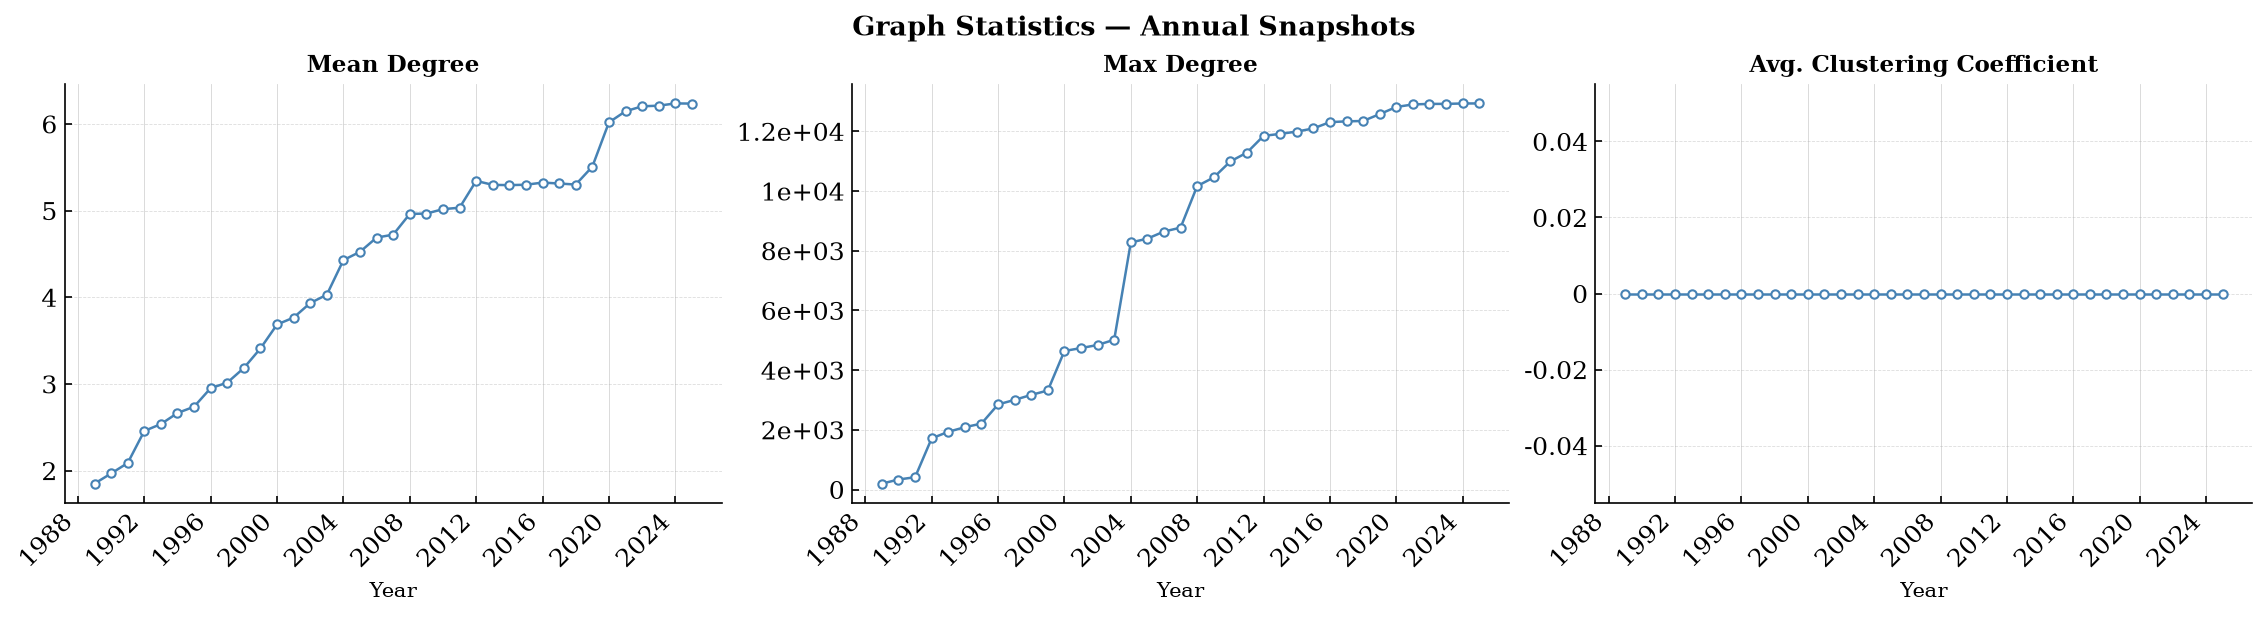

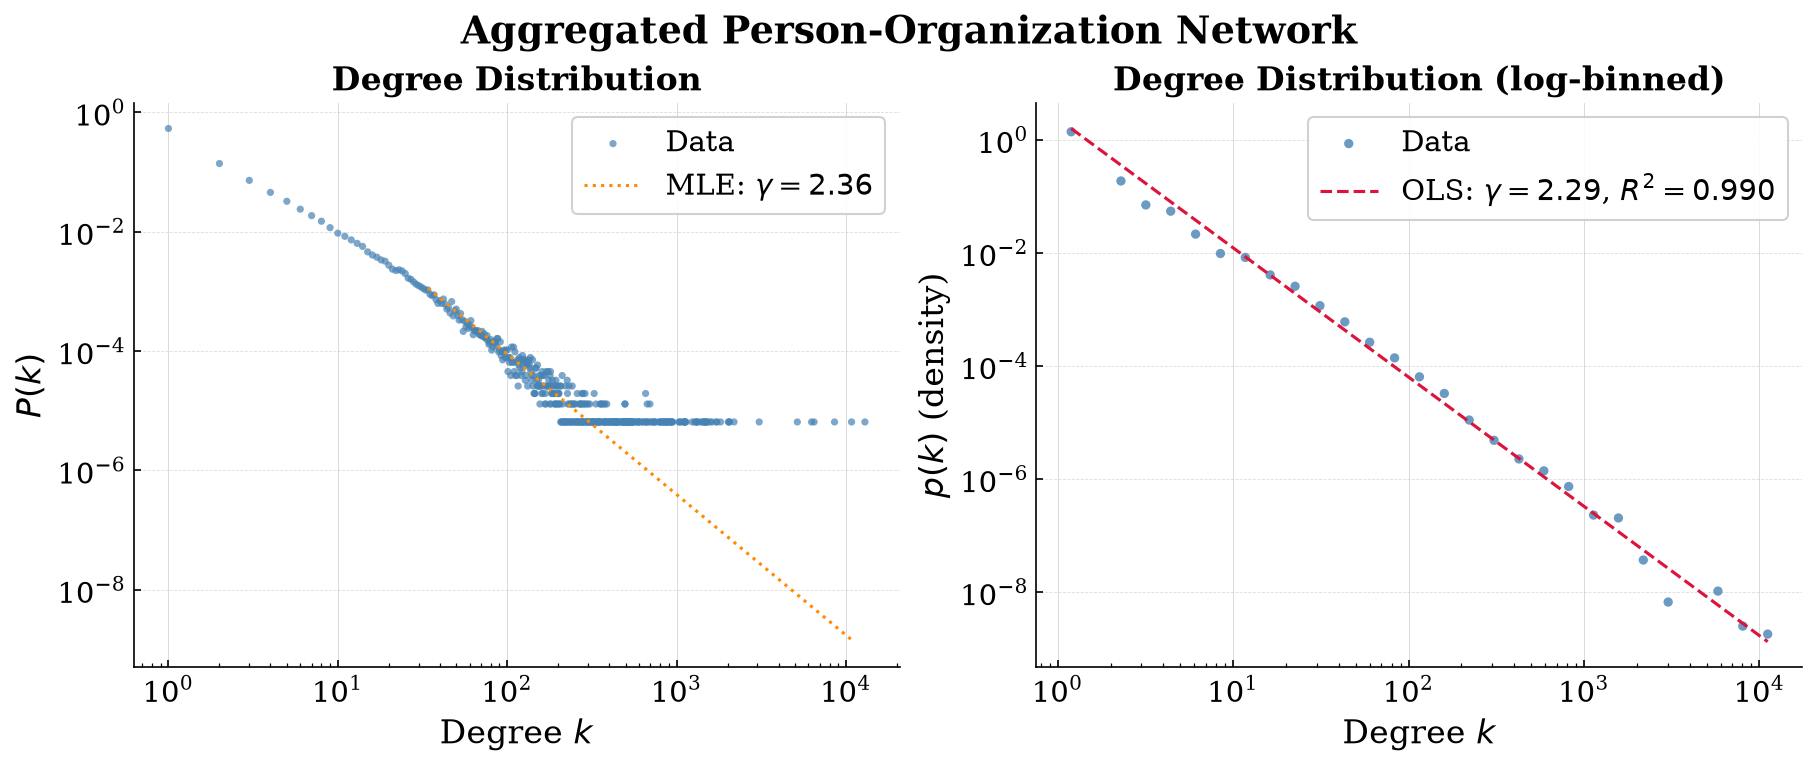

OLS (log-binned): gamma = 2.287, R² = 0.990
MLE (raw sequence): gamma = 2.357, xmin = 34.0


In [22]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/p2o_degree_distribution'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        yearly_stats_p2o_start, D_p2o_start, G_p2o_start = pickle.load(f)
else:
    rel_dicts = [has_start_p2o, has_start_end_p2o]
    yearly_stats_p2o_start, D_p2o_start, G_p2o_start = GraphStats_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                          random_seed=42)
    data = [yearly_stats_p2o_start, D_p2o_start, G_p2o_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_graph_stats(yearly_stats_p2o_start, save_path='graph_stats_yearly.pdf')
plot_degree_distribution(D_p2o_start, title='Aggregated Person-Organization Network', save_path='degree_distribution.pdf')

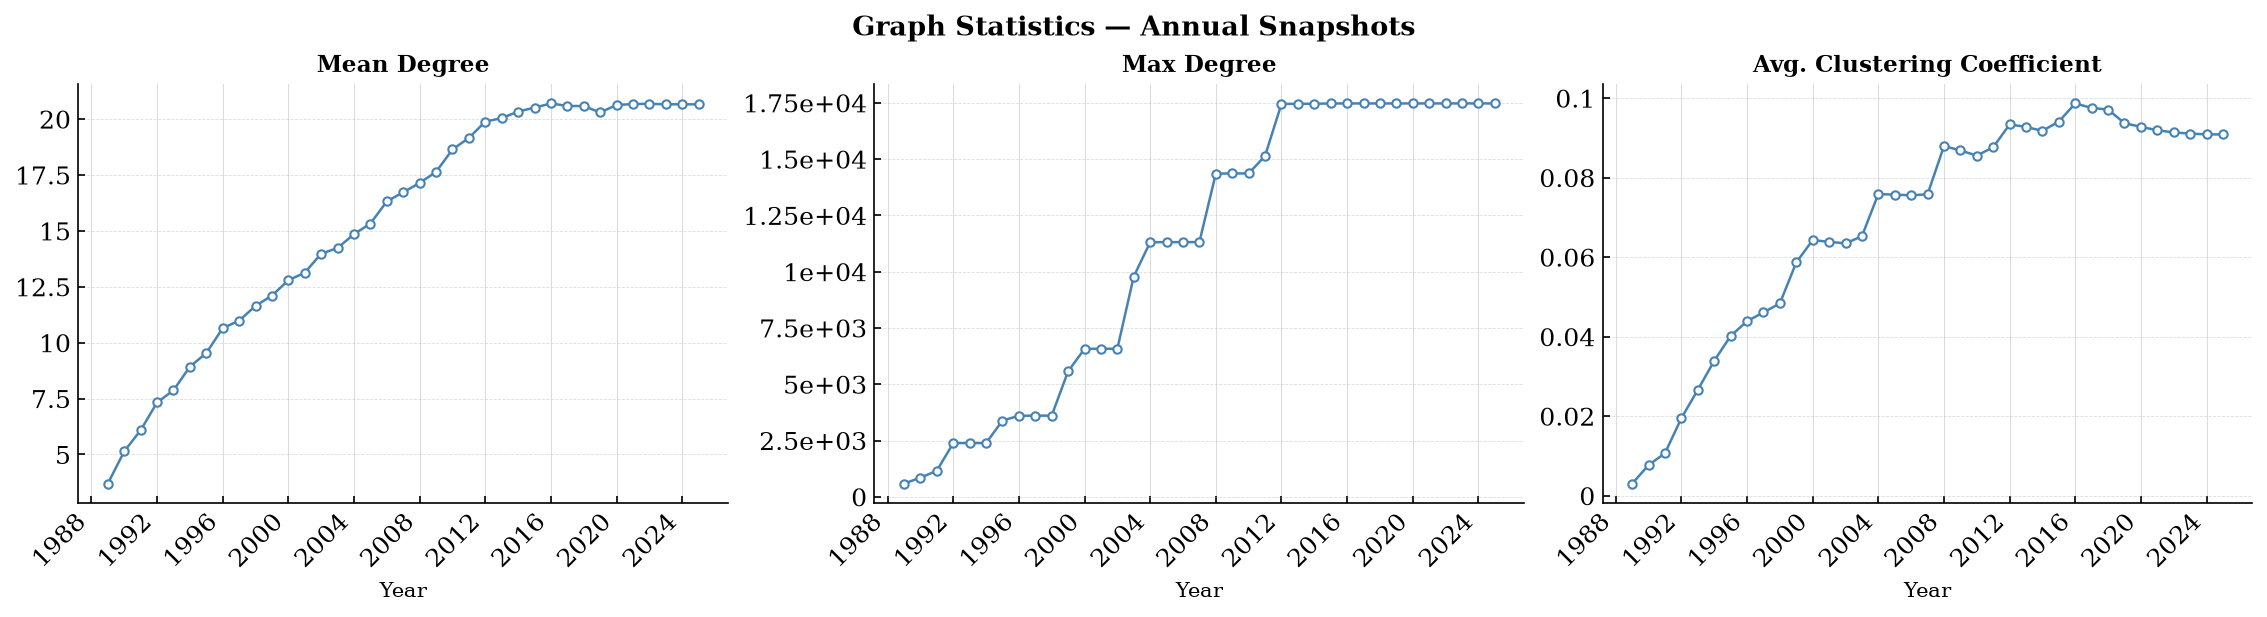

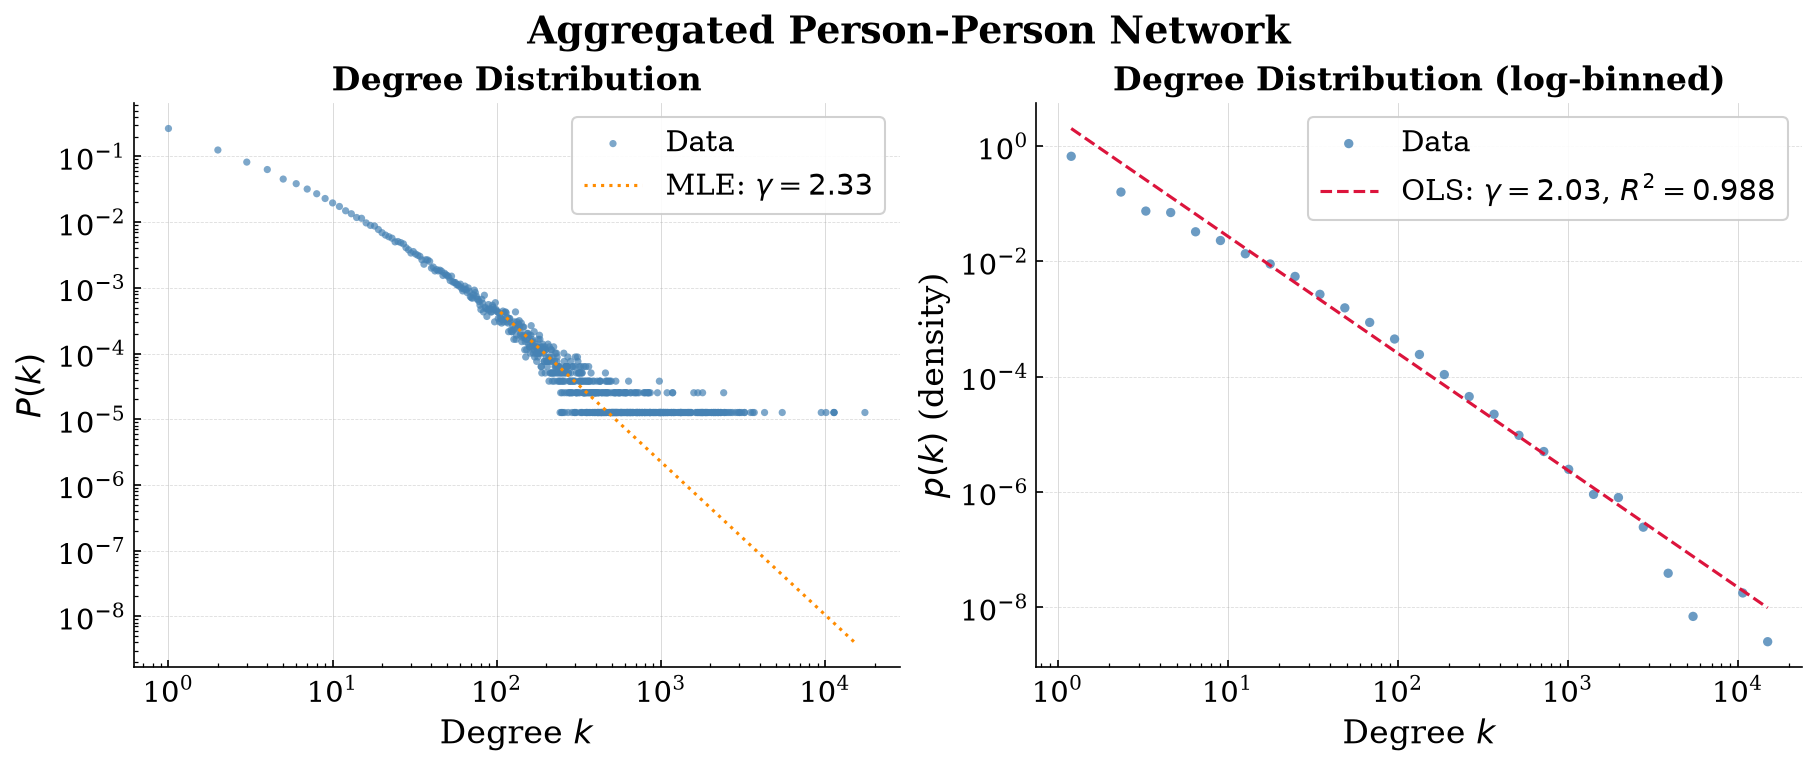

OLS (log-binned): gamma = 2.030, R² = 0.988
MLE (raw sequence): gamma = 2.330, xmin = 105.0


In [23]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/p2p_degree_distribution'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        yearly_stats_p2p_start, D_p2p_start, G_p2p_start = pickle.load(f)
else:
    rel_dicts = [has_start_p2p, has_start_end_p2p]
    yearly_stats_p2p_start, D_p2p_start, G_p2p_start = GraphStats_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                          random_seed=42)
    data = [yearly_stats_p2p_start, D_p2p_start, G_p2p_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_graph_stats(yearly_stats_p2p_start, save_path='graph_stats_yearly.pdf')
plot_degree_distribution(D_p2p_start, title='Aggregated Person-Person Network', save_path='degree_distribution.pdf')

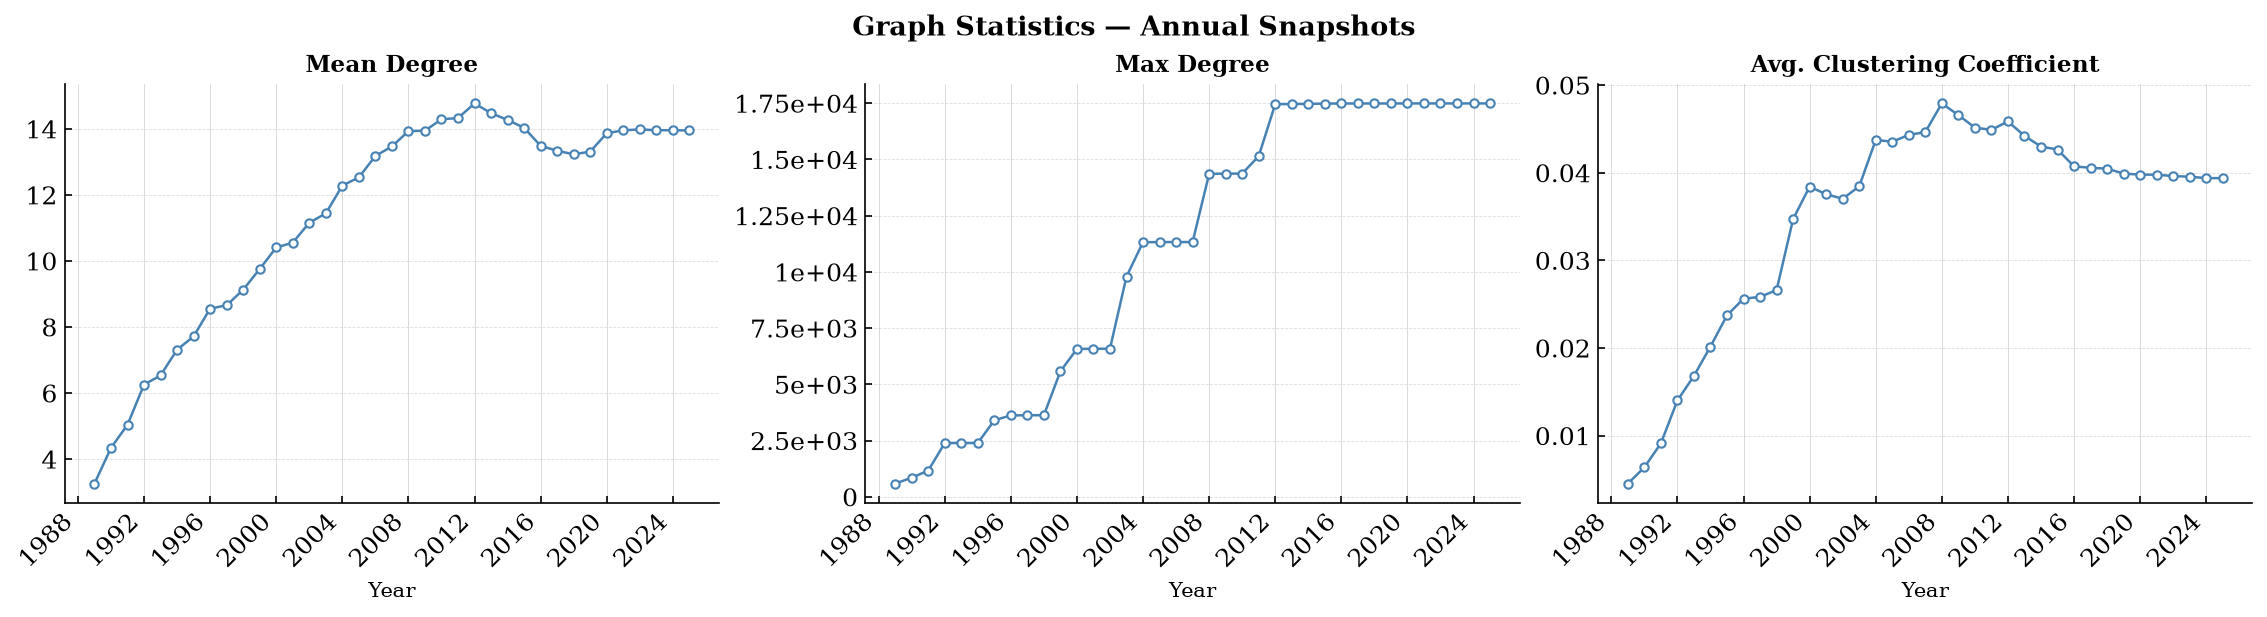

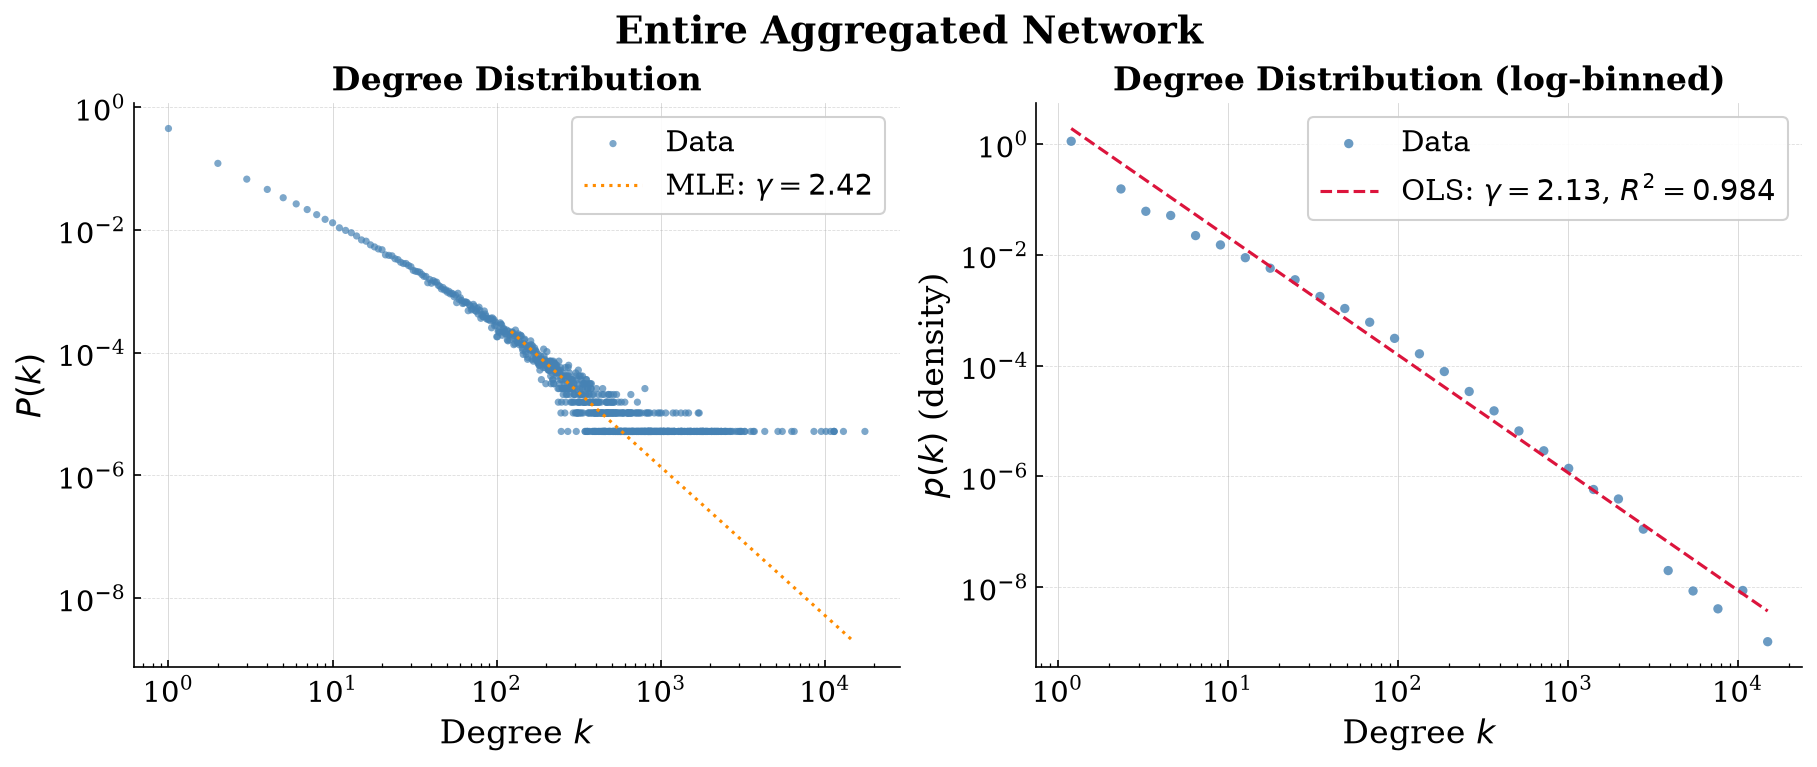

OLS (log-binned): gamma = 2.127, R² = 0.984
MLE (raw sequence): gamma = 2.422, xmin = 122.0


In [24]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/all_degree_distribution'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        yearly_stats_all_start, D_all_start, G_all_start = pickle.load(f)
else:
    rel_dicts = [has_start_p2p, has_start_end_p2p,
                 has_start_p2o, has_start_end_p2o,
                 has_start_o2o, has_start_end_o2o]
    yearly_stats_all_start, D_all_start, G_all_start = GraphStats_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                          random_seed=42)
    data = [yearly_stats_all_start, D_all_start, G_all_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_graph_stats(yearly_stats_all_start, save_path='graph_stats_yearly.pdf')
plot_degree_distribution(D_all_start, title='Entire Aggregated Network', save_path='degree_distribution.pdf')

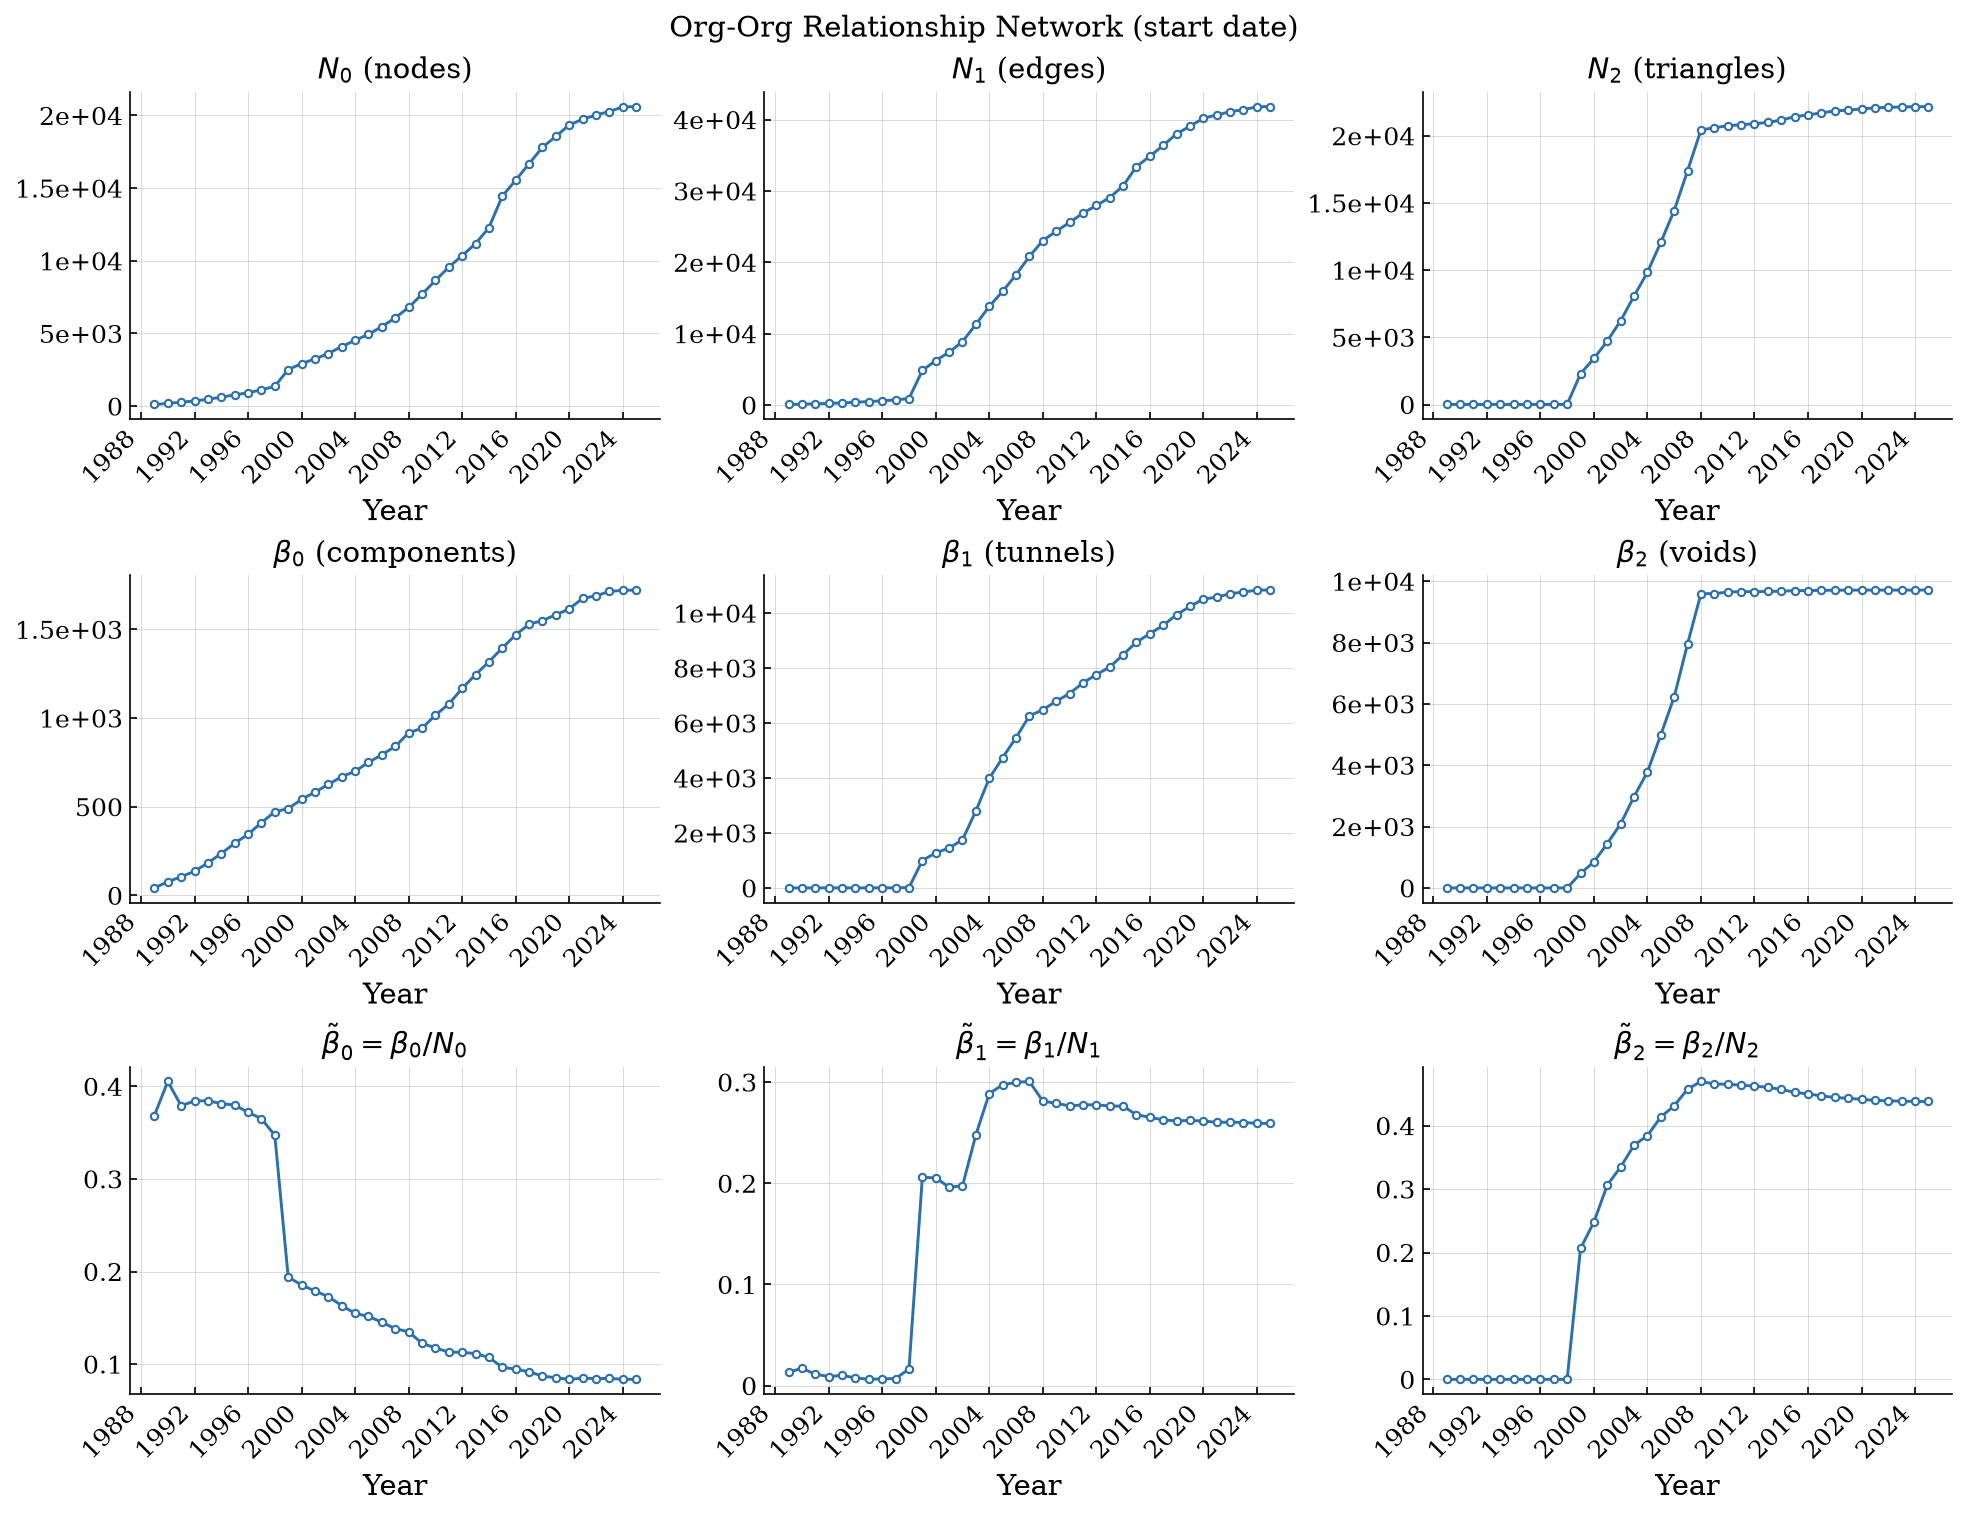

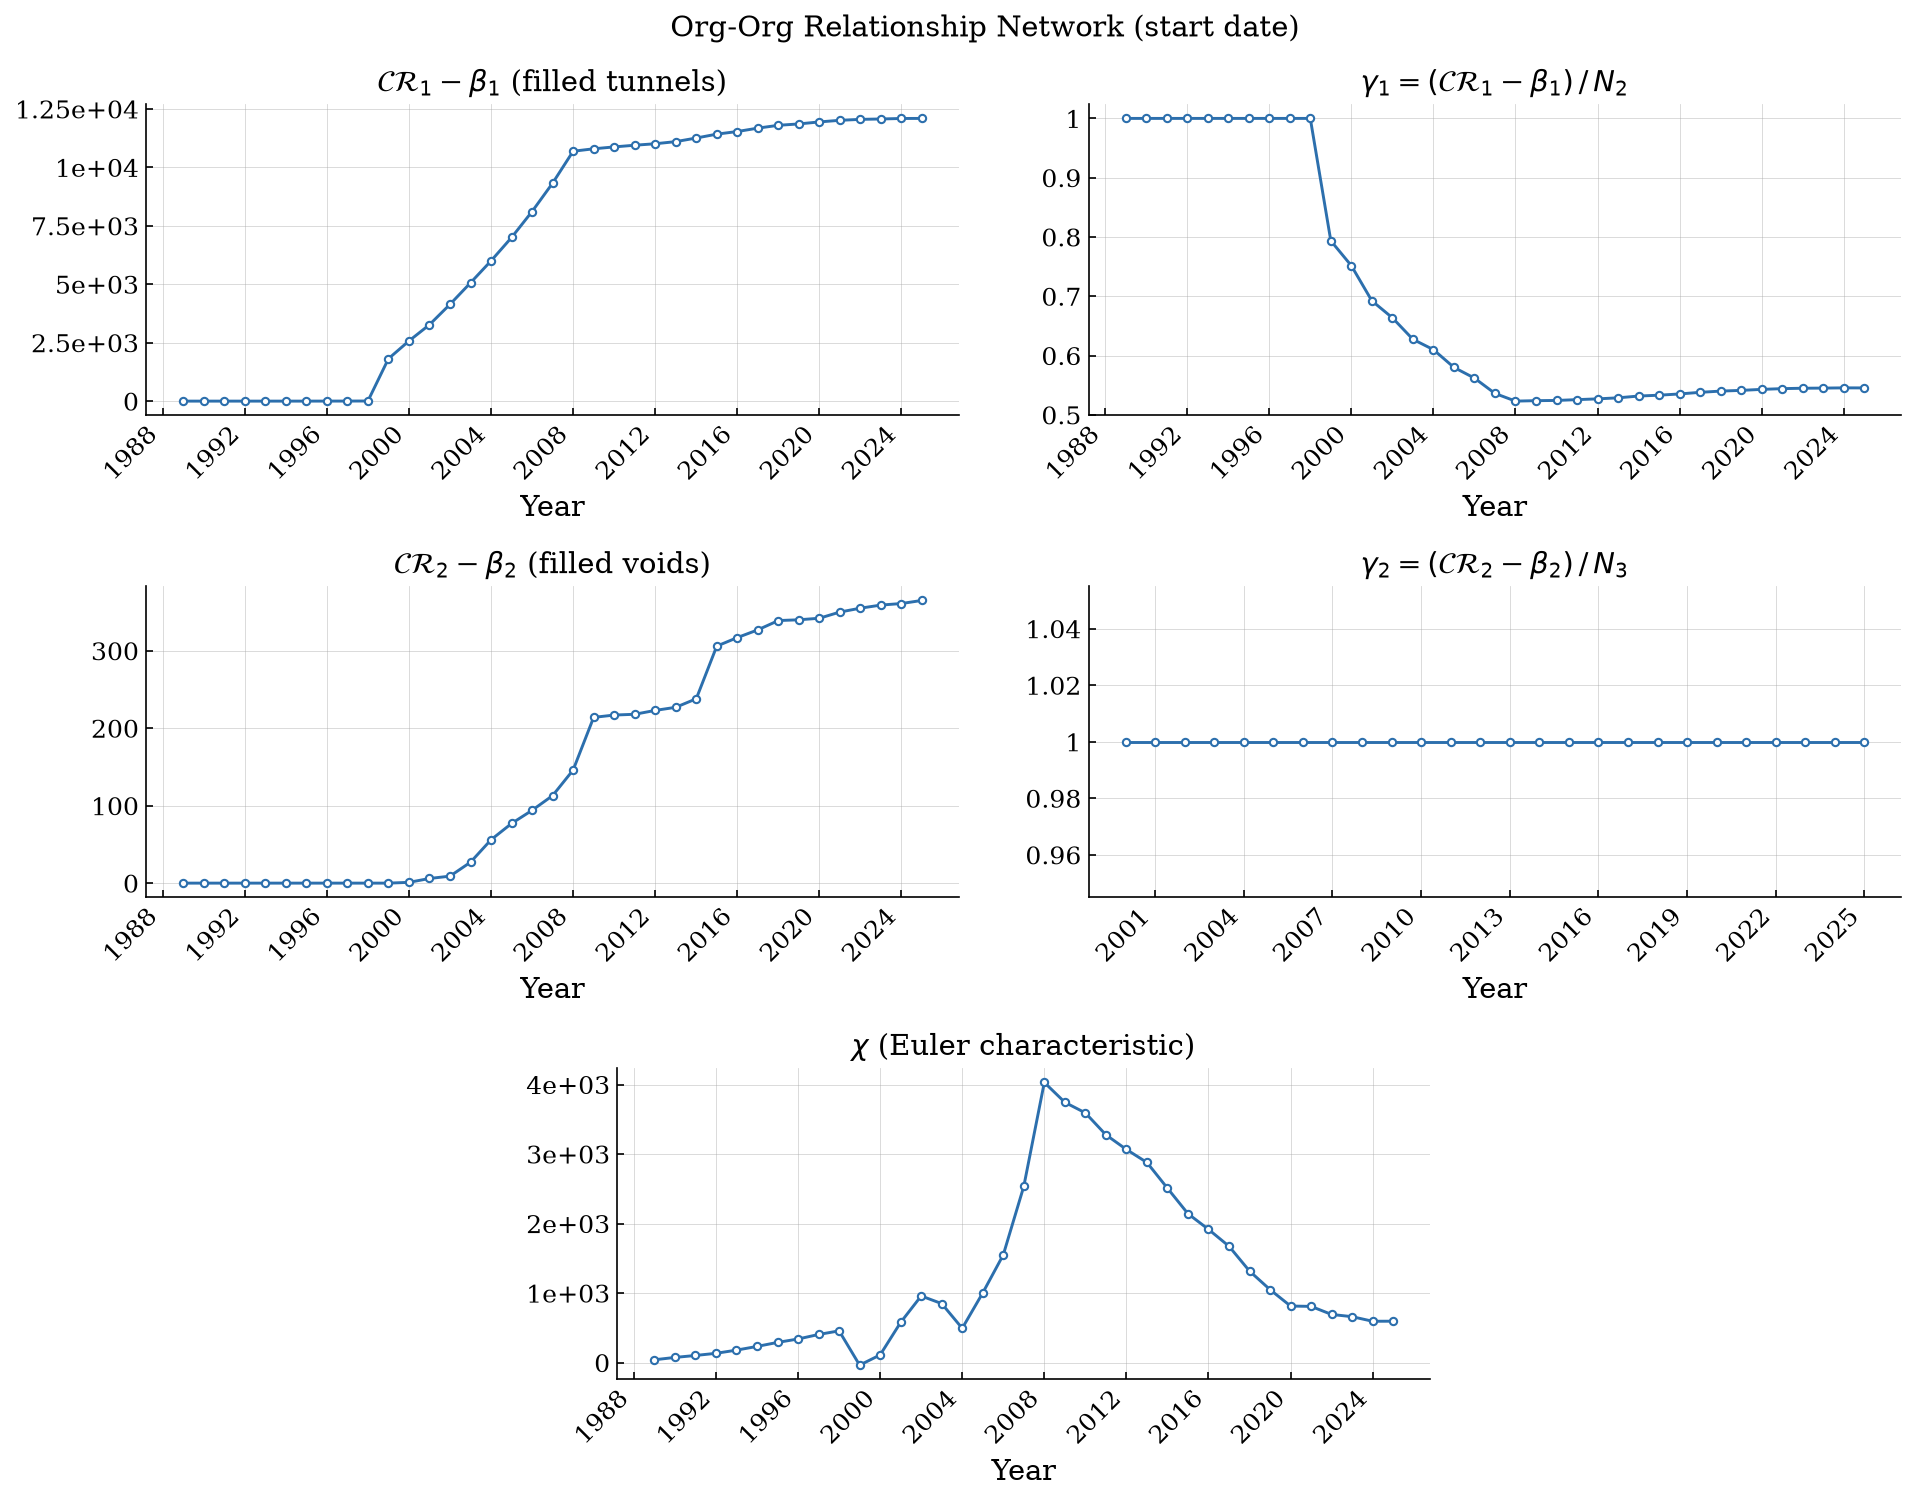

In [25]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/o2o_start_Betti'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        Betti_o2o_start, SimplexCounts_o2o_start, Euler_o2o_start, cycleR_o2o_start, dates_o2o_start = pickle.load(f)
else:
    rel_dicts = [has_start_o2o, has_start_end_o2o]
    Betti_o2o_start, SimplexCounts_o2o_start, Euler_o2o_start, cycleR_o2o_start, dates_o2o_start = PH_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                                                                    maxDim=np.inf, random_seed=42)
    data = [Betti_o2o_start, SimplexCounts_o2o_start, Euler_o2o_start, cycleR_o2o_start, dates_o2o_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_ph_yearly(Betti_o2o_start, SimplexCounts_o2o_start, Euler_o2o_start, cycleR_o2o_start, dates_o2o_start,
                   save_path='ph_yearly.pdf',title='Org-Org Relationship Network (start date)')

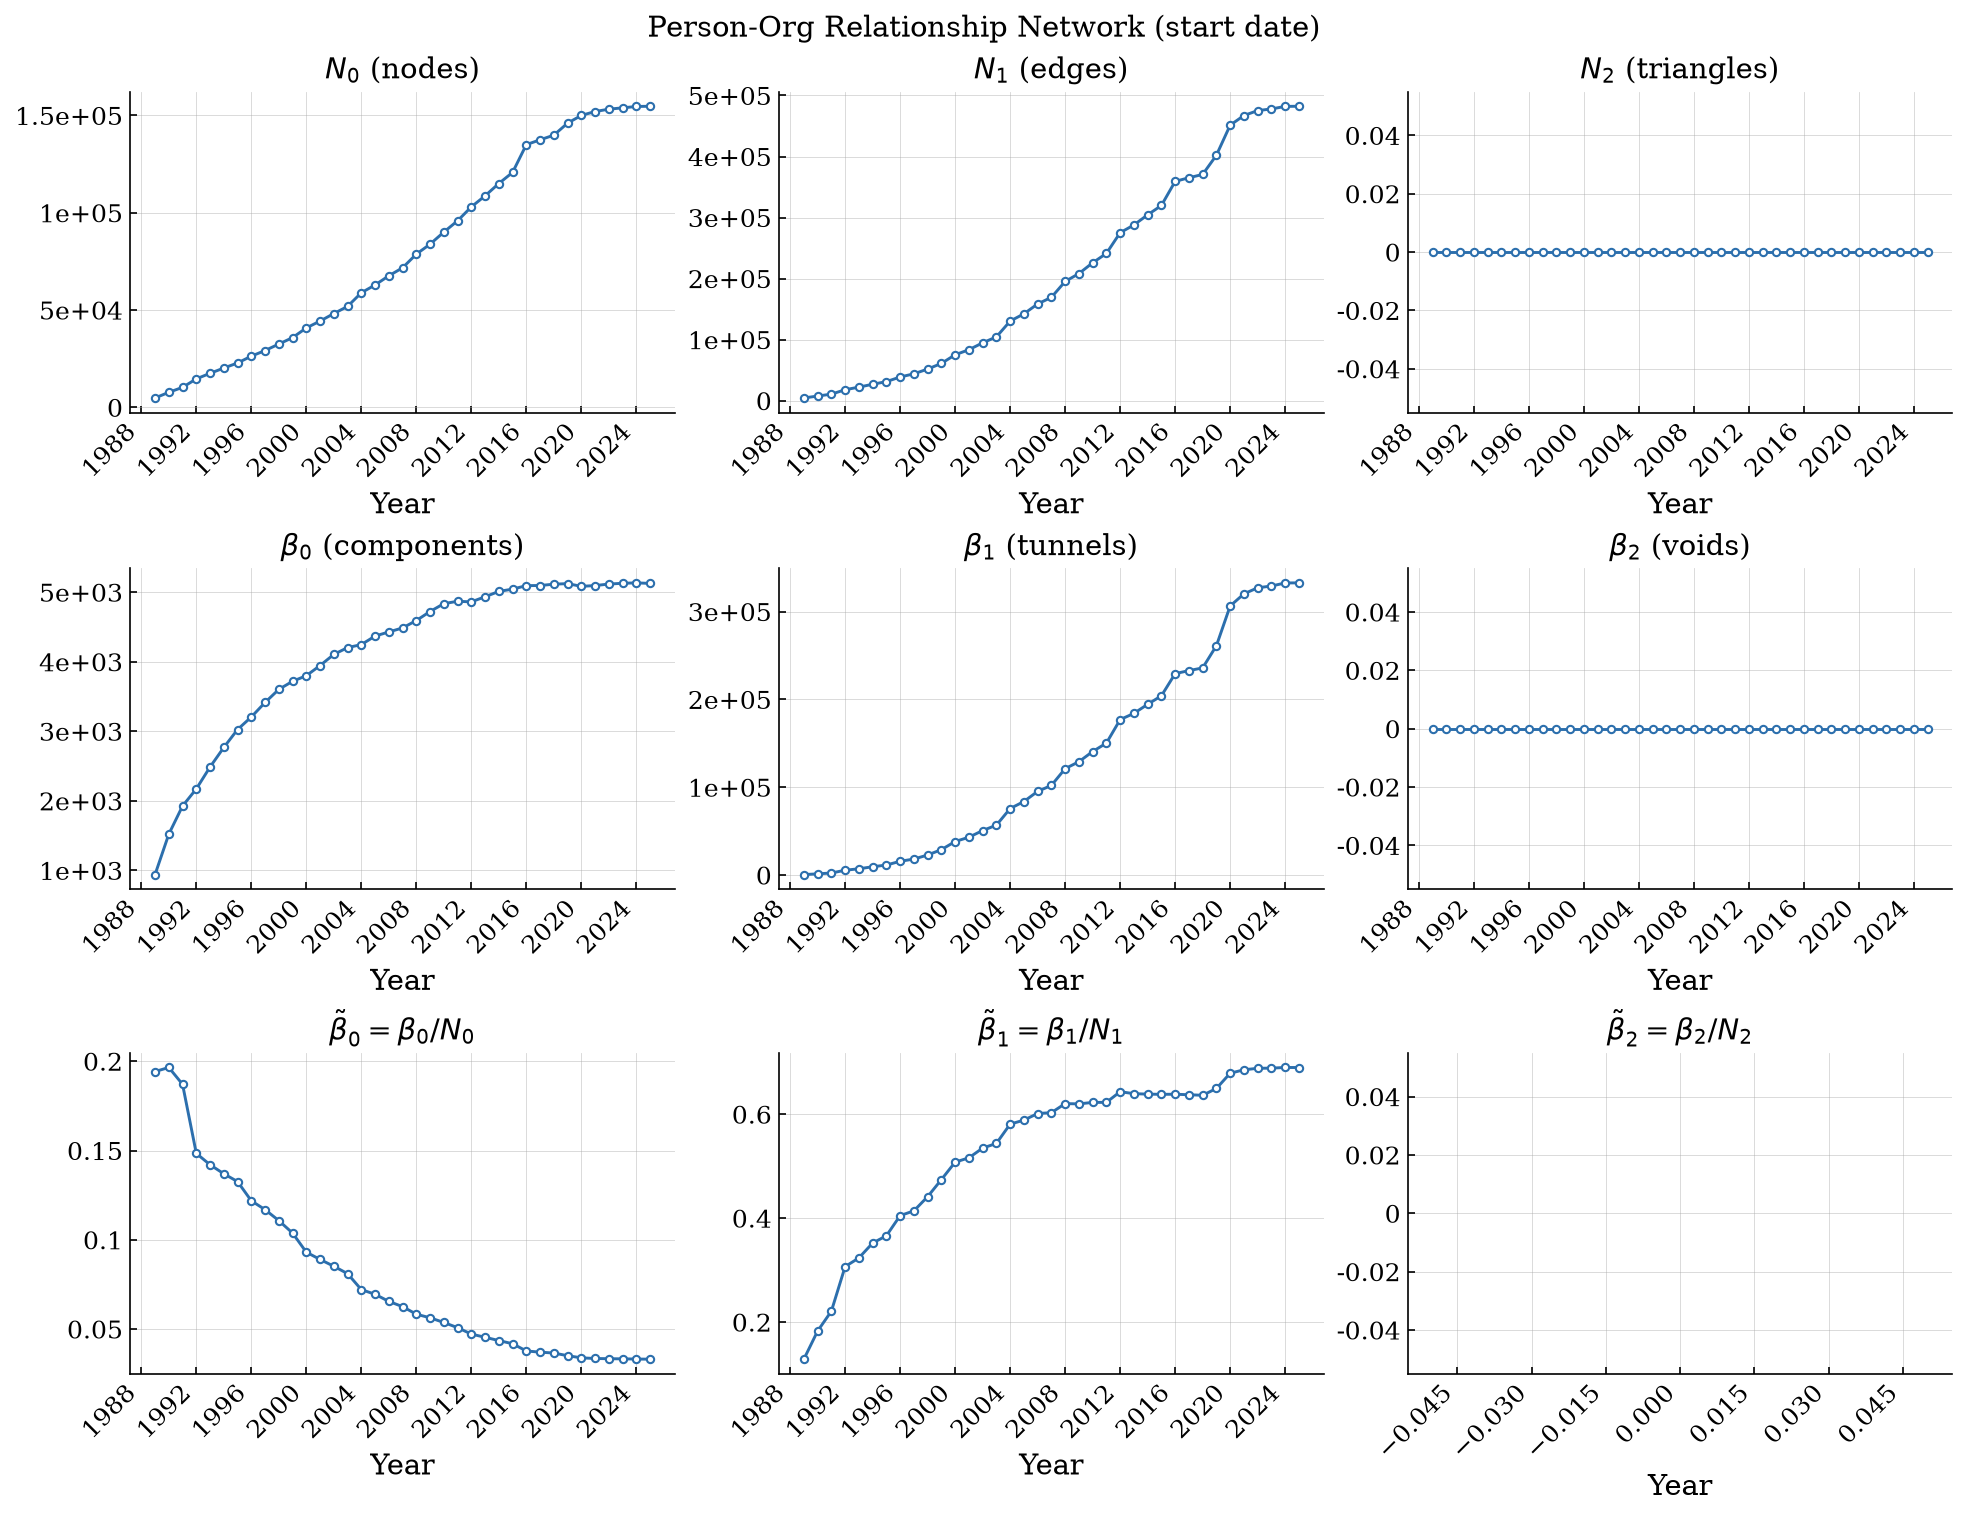

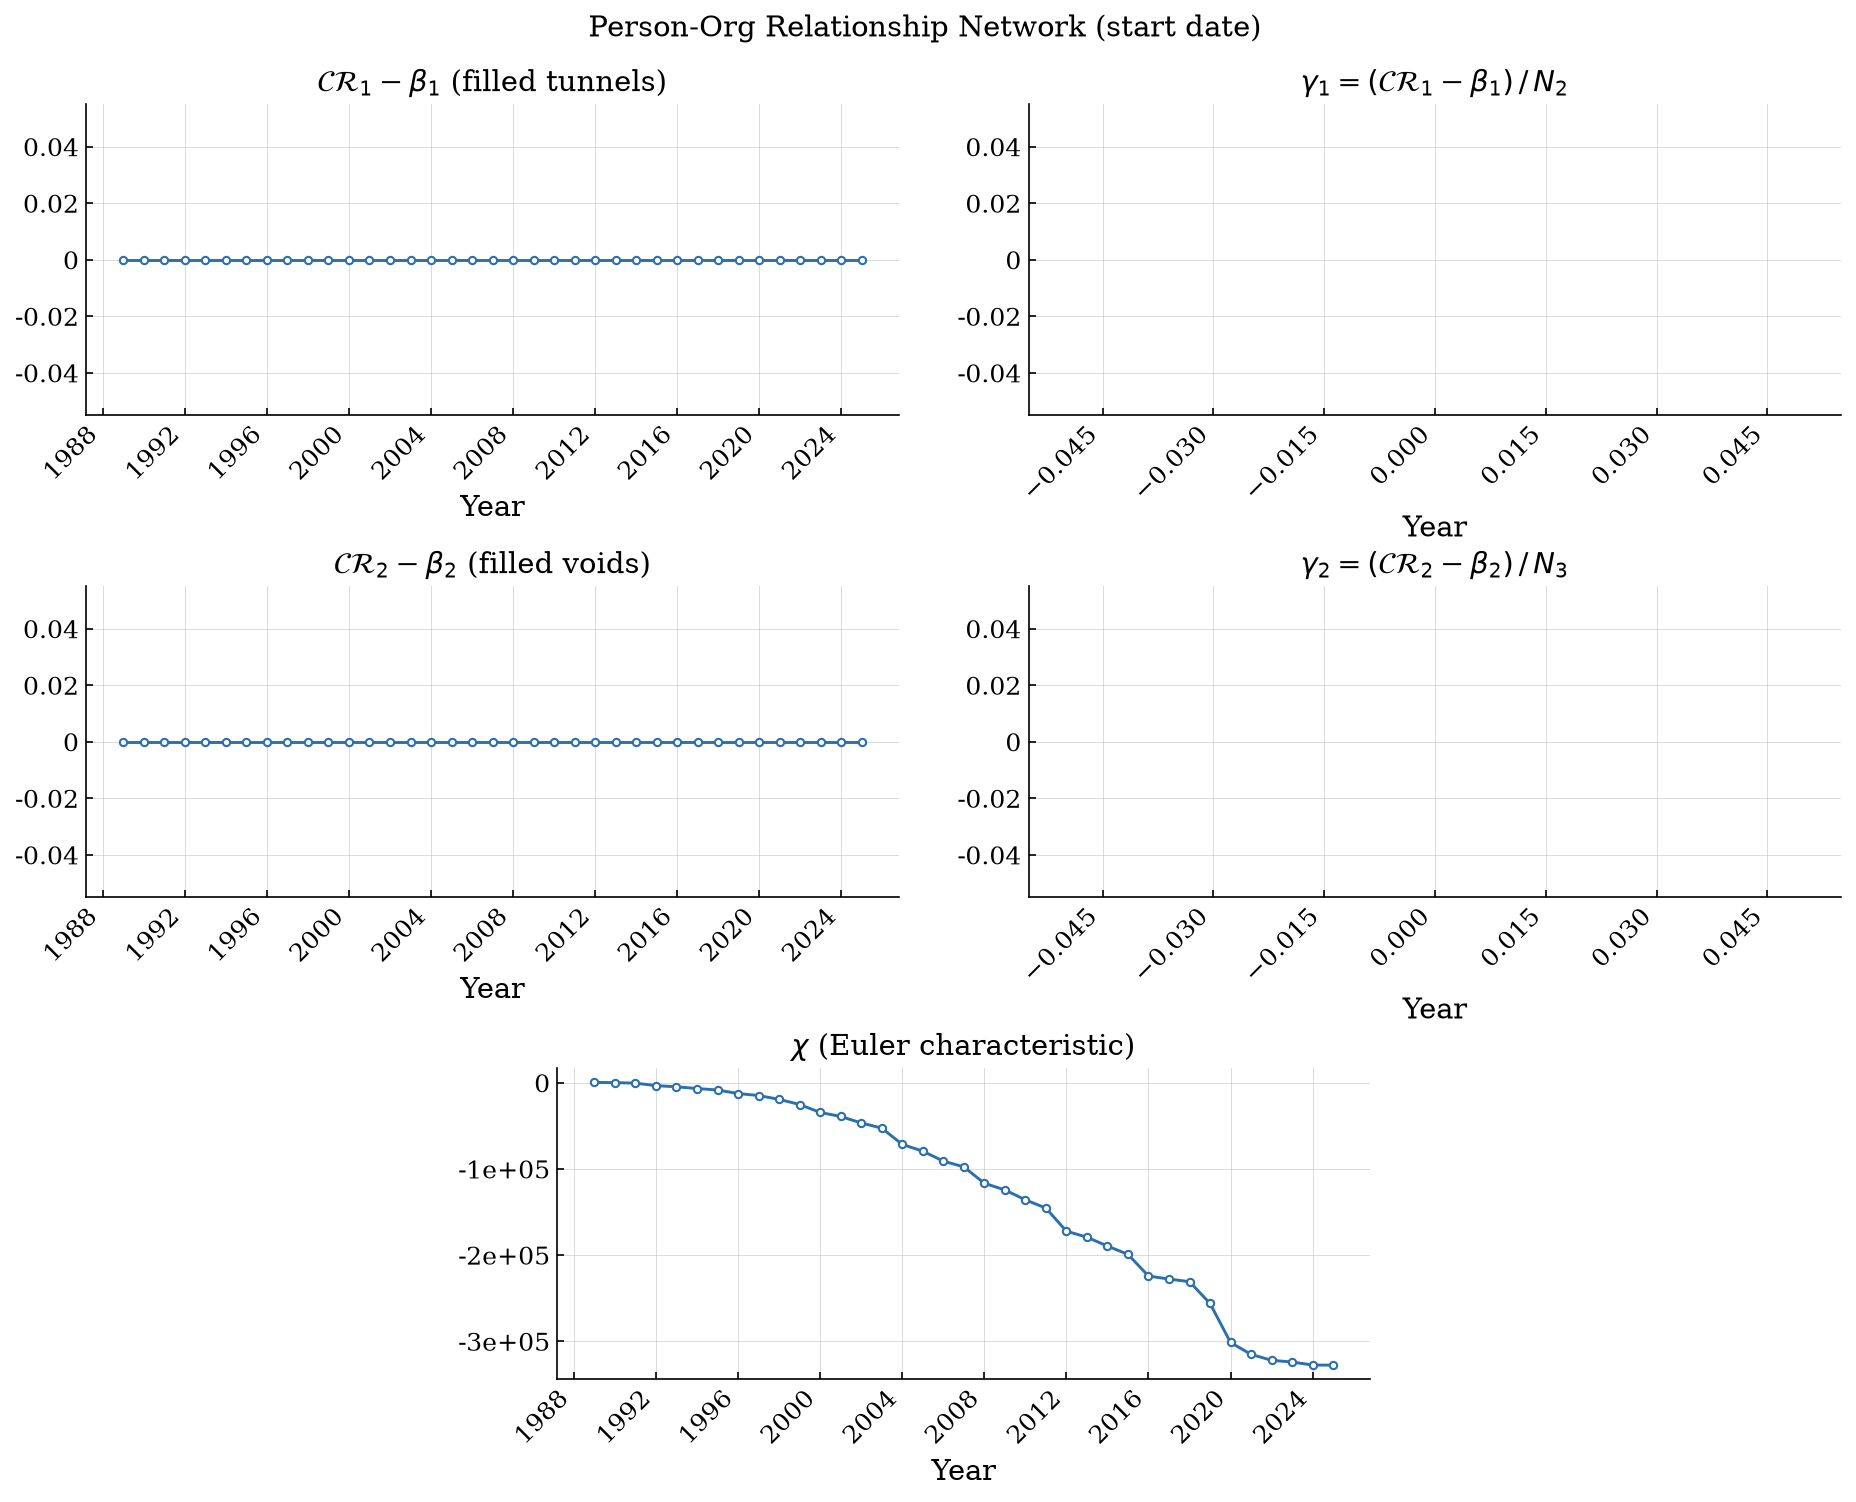

In [26]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/p2o_start_Betti'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        Betti_p2o_start, SimplexCounts_p2o_start, Euler_p2o_start, cycleR_p2o_start, dates_p2o_start = pickle.load(f)
else:
    rel_dicts = [has_start_p2o, has_start_end_p2o]
    Betti_p2o_start, SimplexCounts_p2o_start, Euler_p2o_start, cycleR_p2o_start, dates_p2o_start = PH_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                                                                    maxDim=np.inf, random_seed=42)
    data = [Betti_p2o_start, SimplexCounts_p2o_start, Euler_p2o_start, cycleR_p2o_start, dates_p2o_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_ph_yearly(Betti_p2o_start, SimplexCounts_p2o_start, Euler_p2o_start, cycleR_p2o_start, dates_p2o_start,
                   save_path='ph_yearly.pdf',title='Person-Org Relationship Network (start date)')

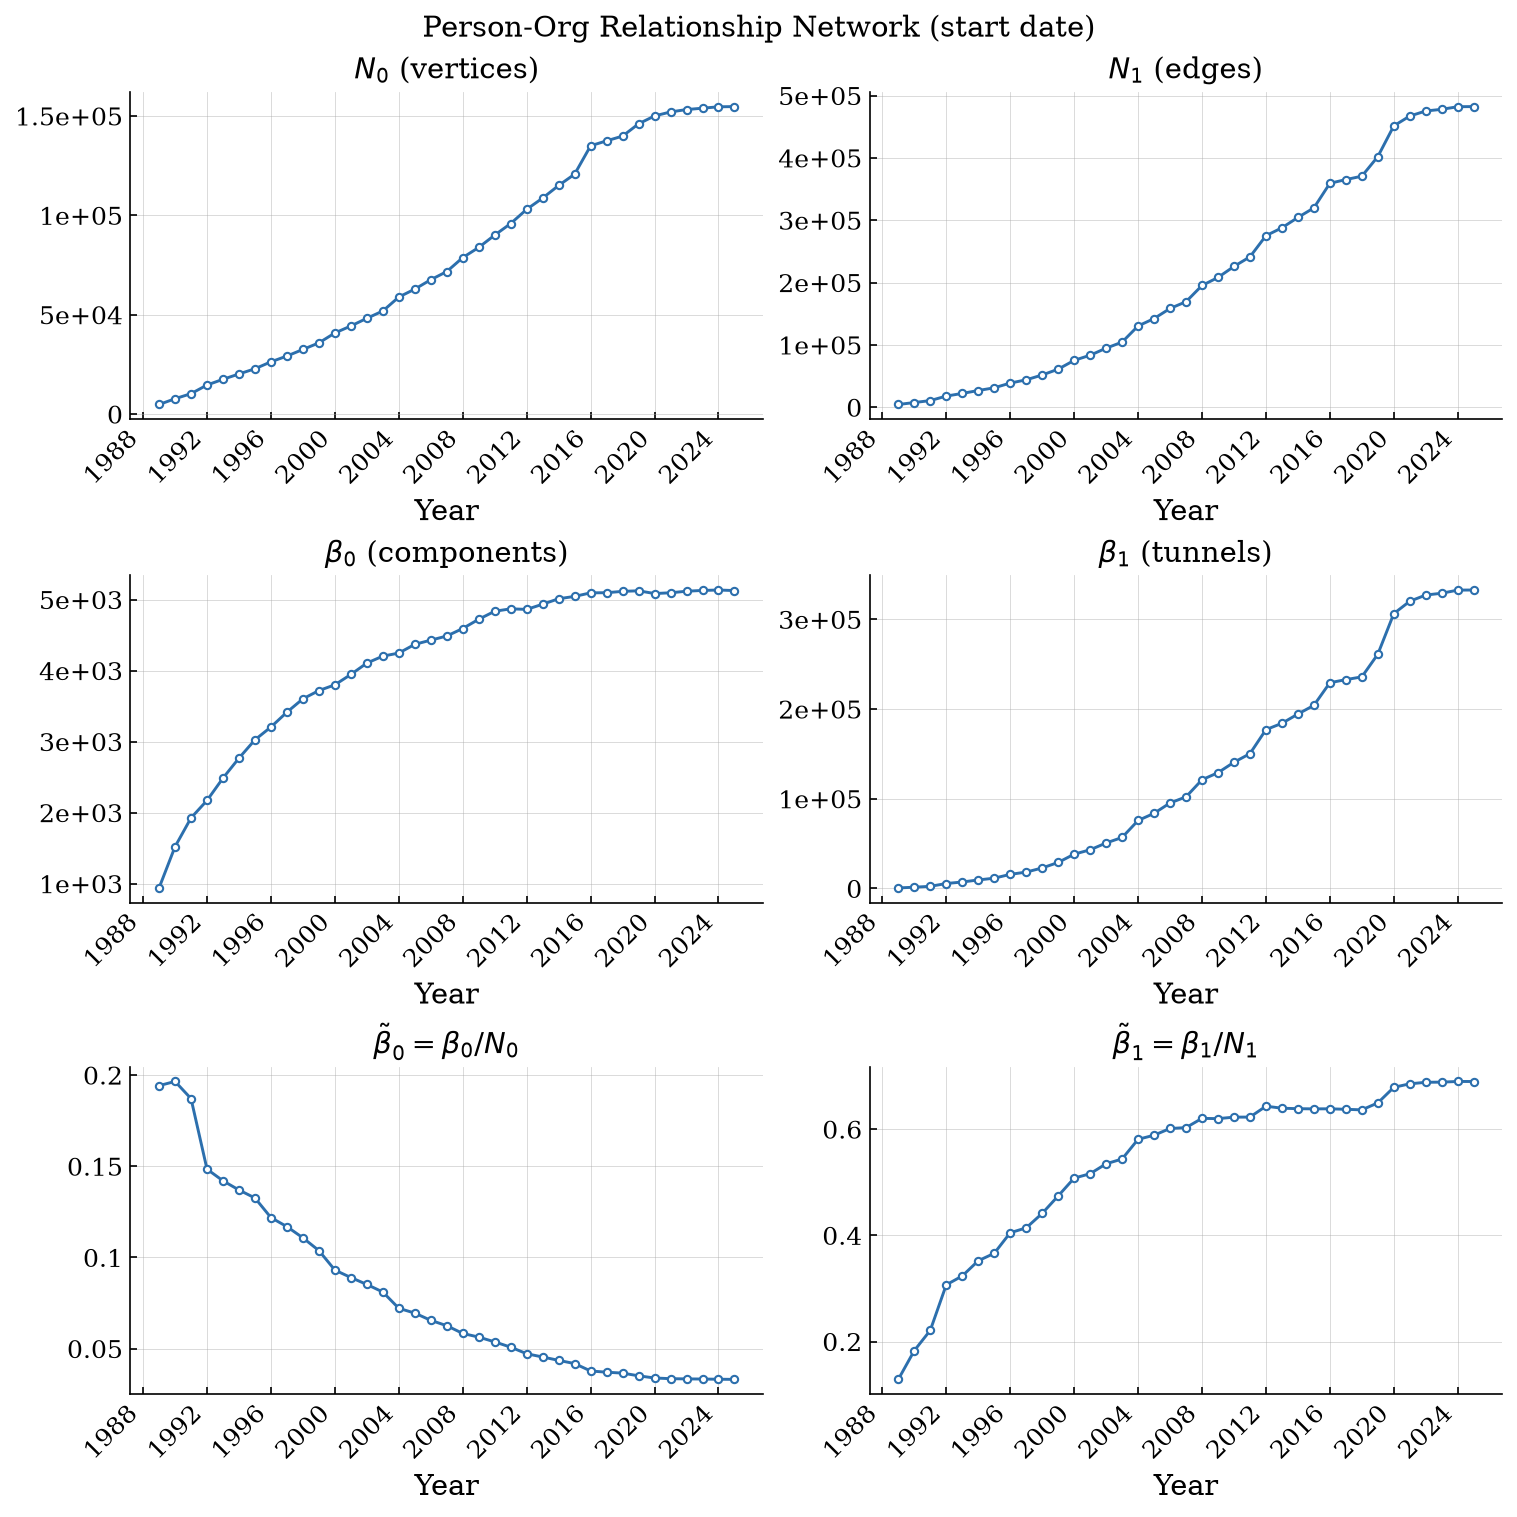

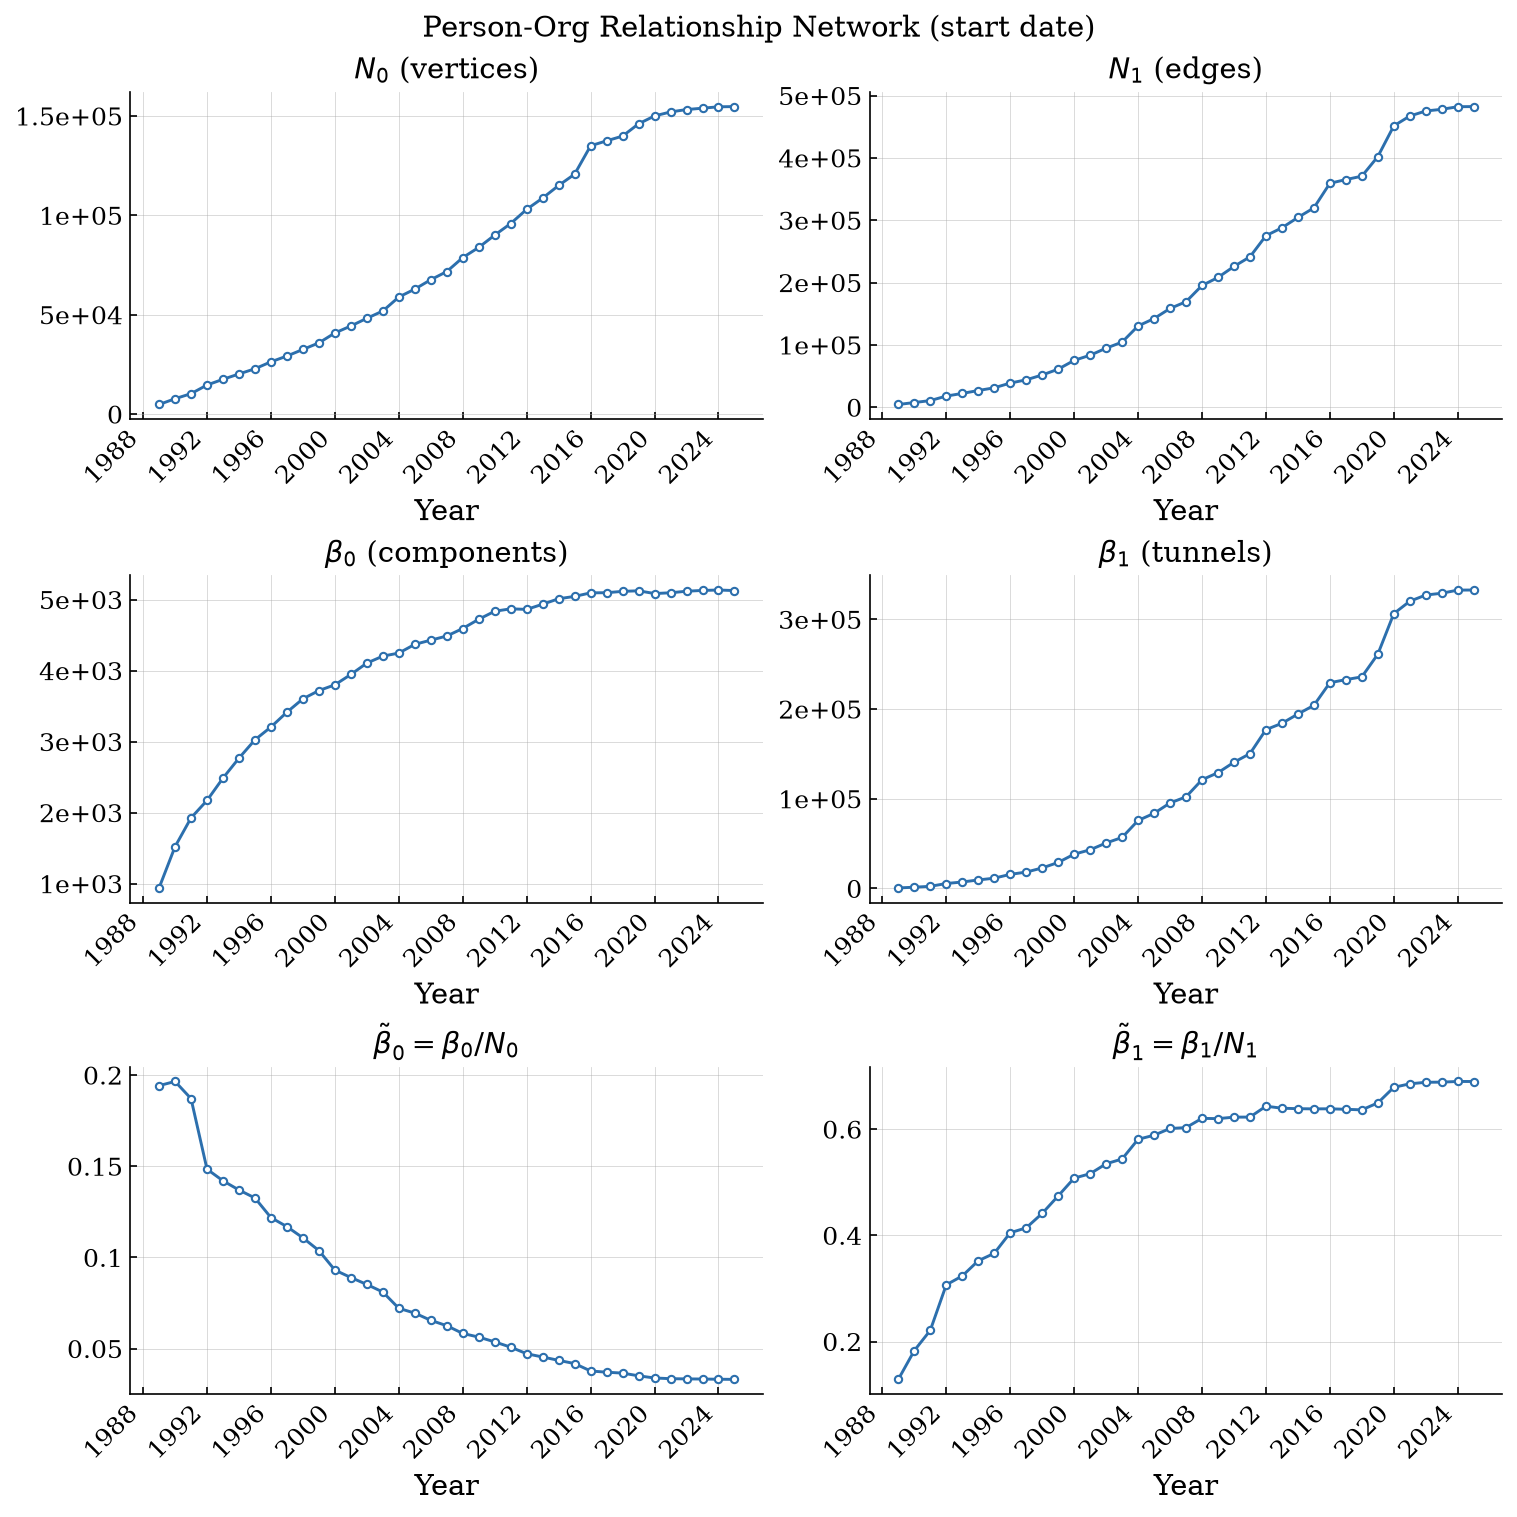

In [27]:
plot_ph_graph(Betti_p2o_start, SimplexCounts_p2o_start, Euler_p2o_start,
              cycleR_p2o_start, dates_p2o_start,
              title='Person-Org Relationship Network (start date)',
              save_path='ph_p2o_start_graph')

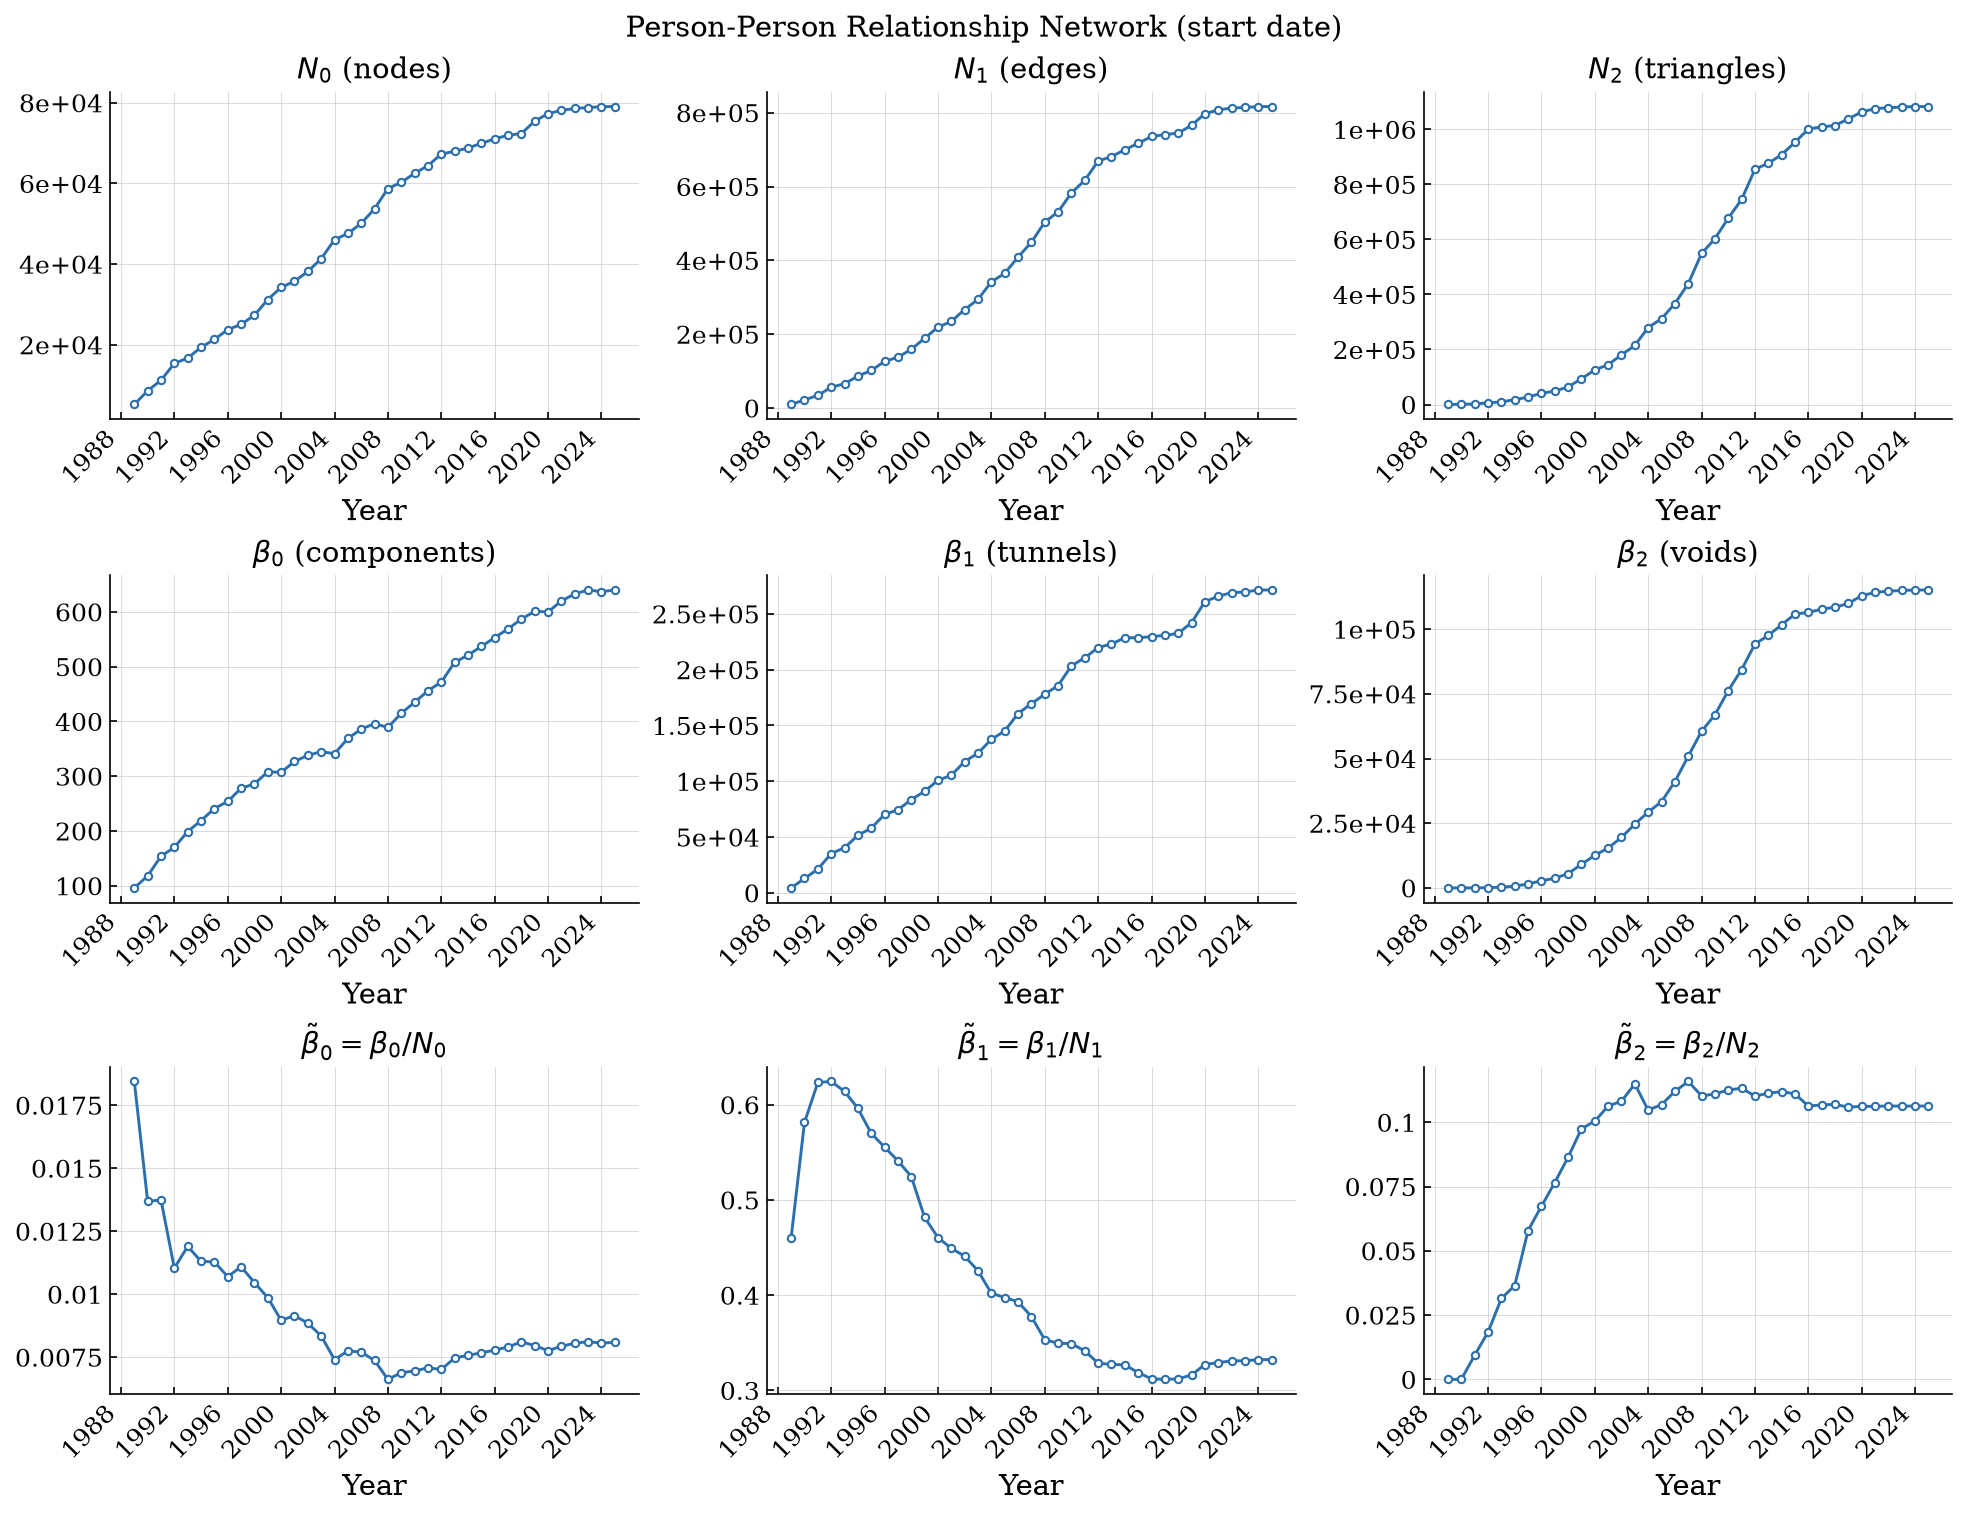

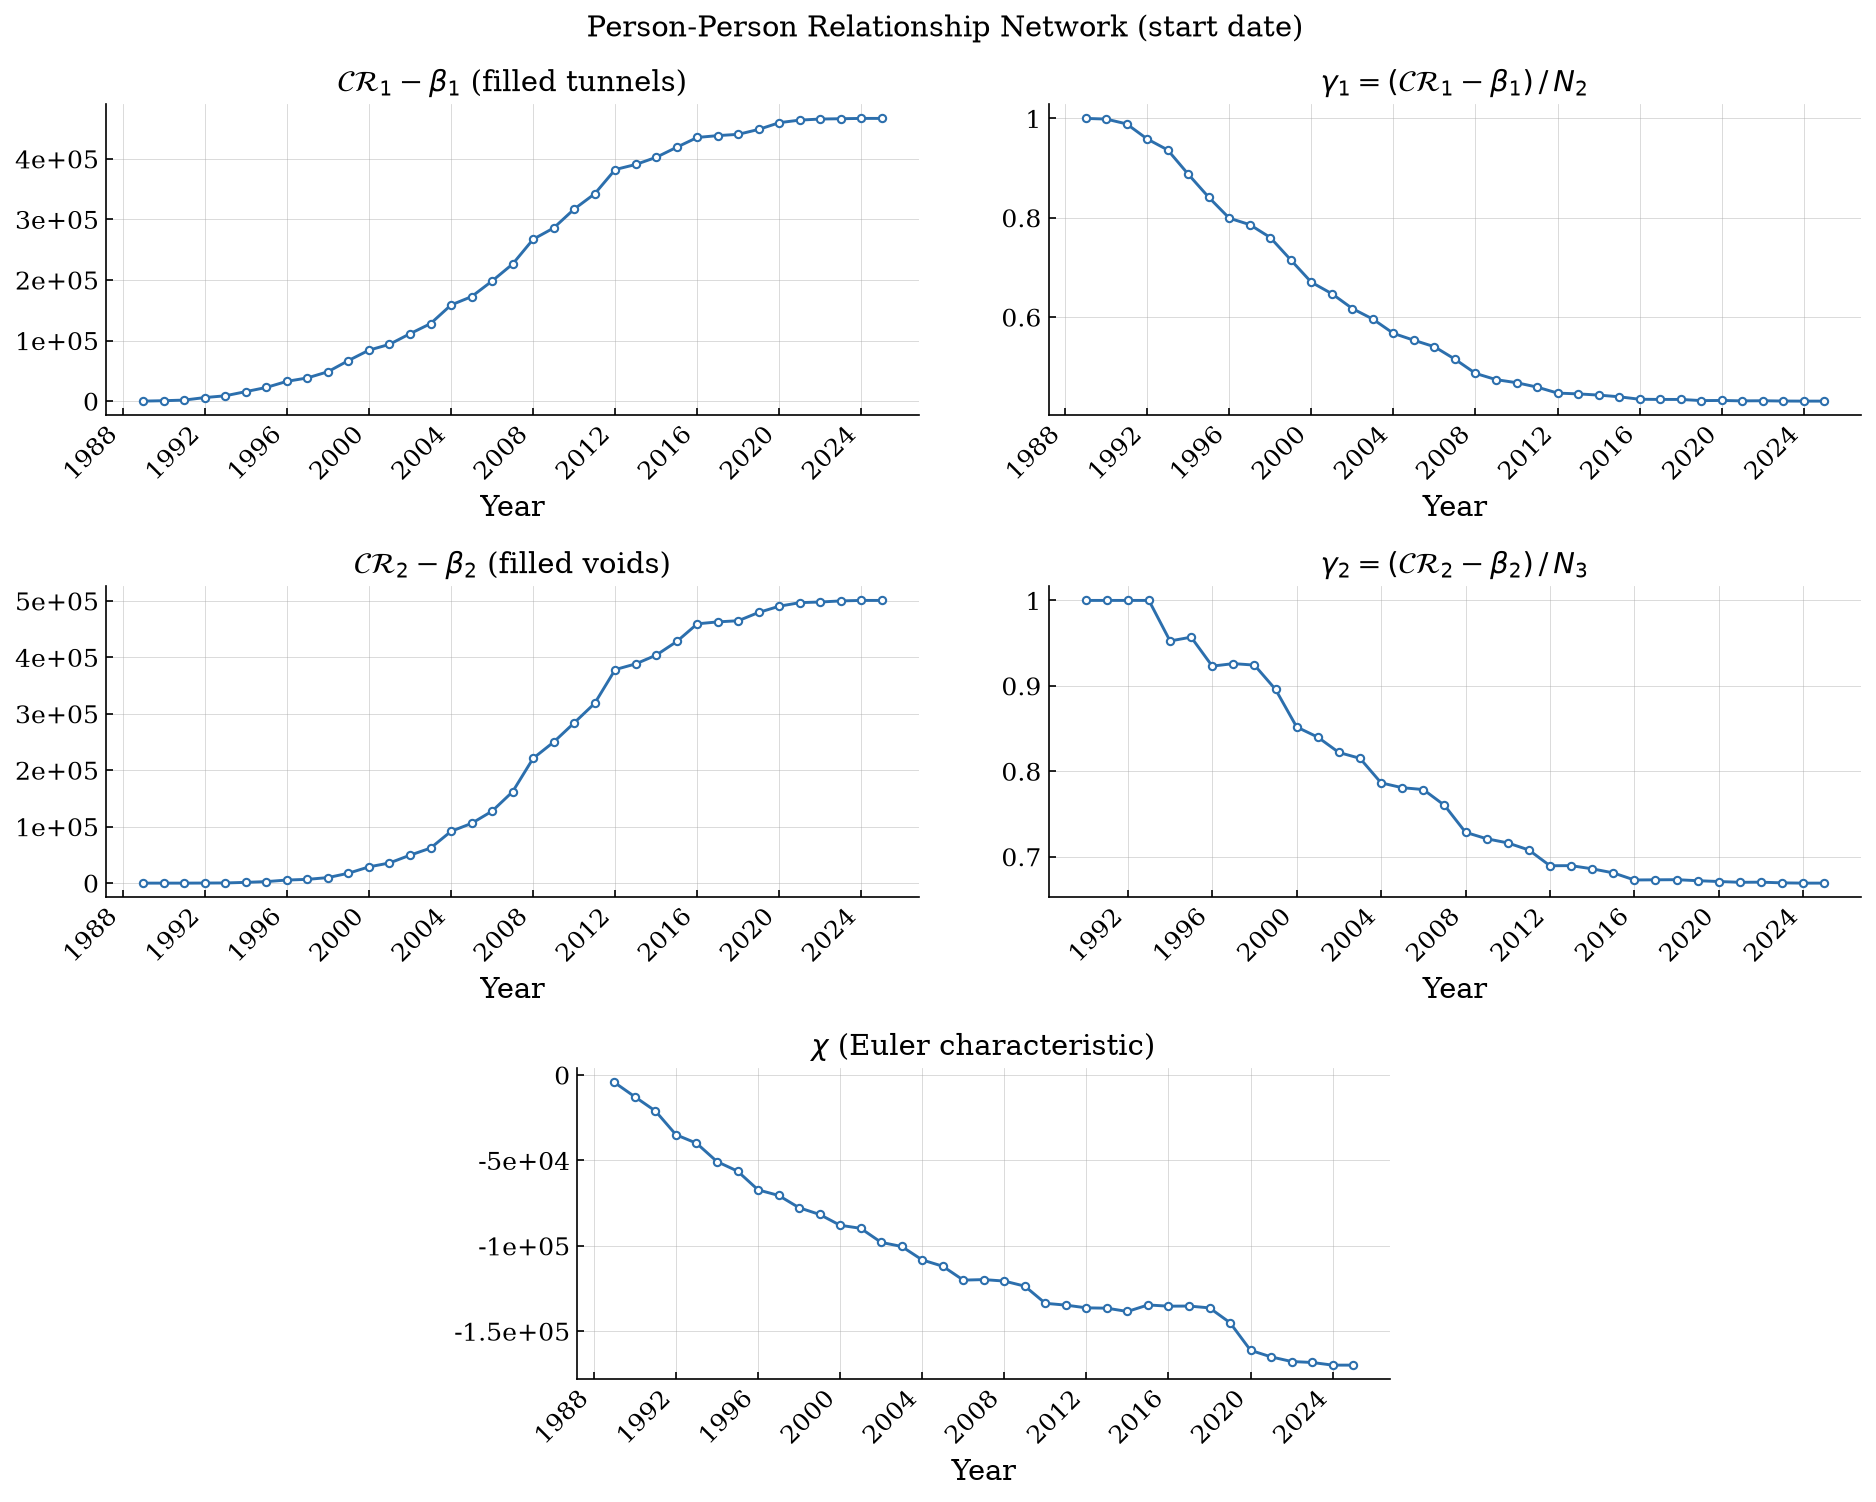

In [28]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/p2p_start_Betti'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        Betti_p2p_start, SimplexCounts_p2p_start, Euler_p2p_start, cycleR_p2p_start, dates_p2p_start = pickle.load(f)
else:
    rel_dicts = [has_start_p2p, has_start_end_p2p]
    Betti_p2p_start, SimplexCounts_p2p_start, Euler_p2p_start, cycleR_p2p_start, dates_p2p_start = PH_LittleSIS(rel_dicts, sort_by='start_date', timing=True,
                                                                    maxDim=np.inf, random_seed=42)
    data = [Betti_p2p_start, SimplexCounts_p2p_start, Euler_p2p_start, cycleR_p2p_start, dates_p2p_start]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_ph_yearly(Betti_p2p_start, SimplexCounts_p2p_start, Euler_p2p_start, cycleR_p2p_start, dates_p2p_start,
                   save_path='ph_yearly.pdf', title='Person-Person Relationship Network (start date)')

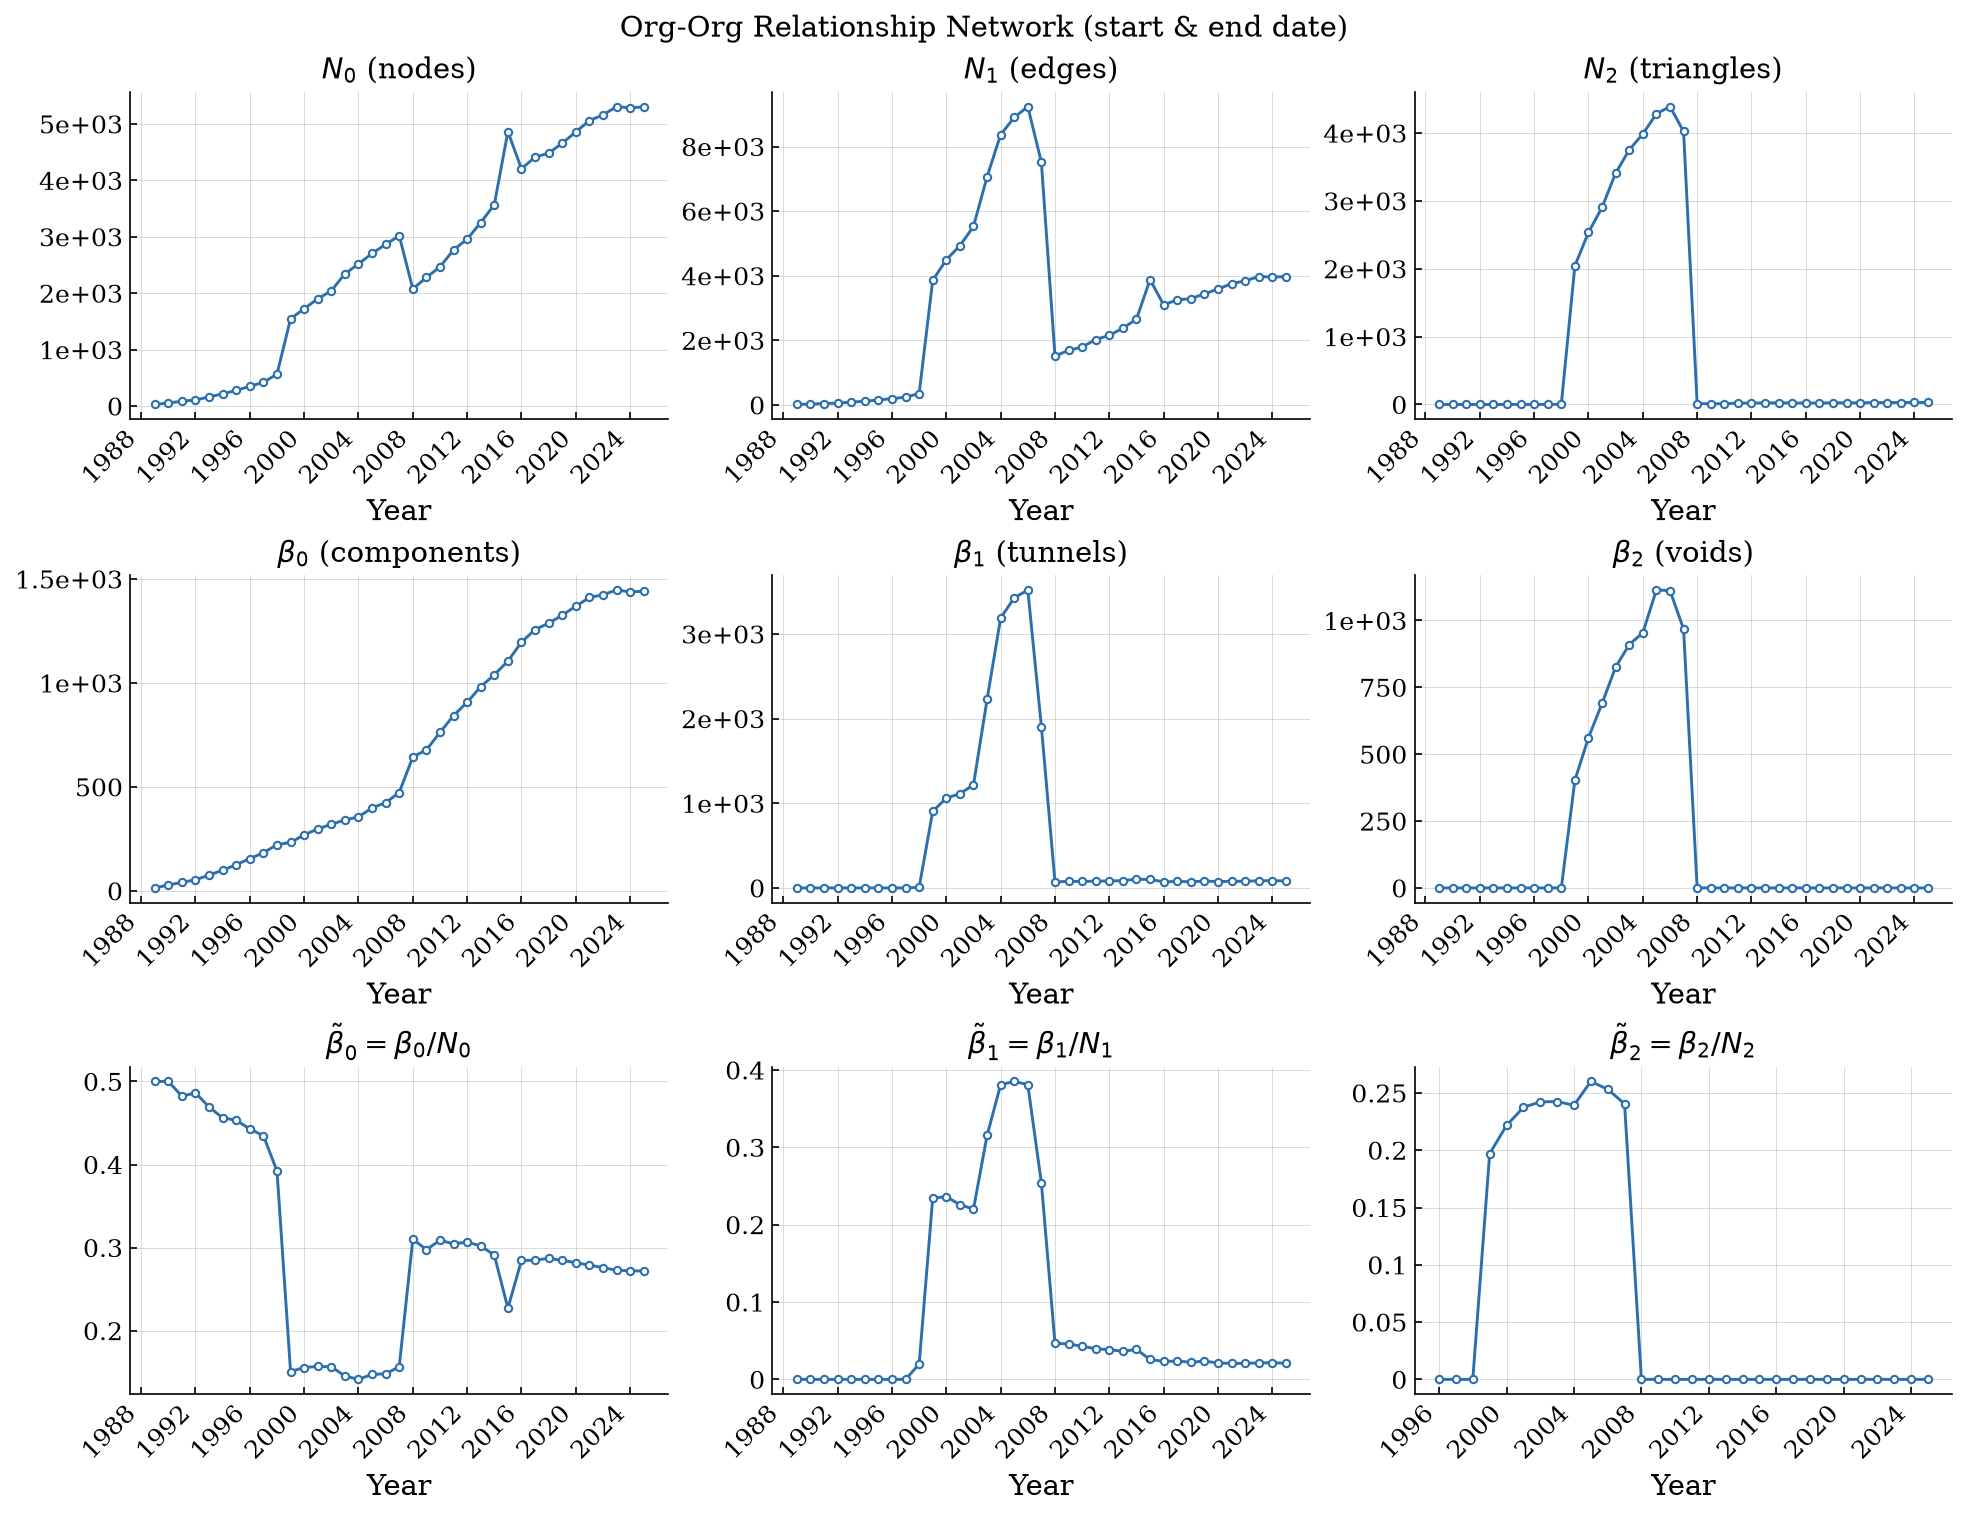

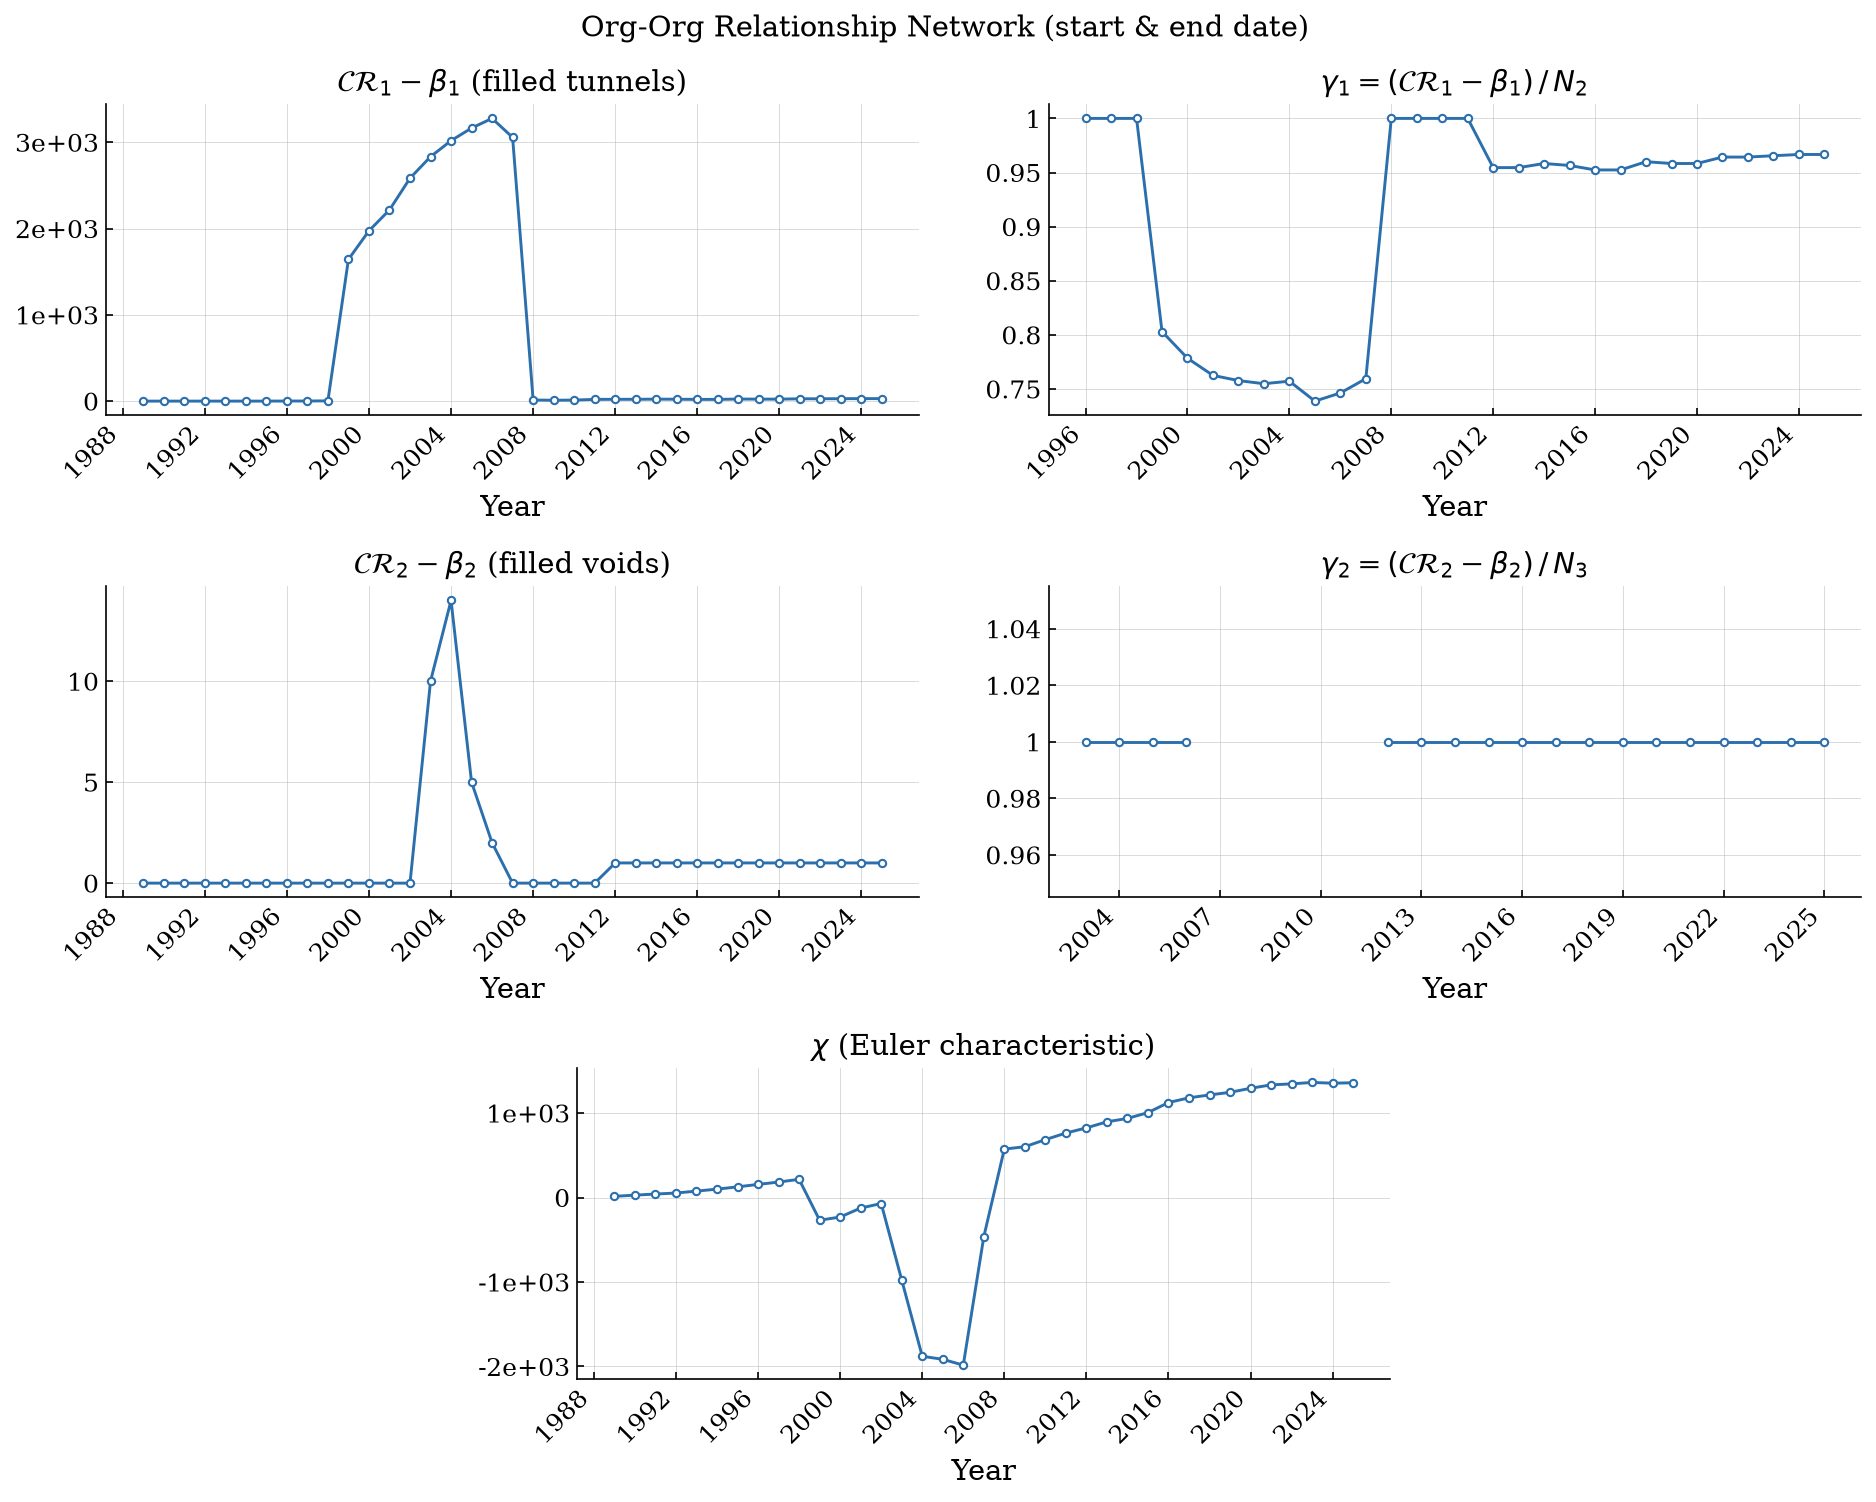

In [29]:
filename = '/content/drive/My Drive/Colab Notebooks/LittleSIS/o2o_start_end_Betti'
if os.path.exists(filename):
    with open(filename, 'rb') as f:
        Betti_o2o_start_end, SimplexCounts_o2o_start_end, Euler_o2o_start_end, cycleR_o2o_start_end, dates_o2o_start_end = pickle.load(f)
else:
    rel_dicts = [has_start_end_o2o]
    Betti_o2o_start_end, SimplexCounts_o2o_start_end, Euler_o2o_start_end, cycleR_o2o_start_end, dates_o2o_start_end = ZZ_LittleSIS(rel_dicts, timing=True, maxDim=np.inf, random_seed=42)
    data = [Betti_o2o_start_end, SimplexCounts_o2o_start_end, Euler_o2o_start_end, cycleR_o2o_start_end, dates_o2o_start_end]
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

plot_ph_yearly(Betti_o2o_start_end, SimplexCounts_o2o_start_end, Euler_o2o_start_end, cycleR_o2o_start_end, dates_o2o_start_end,
                   save_path='ph_yearly.pdf',title='Org-Org Relationship Network (start & end date)')

In [30]:
bulk_import_o2o = {
    r: has_start_end_o2o[r] for r in has_start_end_o2o
    if has_start_end_o2o[r]['updated_at'] is not None
    and int(has_start_end_o2o[r]['updated_at'][:4]) == 2008
    #and int(has_start_end_o2o[r]['start_date'][:4]) <= 2005
}

non_bulk_o2o = {
    r: has_start_end_o2o[r] for r in has_start_end_o2o
    if r not in bulk_import_o2o
}

print(f"has_start_end_o2o total:   {len(has_start_end_o2o)}")
print(f"Bulk import cohort:        {len(bulk_import_o2o)} "
      f"({100*len(bulk_import_o2o)/len(has_start_end_o2o):.1f}%)")
print(f"Non-bulk cohort:           {len(non_bulk_o2o)} "
      f"({100*len(non_bulk_o2o)/len(has_start_end_o2o):.1f}%)")

has_start_end_o2o total:   22488
Bulk import cohort:        11042 (49.1%)
Non-bulk cohort:           11446 (50.9%)


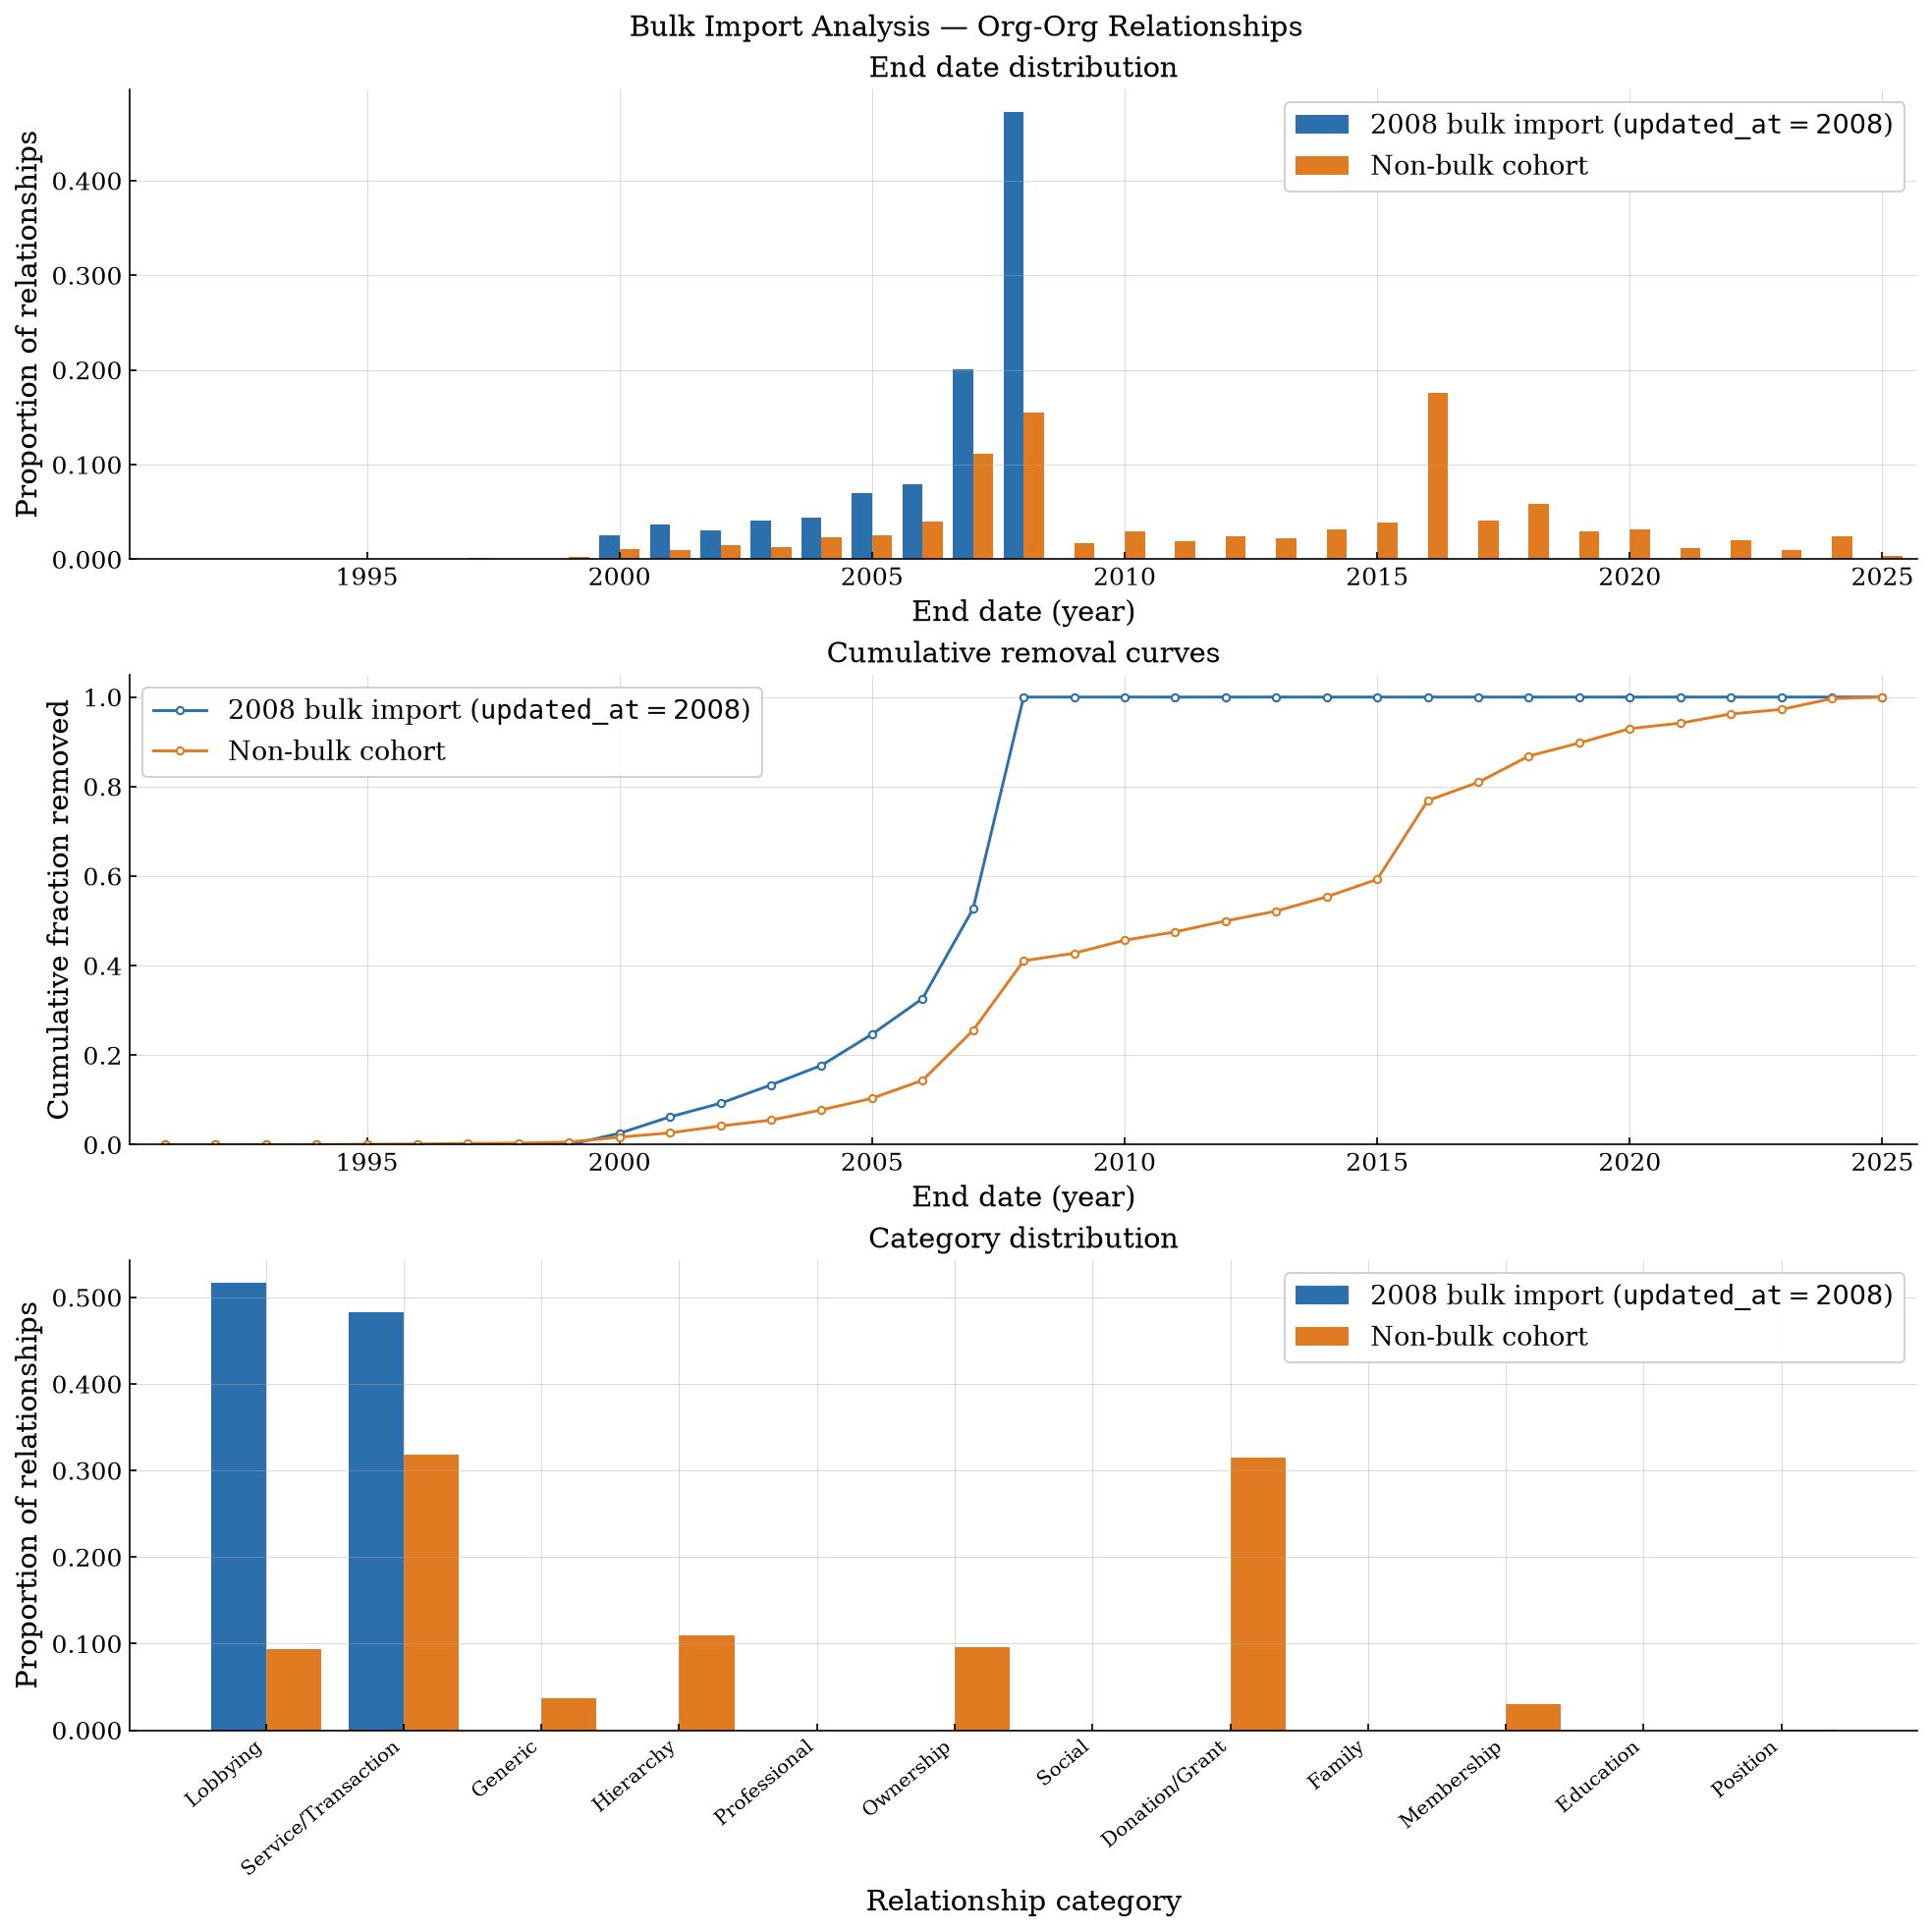

Saved: fig_bulk_import_analysis


In [31]:
BULK_COLOR    = '#2c6fad'
NONBULK_COLOR = '#e07b22'
BULK_LABEL    = '2008 bulk import ($\\mathtt{updated\\_at}=2008$)'
NONBULK_LABEL = 'Non-bulk cohort'

save_path = '/content/drive/My Drive/Colab Notebooks/LittleSIS/'

# ── data preparation ──────────────────────────────────────────────────────────

end_years_bulk     = [int(bulk_import_o2o[r]['end_date'][:4])
                      for r in bulk_import_o2o
                      if bulk_import_o2o[r]['end_date'] is not None]
end_years_non_bulk = [int(non_bulk_o2o[r]['end_date'][:4])
                      for r in non_bulk_o2o
                      if non_bulk_o2o[r]['end_date'] is not None]

yr_min   = min(end_years_bulk + end_years_non_bulk)
yr_max   = max(end_years_bulk + end_years_non_bulk)
bins_e   = range(yr_min, yr_max + 2)
bin_years = np.array(list(bins_e)[:-1])

counts_bulk     = year_counts(end_years_bulk,     bins_e)
counts_non_bulk = year_counts(end_years_non_bulk, bins_e)

prop_bulk     = counts_bulk     / counts_bulk.sum()
prop_non_bulk = counts_non_bulk / counts_non_bulk.sum()

cum_bulk     = np.cumsum(counts_bulk)     / len(end_years_bulk)
cum_non_bulk = np.cumsum(counts_non_bulk) / len(end_years_non_bulk)

# category counts
counts_cat_bulk     = np.zeros(12)
counts_cat_non_bulk = np.zeros(12)
for r in bulk_import_o2o:
    cid = bulk_import_o2o[r]['category_id']
    if 1 <= cid <= 12:
        counts_cat_bulk[cid - 1] += 1
for r in non_bulk_o2o:
    cid = non_bulk_o2o[r]['category_id']
    if 1 <= cid <= 12:
        counts_cat_non_bulk[cid - 1] += 1

prop_cat_bulk     = counts_cat_bulk     / counts_cat_bulk.sum()
prop_cat_non_bulk = counts_cat_non_bulk / counts_cat_non_bulk.sum()
sort_idx          = np.argsort(prop_cat_bulk)[::-1]

# ── figure ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(13, 13), constrained_layout=True)
fig.suptitle('Bulk Import Analysis — Org-Org Relationships', fontsize=14)

# ── row 1: end date distribution (bar) ───────────────────────────────────────

ax = axes[0]
w  = 0.4
ax.bar(bin_years - w/2, prop_bulk,     width=w, color=BULK_COLOR,
       edgecolor='none', label=BULK_LABEL)
ax.bar(bin_years + w/2, prop_non_bulk, width=w, color=NONBULK_COLOR,
       edgecolor='none', label=NONBULK_LABEL)
ax.set_xlabel('End date (year)')
ax.set_ylabel('Proportion of relationships')
ax.set_title('End date distribution', pad=6)
ax.set_xlim(yr_min - 0.7, yr_max + 0.7)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.3f}'))
ax.legend(loc='upper right', framealpha=0.9)

# ── row 2: cumulative removal curves ─────────────────────────────────────────

ax = axes[1]
ax.plot(bin_years, cum_bulk,     label=BULK_LABEL,    **line_kw(BULK_COLOR))
ax.plot(bin_years, cum_non_bulk, label=NONBULK_LABEL, **line_kw(NONBULK_COLOR))
ax.set_xlabel('End date (year)')
ax.set_ylabel('Cumulative fraction removed')
ax.set_title('Cumulative removal curves', pad=6)
ax.set_xlim(yr_min - 0.7, yr_max + 0.7)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', framealpha=0.9)

# ── row 3: category distribution (bar) ───────────────────────────────────────

ax  = axes[2]
x   = np.arange(12)
ax.bar(x - w/2, prop_cat_bulk[sort_idx],     width=w, color=BULK_COLOR,
       edgecolor='none', label=BULK_LABEL)
ax.bar(x + w/2, prop_cat_non_bulk[sort_idx], width=w, color=NONBULK_COLOR,
       edgecolor='none', label=NONBULK_LABEL)
ax.set_xticks(x)
ax.set_xticklabels([Rel_types_all[i] for i in sort_idx],
                   rotation=40, ha='right', fontsize=9.5)
ax.set_xlabel('Relationship category')
ax.set_ylabel('Proportion of relationships')
ax.set_title('Category distribution', pad=6)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.3f}'))
ax.legend(loc='upper right', framealpha=0.9)

fig.savefig(save_path + 'fig_bulk_import_analysis.pdf',
            dpi=300, bbox_inches='tight')
fig.savefig(save_path + 'fig_bulk_import_analysis.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_bulk_import_analysis')

In [32]:
# =============================================================================
# Run ZZ pipeline separately on bulk import and non-bulk cohorts
# =============================================================================
timing = True
if timing:
    print("Running ZZ pipeline on bulk import cohort...", flush=True)
Betti_bulk, SC_bulk, Euler_bulk, cycleR_bulk, dates_bulk = ZZ_LittleSIS(
    rel_dicts=[bulk_import_o2o],
    timing=True,
    maxDim=2,
    random_seed=42
)

if timing:
    print("Running ZZ pipeline on non-bulk cohort...", flush=True)
Betti_non, SC_non, Euler_non, cycleR_non, dates_non = ZZ_LittleSIS(
    rel_dicts=[non_bulk_o2o],
    timing=True,
    maxDim=2,
    random_seed=42
)

Running ZZ pipeline on bulk import cohort...
(1/5) Collecting and sorting events
  10918 additions, 10918 removals (21836 total). Time: 0.05s
(2/5) Initializing graph and data structures
  Done. Time: 0.00s
(3/5) Evolving graph


  0%|          | 0/21836 [00:00<?, ?it/s]

  Evolution complete. Time: 19.34s
(4/5) Computing Zigzag Persistent Homology
  ZZ PH complete. Time: 7.78s
(5/5) Extracting Betti numbers and Euler characteristic
  Done. Time: 0.07s
Running ZZ pipeline on non-bulk cohort...
(1/5) Collecting and sorting events
  10527 additions, 6554 removals (17081 total). Time: 0.06s
(2/5) Initializing graph and data structures
  Done. Time: 0.00s
(3/5) Evolving graph


  0%|          | 0/17081 [00:00<?, ?it/s]

  Evolution complete. Time: 31.72s
(4/5) Computing Zigzag Persistent Homology
  ZZ PH complete. Time: 7.33s
(5/5) Extracting Betti numbers and Euler characteristic
  Done. Time: 0.04s


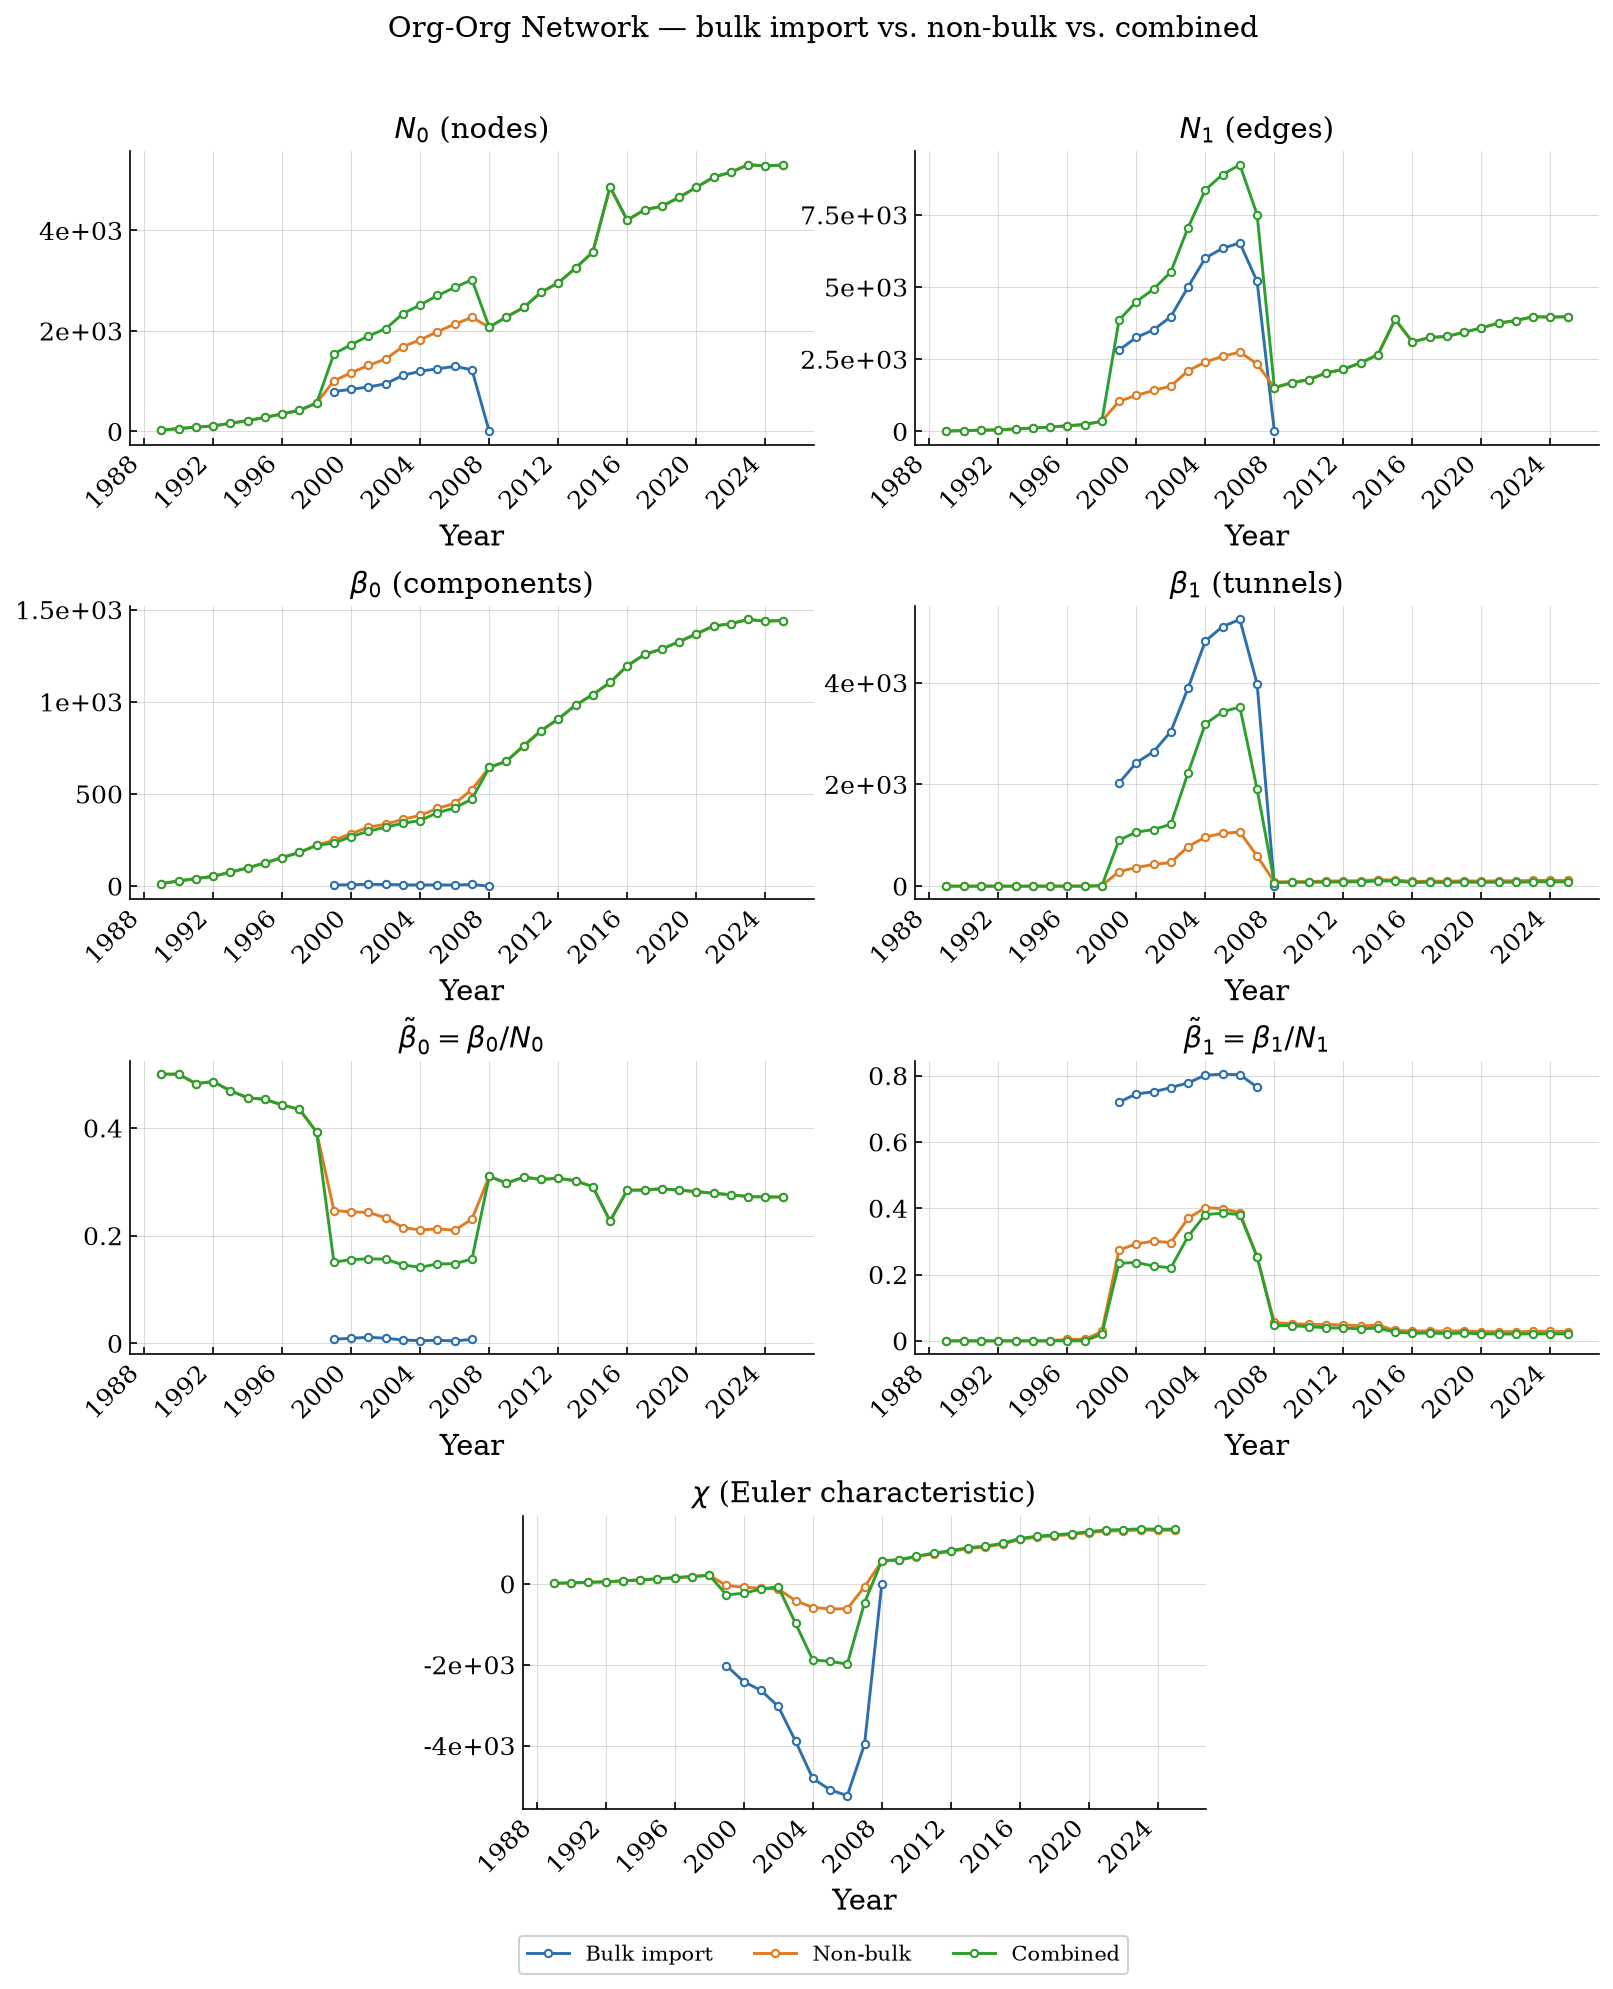

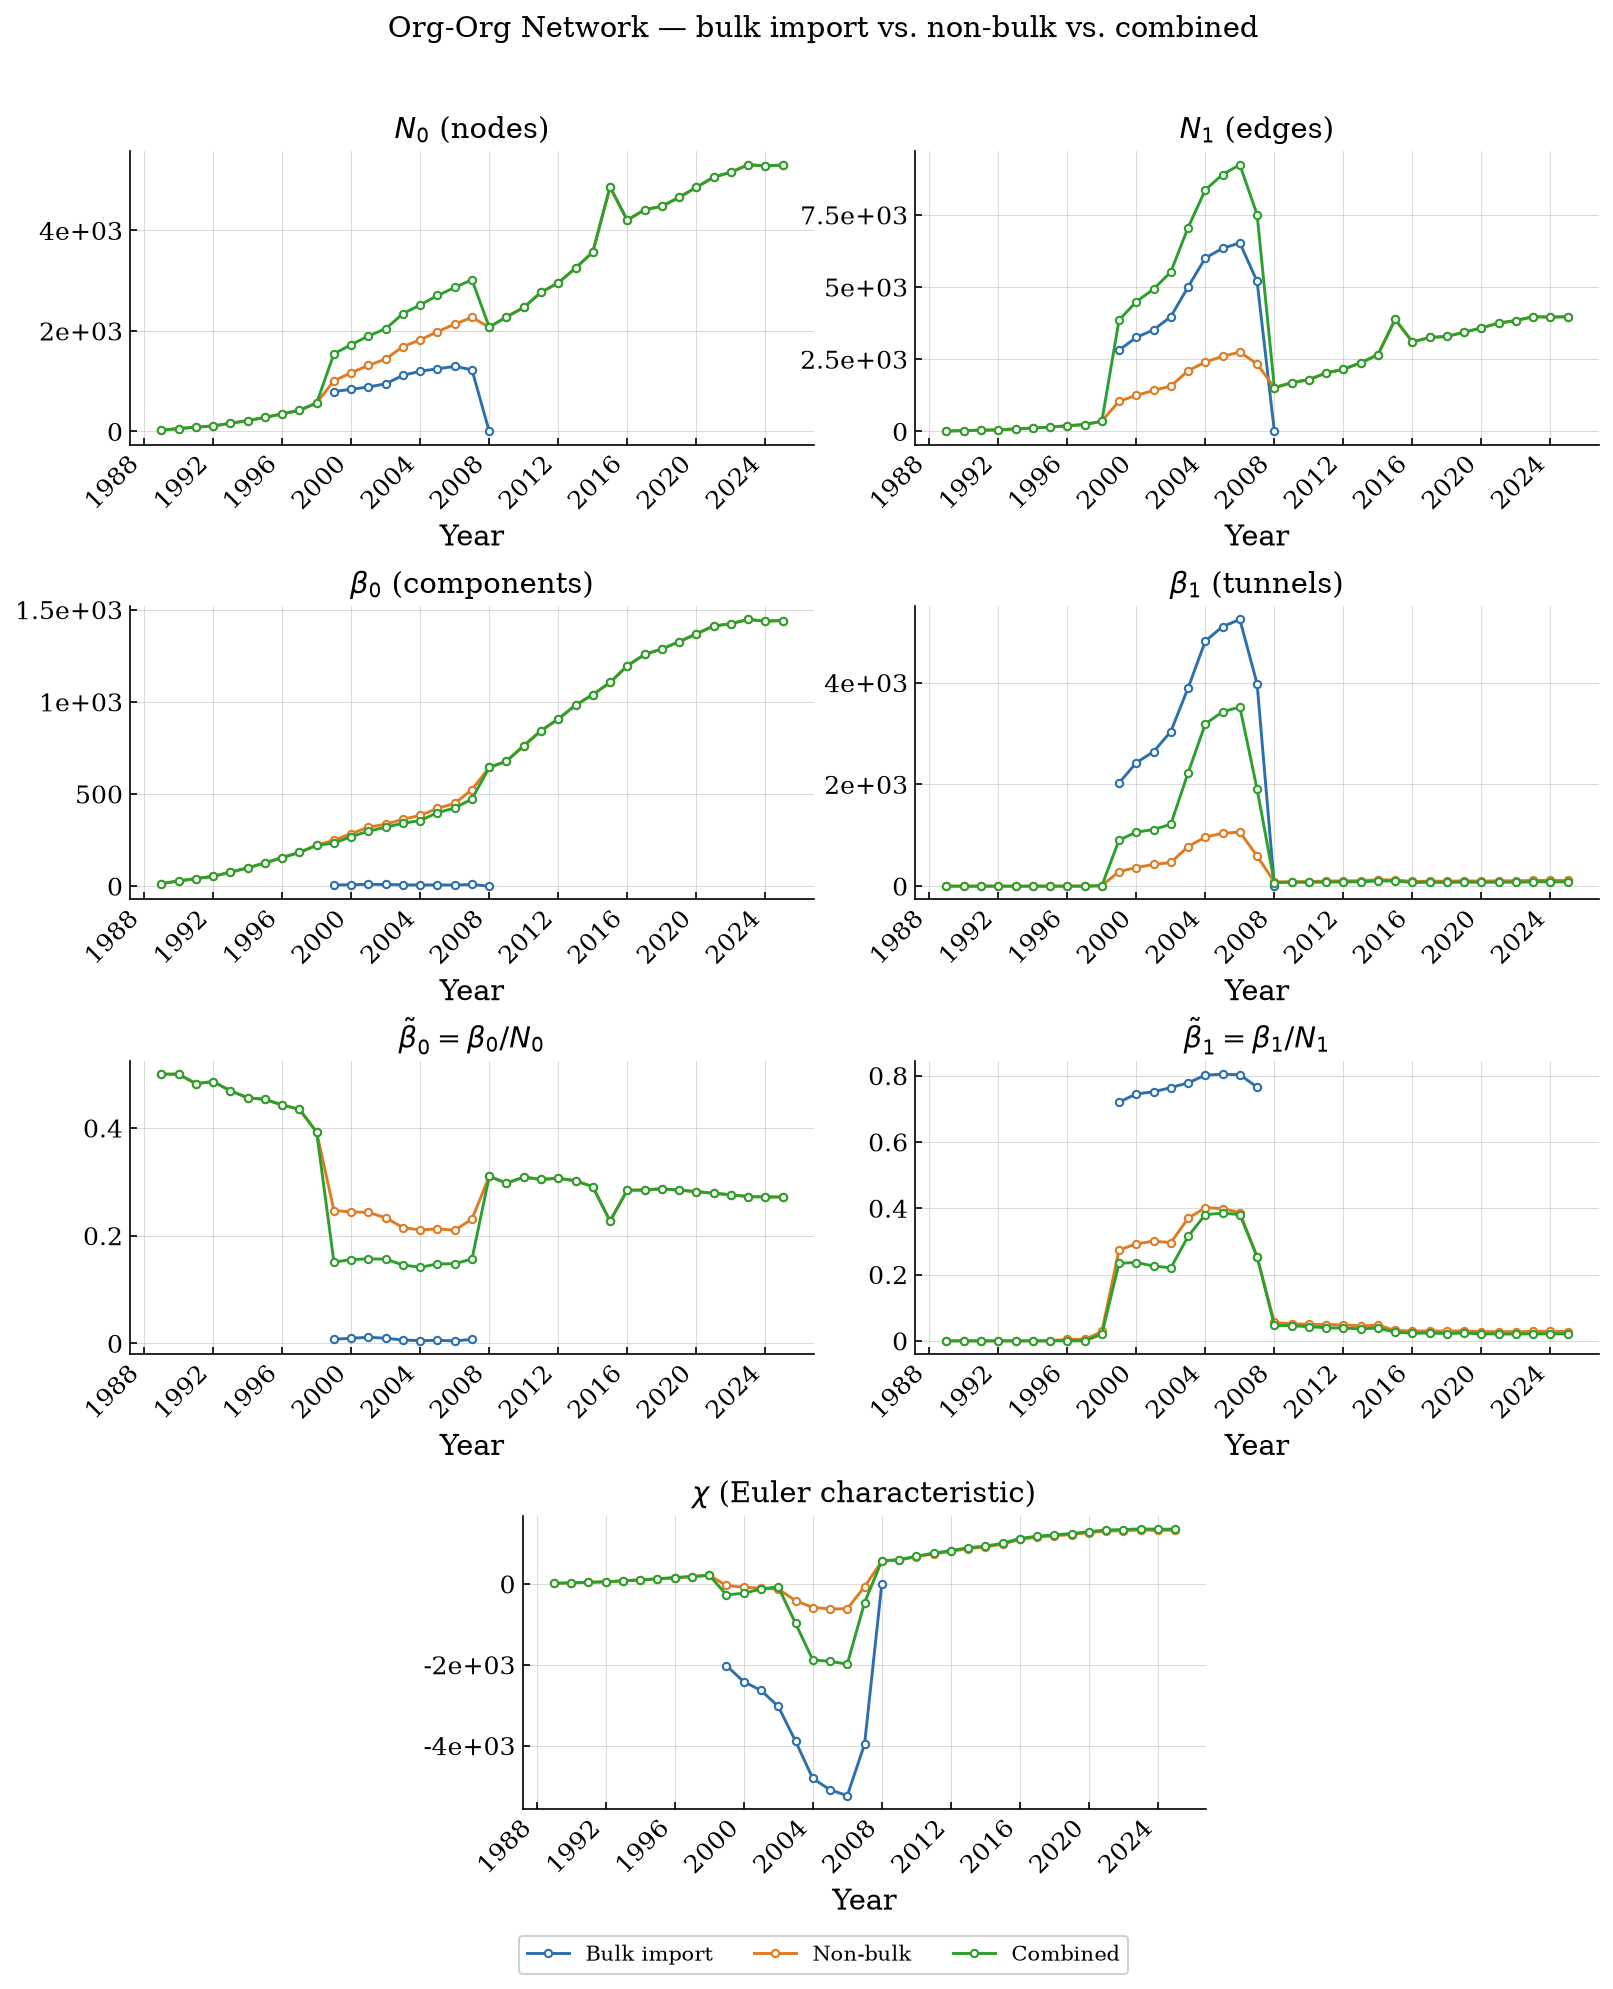

In [33]:
BULK_COLOR     = '#2c6fad'
NONBULK_COLOR  = '#e07b22'
COMBINED_COLOR = '#2ca02c'
BULK_LABEL     = 'Bulk import'
NONBULK_LABEL  = 'Non-bulk'
COMBINED_LABEL = 'Combined'

save_base = '/content/drive/My Drive/Colab Notebooks/LittleSIS/'

labels = [BULK_LABEL, NONBULK_LABEL, COMBINED_LABEL, BULK_COLOR, NONBULK_COLOR, COMBINED_COLOR]
plot_cohort_graph(labels,
    Betti_bulk, SC_bulk, Euler_bulk, cycleR_bulk, dates_bulk,
    Betti_non,  SC_non,  Euler_non,  cycleR_non,  dates_non,
    Betti_o2o_start_end, SimplexCounts_o2o_start_end,
    Euler_o2o_start_end, cycleR_o2o_start_end, dates_o2o_start_end,
    title     = 'Org-Org Network — bulk import vs. non-bulk vs. combined',
    save_path = save_base + 'fig_cohort_graph',
)